# `GEA` demo: masking the interactome

This notebook is a variant of the disease-graph demo. Instead of handing the GNN one induced subgraph per disease, the disease is a **mask over a single shared interactome**: the STRING protein-protein interaction network is the only graph there is, and a disease is a 0/1 vector over its proteins plus a confidence score.

-----

**Main objectives:**

- Fetch disease-associated gene sets from the [DISEASES](https://diseases.jensenlab.org/) database and the global protein-protein interaction network from [STRING](https://string-db.org/).
- Turn every disease into a mask $m^{(d)}$ and a confidence vector $c^{(d)}$ over STRING proteins, and cut the **context graph** the GNN actually reads: the disease genes plus the 1-hop neighbourhood around them, $V_d^+ = D_d \cup N_1(D_d)$.
- Give every node the feature $x_i^{(d)} = [e_i, m_i^{(d)}, c_i^{(d)}]$ — the whitened ESM-2 embedding as protein identity, the mask and the confidence as disease state.
- Train a GNN whose every layer is **FiLM-conditioned** on $(m_i^{(d)}, c_i^{(d)})$, against (1) held-out protein interactions and (2) a disease-context contrastive objective separating disease genes from their own local background.
- Building explainability using GEA at the node-, edge- and graph-level embeddings (i.e. training 3 Sparse Autoencoders (SAEs) and attributing features to a known ontology for the genes).

## Fetching data from databases

### Exploring the DISEASES database

#### Setup

In [1]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
DATA_DIR.mkdir(parents=True, exist_ok=True)

#### The DISEASES data

DISEASES publishes one flat file per evidence channel — no API key needed. We use `integrated`, which combines curated knowledge, GWAS and text mining and gives the best gene coverage per disease.

Each row is one (protein, disease) association with a confidence score from 0 (low) to 5 (high) stars.

In [2]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest


DISEASES_URL = "https://download.jensenlab.org/human_disease_integrated_full.tsv"
DISEASES_FILE = download_file(DISEASES_URL, DATA_DIR / "human_disease_integrated_full.tsv")

print(f"{DISEASES_FILE.name}: {DISEASES_FILE.stat().st_size / 1e6:.0f} MB")

human_disease_integrated_full.tsv: 645 MB


The `integrated` channel has five columns and no header row: a STRING protein id, the gene symbol, a Disease Ontology id (DOID), the disease name, and the confidence score.

The `doid` column also carries a few non-DOID entries (ICD10 chapter codes, one OMIM id) that the Disease Ontology can't place — we keep DOID-prefixed rows only.

In [3]:
COLUMNS = ["gene_id", "gene_symbol", "doid", "doid_name", "conf"]

diseases = pd.read_csv(DISEASES_FILE, sep="\t", header=None, names=COLUMNS)
diseases = diseases[diseases["doid"].str.startswith("DOID:")].reset_index(drop=True)
diseases.head()

,gene_id,gene_symbol,doid,doid_name,conf
0,18S_rRNA,18S_rRNA,DOID:9643,Babesiosis,3.631
1,18S_rRNA,18S_rRNA,DOID:1398,Parasitic infectious disease,3.524
2,18S_rRNA,18S_rRNA,DOID:2789,Parasitic protozoa infectious disease,3.518
3,18S_rRNA,18S_rRNA,DOID:4,Disease,3.396
4,18S_rRNA,18S_rRNA,DOID:0050117,Disease by infectious agent,3.316


We could also check the amount of entries and each type of variable inside the `diseases` dataframe.

In [4]:
print(f"{len(diseases):,} rows")
print(diseases.dtypes)

7,095,843 rows
gene_id         object
gene_symbol     object
doid            object
doid_name       object
conf           float64
dtype: object


### Filtering diseases

#### Confidence of genes being associated to a disease

The `conf` column is a 0–5 star scale: higher means more confident the gene is really associated with the disease.

count    7.095843e+06
mean     1.089939e+00
std      5.735548e-01
min      5.000000e-01
25%      6.860000e-01
50%      9.320000e-01
75%      1.325000e+00
max      5.000000e+00
Name: conf, dtype: float64


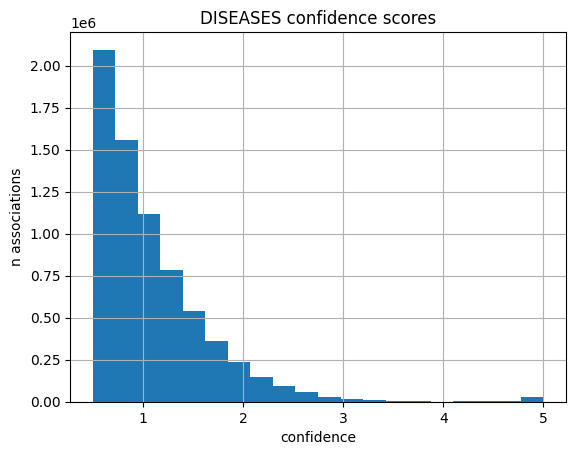

In [5]:
import matplotlib.pyplot as plt

print(diseases["conf"].describe())

diseases["conf"].hist(bins=20)
plt.xlabel("confidence"); plt.ylabel("n associations"); plt.title("DISEASES confidence scores")
plt.show()

Most of the mass sits below 2 stars (thin text-mining evidence). DISEASES' own documentation treats confidence ≥ 2 as the floor for a believable association, so we apply it before looking further.

In [6]:
MIN_CONF = 2.0

n_before = len(diseases)
diseases_conf = diseases[diseases["conf"] >= MIN_CONF].reset_index(drop=True)
print(f"{n_before:,} → {len(diseases_conf):,} rows with confidence >= {MIN_CONF}")

7,095,843 → 468,872 rows with confidence >= 2.0


We can now evaluate how many distinct diseases we have after the filtering of low confident genes and distinct genes associated to any disease.

In [7]:
print(f"{diseases_conf['doid'].nunique():,} distinct diseases")
print(f"{diseases_conf['gene_symbol'].nunique():,} distinct genes")

7,886 distinct diseases
14,540 distinct genes


#### Redundant diseases by gene size

Some entries are specific diseases with a handful of genes; others are broad umbrella terms from the Disease Ontology (e.g. "disease", "cancer") that list thousands. Worth seeing both ends.

In [8]:
genes_per_disease = (
    diseases_conf.groupby(["doid", "doid_name"])["gene_symbol"]
    .nunique()
    .sort_values(ascending=False)
)

genes_per_disease.describe()

count     7886.000000
mean        59.456252
std        312.122357
min          1.000000
25%          2.000000
50%          6.000000
75%         20.000000
max      10619.000000
Name: gene_symbol, dtype: float64

In [9]:
print("Largest gene sets:")
print(genes_per_disease.head(10))

print("\nSmallest gene sets:")
print(genes_per_disease.tail(10))

Largest gene sets:
doid          doid_name                        
DOID:4        Disease                              10619
DOID:7        Disease of anatomical entity          9033
DOID:630      Genetic disease                       5524
DOID:14566    Disease of cellular proliferation     5378
DOID:162      Cancer                                5263
DOID:863      Nervous system disease                5141
DOID:0050686  Organ system cancer                   4828
DOID:0050177  Monogenic disease                     4085
DOID:331      Central nervous system disease        3922
DOID:77       Gastrointestinal system disease       3816
Name: gene_symbol, dtype: int64

Smallest gene sets:
doid          doid_name                   
DOID:0050116  Tinea imbricata                 1
DOID:0050141  Intestinal botulism             1
DOID:0050490  Parenchymatous neurosyphilis    1
DOID:0050192  Nipah virus encephalitis        1
DOID:0050198  Chapare hemorrhagic fever       1
DOID:0050202  Lujo hemorrha

Diseases with very few genes carry too little signal, and diseases with thousands are Disease Ontology groupings (`Disease`, `Cancer`, `Genetic disease`, …) rather than specific diseases. We keep gene-set sizes in a reasonable range in between.

In [10]:
MIN_GENES_PER_DISEASE = 50
MAX_GENES_PER_DISEASE = 2000

too_small = genes_per_disease[genes_per_disease < MIN_GENES_PER_DISEASE]
too_large = genes_per_disease[genes_per_disease > MAX_GENES_PER_DISEASE]
keep_dois = genes_per_disease[
    (genes_per_disease >= MIN_GENES_PER_DISEASE) & (genes_per_disease <= MAX_GENES_PER_DISEASE)
].index.get_level_values("doid")

n_before = diseases_conf["doid"].nunique()
diseases_range = diseases_conf[diseases_conf["doid"].isin(keep_dois)].reset_index(drop=True)

print(f"dropped {len(too_small):,} diseases with < {MIN_GENES_PER_DISEASE} genes")
print(f"dropped {len(too_large):,} diseases with > {MAX_GENES_PER_DISEASE} genes, e.g. "
      + ", ".join(name for _, name in too_large.index[:5]))
print(f"\n{n_before:,} → {diseases_range['doid'].nunique():,} diseases kept")

dropped 6,904 diseases with < 50 genes
dropped 44 diseases with > 2000 genes, e.g. Disease, Disease of anatomical entity, Genetic disease, Disease of cellular proliferation, Cancer

7,886 → 938 diseases kept


#### Removing diseases with identical gene sets

Some DOIDs are near-synonyms that DISEASES' text mining cannot tell apart (e.g. "Leiomyosarcoma" and "Smooth muscle cancer") and end up with the exact same gene set under two different labels. We keep one representative per group of diseases sharing an identical gene set.

In [11]:
gene_sets = (
    diseases_range.groupby(["doid", "doid_name"])["gene_symbol"]
    .apply(frozenset)
    .reset_index()
)

dup_mask = gene_sets["gene_symbol"].duplicated(keep=False)
twin_groups = gene_sets[dup_mask].groupby("gene_symbol")["doid"].apply(list)

print(f"{dup_mask.sum():,} diseases in {len(twin_groups):,} groups share an identical gene set, e.g.:")
names_by_doid = gene_sets.set_index("doid")["doid_name"]
for dois in twin_groups.head(5):
    print("   " + " = ".join(names_by_doid.loc[dois]))

# one representative per group (the alphabetically first doid), the rest are dropped as duplicates
drop_dois = {doid for dois in twin_groups for doid in sorted(dois)[1:]}

n_before = diseases_range["doid"].nunique()
diseases_unique = diseases_range[~diseases_range["doid"].isin(drop_dois)].reset_index(drop=True)
print(f"\n{n_before:,} → {diseases_unique['doid'].nunique():,} diseases after dropping {len(drop_dois):,} twins")

36 diseases in 18 groups share an identical gene set, e.g.:
   Glycogen metabolism disorder = Glycogen storage disease
   Bile duct adenocarcinoma = Cholangiocarcinoma
   Insulinoma = Pancreatic cystadenoma
   Uveal cancer = Uveal melanoma
   Cystadenocarcinoma = Malignant cystadenoma

938 → 920 diseases after dropping 18 twins


We can also look into one specific disease. As an example, type 2 diabetes mellitus (`DOID:9352`) and its associated genes, ranked by confidence, are showcased.

In [12]:
doid = "DOID:9352"
example = diseases_unique[diseases_unique["doid"] == doid].sort_values("conf", ascending=False)

print(f"{example['doid_name'].iloc[0]}: {len(example)} associations, "
      f"{example['gene_symbol'].nunique()} distinct genes")
example.head(15)

Type 2 diabetes mellitus: 1117 associations, 1117 distinct genes


,gene_id,gene_symbol,doid,doid_name,conf
23783,ENSP00000240652,IAPP,DOID:9352,Type 2 diabetes mellitus,4.708
29359,ENSP00000252486,APOE,DOID:9352,Type 2 diabetes mellitus,4.670
158136,ENSP00000363827,HSPG2,DOID:9352,Type 2 diabetes mellitus,4.344
32777,ENSP00000255040,APCS,DOID:9352,Type 2 diabetes mellitus,4.337
185853,ENSP00000380432,INS,DOID:9352,Type 2 diabetes mellitus,4.000
196197,ENSP00000389814,ADIPOQ,DOID:9352,Type 2 diabetes mellitus,4.000
93795,ENSP00000312652,LEP,DOID:9352,Type 2 diabetes mellitus,4.000
195064,ENSP00000387662,GCG,DOID:9352,Type 2 diabetes mellitus,4.000
154168,ENSP00000362353,GLP1R,DOID:9352,Type 2 diabetes mellitus,4.000
84332,ENSP00000303830,INSR,DOID:9352,Type 2 diabetes mellitus,3.986


Let's save the filtered dataset with all disease-associated gene sets into our data folder.

In [13]:
diseases_unique.to_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t", index=False)

### Fetching protein-protein interaction networks from STRING

#### Setup

In [14]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
STRING_DIR = DATA_DIR / "string"
STRING_DIR.mkdir(parents=True, exist_ok=True)

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
print(f"{len(diseases):,} associations | {diseases['doid'].nunique():,} diseases | "
      f"{diseases['gene_id'].nunique():,} proteins")

260,212 associations | 920 diseases | 9,852 proteins


#### The STRING data

[STRING](https://string-db.org/) publishes one flat file of all pairwise interaction scores per species, so no API key needed either for this case. Each row is one (protein, protein) pair with a combined confidence score from 0 to 1000, aggregating evidence from experiments, curated databases, co-expression, text mining and more.

In [15]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest

STRING_URL = "https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz"
STRING_FILE = download_file(STRING_URL, STRING_DIR / "9606.protein.links.v12.0.txt.gz")

print(f"{STRING_FILE.name}: {STRING_FILE.stat().st_size / 1e6:.0f} MB")

9606.protein.links.v12.0.txt.gz: 83 MB


The dataframe has one row per interacting protein pair. STRING ids carry a species prefix (`9606.` for human), which we drop so they match the protein ids already in our disease table.

In [16]:
string_links = pd.read_csv(STRING_FILE, sep=" ", compression="gzip")
string_links["protein1"] = string_links["protein1"].str.removeprefix("9606.")
string_links["protein2"] = string_links["protein2"].str.removeprefix("9606.")
string_links.head()

,protein1,protein2,combined_score
0,ENSP00000000233,ENSP00000356607,173
1,ENSP00000000233,ENSP00000427567,154
2,ENSP00000000233,ENSP00000253413,151
3,ENSP00000000233,ENSP00000493357,471
4,ENSP00000000233,ENSP00000324127,201


As the DISEASES dataframe, we can also look into the amount of rows (protein interactions) and the columns type the dataframe has.

In [17]:
print(f"{len(string_links):,} rows")
print(string_links.dtypes)

13,715,404 rows
protein1          object
protein2          object
combined_score     int64
dtype: object


### Filtering interactions based on confidence score

#### High confidence interaction filter

The overall confidence score that is made aggregating every evidence channel of a protein-protein interaction in STRING is given by `combined_score` (its range is 0–1000). STRING's own "high confidence" cutoff is 700.

count    1.371540e+07
mean     2.686240e+02
std      1.569828e+02
min      1.500000e+02
25%      1.710000e+02
50%      2.090000e+02
75%      2.980000e+02
max      9.990000e+02
Name: combined_score, dtype: float64


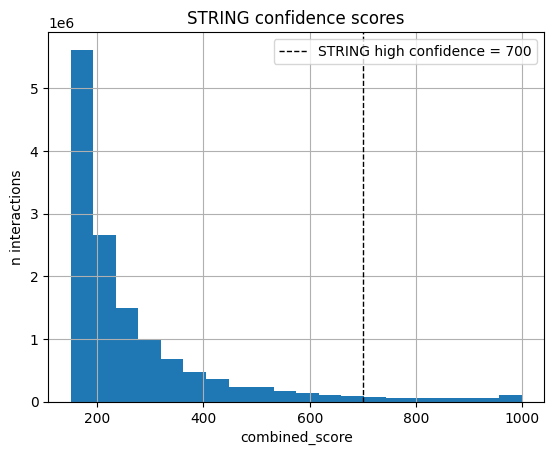

In [18]:
from matplotlib import pyplot as plt

print(string_links["combined_score"].describe())

string_links["combined_score"].hist(bins=20)
plt.axvline(700, color="k", ls="--", lw=1, label="STRING high confidence = 700")
plt.xlabel("combined_score"); plt.ylabel("n interactions"); plt.title("STRING confidence scores")
plt.legend(); plt.show()

We keep only high-confidence interactions (`combined_score >= 700`, STRING's own "high confidence" band). Medium confidence (`>= 400`) would keep far more edges, but pulls in a lot of weaker, text-mining-only evidence — and we're already leaning on DISEASES' text-mined associations for the disease genes, so keeping the network side clean avoids compounding two noisy sources.

In [19]:
STRING_MIN_SCORE = 700

n_before = len(string_links)
string_links = string_links[string_links["combined_score"] >= STRING_MIN_SCORE].reset_index(drop=True)
print(f"{n_before:,} → {len(string_links):,} interactions with combined_score >= {STRING_MIN_SCORE}")

13,715,404 → 473,860 interactions with combined_score >= 700


We can evaluate how many unique proteins and interactions we end up on the final set.

In [20]:
n_proteins = pd.concat([string_links["protein1"], string_links["protein2"]]).nunique()
print(f"{n_proteins:,} distinct proteins")
print(f"{len(string_links):,} interactions")

16,201 distinct proteins
473,860 interactions


#### Interactions per protein

Like the disease gene sets, this is heavy-tailed: most proteins have a handful of high-confidence partners, while a few hub proteins have thousands.

In [21]:
interactions_per_protein = (
    pd.concat([string_links["protein1"], string_links["protein2"]])
    .value_counts()
)

print(interactions_per_protein.describe())
print("\nMost connected proteins:")
print(interactions_per_protein.head(10))

count    16201.000000
mean        58.497624
std         91.458814
min          2.000000
25%          8.000000
50%         26.000000
75%         70.000000
max       1532.000000
Name: count, dtype: float64

Most connected proteins:
ENSP00000269305    1532
ENSP00000272317    1178
ENSP00000388107    1042
ENSP00000275493    1012
ENSP00000495360     930
ENSP00000244537     904
ENSP00000333277     904
ENSP00000494750     876
ENSP00000451828     870
ENSP00000431822     846
Name: count, dtype: int64


As an example, `INS` (insulin, `ENSP00000380432`) — one of the type 2 diabetes genes from before — and its highest-confidence interaction partners.

In [22]:
protein = "ENSP00000380432"
example = string_links[(string_links["protein1"] == protein) | (string_links["protein2"] == protein)]
example = example.sort_values("combined_score", ascending=False)

print(f"{protein}: {len(example)} interactions")
example.head(15)

ENSP00000380432: 612 interactions


,protein1,protein2,combined_score
340952,ENSP00000380432,ENSP00000265986,999
464646,ENSP00000497069,ENSP00000380432,999
340994,ENSP00000380432,ENSP00000304895,999
340899,ENSP00000380432,ENSP00000376637,999
146811,ENSP00000303830,ENSP00000380432,999
340900,ENSP00000380432,ENSP00000497069,999
341026,ENSP00000380432,ENSP00000303830,999
91784,ENSP00000265986,ENSP00000380432,999
327055,ENSP00000376637,ENSP00000380432,999
341059,ENSP00000380432,ENSP00000295897,999


We can save these protein-protein interactions on our data folder.

In [23]:
string_links.to_csv(DATA_DIR / "string_filtered.tsv", sep="\t", index=False)

## Masking the interactome

### Building the disease context graphs

#### Setup

In [24]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/diseases")             # shared with the disease-graph demo: downloads + filtered tables
STRING_DIR = DATA_DIR / "string"
OUT_DIR = Path("data/mask-the-interactome")  # everything this notebook produces
OUT_DIR.mkdir(parents=True, exist_ok=True)

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")

print(f"{diseases['doid'].nunique():,} diseases | {diseases['gene_id'].nunique():,} disease genes")
print(f"{len(string_links):,} interactions | "
      f"{pd.concat([string_links['protein1'], string_links['protein2']]).nunique():,} proteins")

920 diseases | 9,852 disease genes
473,860 interactions | 16,201 proteins


#### The disease as a mask, not as a graph

There is one graph, $G = (V, E)$: the high-confidence STRING interactome. A disease $d$ is not a graph of its own — it is a pair of vectors over that graph's proteins:

- a **mask** $m^{(d)} \in \{0, 1\}^{|V|}$, 1 for the proteins DISEASES associates with $d$,
- a **confidence** $c^{(d)}$, the DISEASES star score (2-5) for those proteins and 0 everywhere else.

Passing the whole interactome through the GNN once per disease would be wasteful — most of it is nowhere near the mask — so what the model actually reads is the **context graph**: the subgraph induced on $V_d^+ = D_d \cup N_1(D_d)$, the disease genes together with the STRING partners immediately around them. That neighbourhood is what makes the rest of the notebook possible: it gives every disease a *local background* of proteins sitting in the same region of the interactome that were never associated with the disease.

$N_1(D_d)$ taken in full is too big to be useful — the 1-hop neighbourhood of a median disease already covers 3,400 of the 16,201 STRING proteins and a large one over 11,000, so every "context" would be most of the interactome. We keep each disease gene's `K_NEIGHBOURS` highest-confidence partners instead. At K = 2 the background comes out roughly the same size as the disease gene set itself — a balanced, genuinely local contrast — and the partners kept are the *hardest* available negatives: proteins bound tightly to a disease gene that the disease was nonetheless never annotated with. Some of them are presumably disease-relevant and simply unstudied; that is a feature of the setup rather than a flaw in it, and it is exactly what the model is later asked to score.

In [25]:
import networkx as nx

G_string = nx.from_pandas_edgelist(string_links, "protein1", "protein2", edge_attr="combined_score")
print(f"STRING interactome: {G_string.number_of_nodes():,} proteins | {G_string.number_of_edges():,} interactions")

K_NEIGHBOURS = 2  # highest-confidence STRING partners kept per disease gene

# top-K partners of every protein, ranked by combined_score — computed once over the whole interactome
top_partners = {
    protein: [p for p, _ in sorted(G_string[protein].items(),
                                   key=lambda kv: -kv[1]["combined_score"])[:K_NEIGHBOURS]]
    for protein in G_string.nodes
}

gene_sets = diseases.groupby(["doid", "doid_name"])["gene_id"].apply(set)
conf_by_disease = {
    doid: dict(zip(group["gene_id"], group["conf"]))
    for doid, group in diseases.drop_duplicates(["doid", "gene_id"]).groupby("doid")
}

context_graphs, rows = {}, []
for (doid, doid_name), genes in gene_sets.items():
    seeds = genes & G_string.nodes                                      # D_d, restricted to STRING
    if not seeds:
        continue
    background = set().union(*(top_partners[p] for p in seeds)) - seeds  # N_1(D_d) \ D_d
    G = G_string.subgraph(seeds | background).copy()                     # V_d^+

    conf = conf_by_disease[doid]
    nx.set_node_attributes(G, {p: float(p in seeds) for p in G.nodes}, "m")
    nx.set_node_attributes(G, {p: float(conf.get(p, 0.0)) for p in G.nodes}, "c")

    context_graphs[doid] = G
    rows.append({"doid": doid, "doid_name": doid_name,
                 "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges(),
                 "n_seed": len(seeds), "n_background": G.number_of_nodes() - len(seeds)})

graph_sizes = pd.DataFrame(rows).sort_values("n_nodes", ascending=False)
print(f"\n{len(context_graphs):,} disease context graphs built")

STRING interactome: 16,201 proteins | 236,930 interactions

920 disease context graphs built


#### Context graph sizes

Unlike an induced disease subgraph, a context graph has no isolated nodes by construction: every background protein is in it because it partners a disease gene, and every disease gene that STRING knows at all keeps its own partners. The sizes below are split into the masked part (`n_seed`) and the local background (`n_background`).

In [26]:
print(graph_sizes[["n_nodes", "n_edges", "n_seed", "n_background"]].describe())

ratio = graph_sizes["n_background"] / graph_sizes["n_seed"]
print(f"\nbackground / disease-gene ratio: median {ratio.median():.2f}")

print("\nLargest context graphs:")
print(graph_sizes.head(10).to_string(index=False))

print("\nSmallest context graphs:")
print(graph_sizes.tail(10).to_string(index=False))

           n_nodes       n_edges       n_seed  n_background
count   920.000000    920.000000   920.000000    920.000000
mean    504.004348   6554.976087   269.680435    234.323913
std     560.797004   9626.091770   340.604238    223.240370
min      87.000000    195.000000    46.000000     28.000000
25%     155.000000    936.250000    70.750000     86.000000
50%     266.000000   2097.500000   126.000000    140.500000
75%     574.000000   7147.750000   285.250000    285.250000
max    3065.000000  48283.000000  1880.000000   1289.000000

background / disease-gene ratio: median 1.09

Largest context graphs:
        doid                        doid_name  n_nodes  n_edges  n_seed  n_background
DOID:0050155           Sensory system disease     3065    42684    1776          1289
   DOID:4194       Glucose metabolism disease     2903    46463    1866          1037
     DOID:18           Urinary system disease     2846    46623    1800          1046
    DOID:612 Primary immunodeficiency disease

Back to type 2 diabetes mellitus (`DOID:9352`) we have been using as an example, its context graph is showcased — masked disease genes and the local background that came in with them.

In [27]:
doid = "DOID:9352"
G = context_graphs[doid]
n_seed = int(sum(m for _, m in G.nodes(data="m")))

print(f"Type 2 diabetes mellitus: {n_seed} masked disease genes + "
      f"{G.number_of_nodes() - n_seed} local-background proteins")
print(f"  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges in the context graph")

Type 2 diabetes mellitus: 1072 masked disease genes + 801 local-background proteins
  1873 nodes, 28013 edges in the context graph


### ESM-2 embeddings as a node flag

There is a huge problem on network analysis, and if the plan is to use graph to train graph neural networks then the model has no way to know the node identity. Therefore, we can flag each protein by concatenating a representative vector to its feature. In this case, we opt to use ESM-2 embeddings as a way to flag every protein. Here that matters twice over: the background proteins need an identity of exactly the same kind as the disease genes, or the mask would be readable straight off the node features and nothing below would mean anything.

#### Writing the protein list

The protein universe is wider than the disease genes alone — every background protein in a context graph needs an embedding too. `get_esm_protein_embeddings.py` looks sequences up by protein id directly, so there is still no gene mapping to do and no isoforms to aggregate. The disease-graph demo already embedded most of the disease genes, so we only ask for the proteins its file does not already cover.

In [28]:
import torch

universe = sorted({p for G in context_graphs.values() for p in G.nodes})
PROTEIN_LIST_FILE = OUT_DIR / "context_protein_ids.txt"
PROTEIN_LIST_FILE.write_text("\n".join(universe))

BASE_ESM_FILE = DATA_DIR / "esm_protein_embeddings.pt"
already = set(torch.load(BASE_ESM_FILE, weights_only=False)) if BASE_ESM_FILE.exists() else set()
missing = [p for p in universe if p not in already]

MISSING_LIST_FILE = OUT_DIR / "context_protein_ids_missing.txt"
MISSING_LIST_FILE.write_text("\n".join(missing))

print(f"{len(universe):,} proteins in the context-graph universe → {PROTEIN_LIST_FILE}")
print(f"{len(universe) - len(missing):,} already embedded in {BASE_ESM_FILE.name}")
print(f"{len(missing):,} still to embed → {MISSING_LIST_FILE}")

10,664 proteins in the context-graph universe → data/mask-the-interactome/context_protein_ids.txt
8,893 already embedded in esm_protein_embeddings.pt
1,771 still to embed → data/mask-the-interactome/context_protein_ids_missing.txt


#### Computing the embeddings

Run this from the repo root, in the `gea` conda environment. It only covers the proteins the
disease-graph demo has not already embedded, so this is a short run rather than a full pass over the
proteome:

```bash
python3 docs/scripts/get_esm_protein_embeddings.py \
    --protein-list docs/tutorial/data/mask-the-interactome/context_protein_ids_missing.txt \
    --out          docs/tutorial/data/mask-the-interactome/esm_protein_embeddings_context.pt \
    --species      human \
    --model        facebook/esm2_t33_650M_UR50D \
    --batch-size 8
```

The FASTA is already cached at `docs/tutorial/data/diseases/ensembl_pep.fa.gz`; pass it with `--fasta`
to skip the download entirely. This writes `{protein_id: tensor([1280])}` to
`esm_protein_embeddings_context.pt`, which the next cell merges with the disease-graph demo's file.
Come back here once it's finished.

#### Loading the embeddings

The two files are merged into one table — the disease-graph demo's, plus the top-up just computed — and written back out as a single file so `load_esm_protein_embeddings` has one place to read from.

Its random-Gaussian fallback for proteins missing from the file is a real hazard in this notebook. A protein carrying a random identity vector is trivially separable from one carrying a real ESM-2 embedding, and telling masked from unmasked proteins apart is precisely the model's job — a handful of random vectors would hand it a shortcut. So rather than let the fallback fire, we **drop** proteins with no embedding from the context graphs (retired ENSP ids that Ensembl's current proteome no longer carries) and only ever look up proteins the merged table actually has.

In [29]:
from gea.utils import load_esm_protein_embeddings

ESM_SOURCES = [BASE_ESM_FILE, OUT_DIR / "esm_protein_embeddings_context.pt"]

esm_table = {}
for source in ESM_SOURCES:
    if not source.exists():
        print(f"not found, run the command above first: {source}")
        continue
    part = torch.load(source, weights_only=False)
    new = {p: v for p, v in part.items() if p not in esm_table}
    esm_table.update(new)
    print(f"{source.name}: {len(part):,} proteins ({len(new):,} new)")

MERGED_ESM_FILE = OUT_DIR / "esm_protein_embeddings_merged.pt"
torch.save(esm_table, MERGED_ESM_FILE)

# drop proteins with no embedding instead of letting the loader invent one for them
unembedded = [p for p in universe if p not in esm_table]
for G in context_graphs.values():
    G.remove_nodes_from(unembedded)
    G.remove_nodes_from(list(nx.isolates(G)))
context_graphs = {doid: G for doid, G in context_graphs.items() if G.number_of_nodes() > 0}

all_proteins = sorted({p for G in context_graphs.values() for p in G.nodes})
esm_embeddings = load_esm_protein_embeddings(str(MERGED_ESM_FILE), all_proteins)
protein_to_esm = dict(zip(all_proteins, esm_embeddings))

print(f"\ndropped {len(unembedded):,} proteins with no ESM-2 embedding")
print(f"{len(all_proteins):,} proteins | {esm_embeddings.shape[1]}-dim ESM-2 embeddings | "
      f"{len(context_graphs):,} context graphs")

esm_protein_embeddings.pt: 9,197 proteins (9,197 new)
esm_protein_embeddings_context.pt: 1,606 proteins (1,606 new)


Loading ESM-2 embeddings: 100%|██████████| 10488/10488 [00:00<00:00, 183296.43it/s]

Found ESM-2 embeddings for 10488/10488 proteins.

dropped 165 proteins with no ESM-2 embedding
10,488 proteins | 1280-dim ESM-2 embeddings | 920 context graphs


#### Node features: `[m, c, esm_embedding]`

$x_i^{(d)} = [e_i, m_i^{(d)}, c_i^{(d)}]$ — identity first, then disease state. The mask and the confidence are the only disease-specific part of a node; $e_i$ is protein identity and is the same in every disease the protein appears in. The confidence is divided by 5 so both conditioning channels live in $[0, 1]$, with the local background sitting at $(0, 0)$.

In [30]:
CONF_SCALE = 5.0  # DISEASES stars run 0-5; background proteins stay at 0

for G in context_graphs.values():
    node_features = {
        p: torch.cat([
            torch.tensor([G.nodes[p]["m"], G.nodes[p]["c"] / CONF_SCALE]),
            protein_to_esm[p],
        ])
        for p in G.nodes
    }
    nx.set_node_attributes(G, node_features, "x")

print(f"node feature dim: {2 + esm_embeddings.shape[1]} "
      f"(1 mask + 1 confidence + {esm_embeddings.shape[1]} ESM-2 dims)")

node feature dim: 1282 (1 mask + 1 confidence + 1280 ESM-2 dims)


As before, `INS` (insulin, `ENSP00000380432`) in the type 2 diabetes mellitus context graph (`DOID:9352`) — this time next to one of the background proteins that came in with it.

In [31]:
G = context_graphs["DOID:9352"]
seed = "ENSP00000380432"
background = next((p for p in G.neighbors(seed) if G.nodes[p]["m"] == 0.0),
                  next(p for p in G.nodes if G.nodes[p]["m"] == 0.0))

for label, protein in [(f"{seed} (INS, masked)", seed), (f"{background} (background)", background)]:
    x = G.nodes[protein]["x"]
    print(f"{label:38s} m={x[0]:.0f}  c={x[1] * CONF_SCALE:.1f}  esm[:4]={x[2:6]}")

print(f"\nfeature shape: {tuple(x.shape)}")

ENSP00000380432 (INS, masked)          m=1  c=4.0  esm[:4]=tensor([ 0.0053, -0.0014,  0.0044, -0.0021])
ENSP00000222812 (background)           m=0  c=0.0  esm[:4]=tensor([ 0.0028, -0.0008,  0.0057,  0.0024])

feature shape: (1282,)


#### Saving the context graphs

We pickle `context_graphs` as-is (one `networkx.Graph` per disease, each node already carrying its `m`, `c` and `x` attributes) so later notebooks can reload it directly for EDA and training, without re-cutting the neighbourhoods or recomputing ESM-2 embeddings.

In [32]:
import pickle

GRAPHS_FILE = OUT_DIR / "context_graphs.pkl"
with open(GRAPHS_FILE, "wb") as f:
    pickle.dump(context_graphs, f)

print(f"{len(context_graphs):,} context graphs saved to {GRAPHS_FILE}")

920 context graphs saved to data/mask-the-interactome/context_graphs.pkl


### Graph Exploratory Data Analysis

#### Setup

Disease categories (cancer, infectious, immune, …) aren't in `diseases_filtered.tsv` — they're read
off the Disease Ontology's own `is_a` hierarchy by `docs/scripts/build_disease_categories.py`, which
walks each DOID up to whichever of 18 broad category roots it descends from (first match wins, so a
lung carcinoma is filed under "cancer" rather than "respiratory"). Run once:

```bash
python3 docs/scripts/build_disease_categories.py \
    --diseases docs/tutorial/data/diseases/diseases_filtered.tsv \
    --out      docs/tutorial/data/diseases/disease_categories.tsv
```

That produced `disease_categories.tsv` (`doid`, `doid_name`, `category`), loaded below as `categories`.

In [33]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")
categories = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t")

with open(OUT_DIR / "context_graphs.pkl", "rb") as f:
    context_graphs = pickle.load(f)

G_string = nx.from_pandas_edgelist(string_links, "protein1", "protein2", edge_attr="combined_score")

n_masked = sum(int(sum(m for _, m in G.nodes(data="m"))) for G in context_graphs.values())
n_nodes = sum(G.number_of_nodes() for G in context_graphs.values())

print(f"{len(context_graphs):,} context graphs | {diseases['doid'].nunique():,} diseases")
print(f"{n_nodes:,} node instances: {n_masked:,} masked, {n_nodes - n_masked:,} local background")
print(f"{categories['category'].nunique():,} categories: "
      + ", ".join(categories["category"].value_counts().index))
print(f"STRING background: {G_string.number_of_nodes():,} proteins, {G_string.number_of_edges():,} edges")

920 context graphs | 920 diseases
455,120 node instances: 243,853 masked, 211,267 local background
19 categories: cancer, nervous, musculoskeletal, cardiovascular, metabolic, immune, gastrointestinal, mental, infectious, hematopoietic, syndrome, respiratory, urinary, endocrine, integumentary, reproductive, physical, genetic, other
STRING background: 16,201 proteins, 236,930 edges


#### Diseases per category

`categories` gives us, for the first time, a way to group diseases into something biologically
meaningful beyond raw gene-set size.

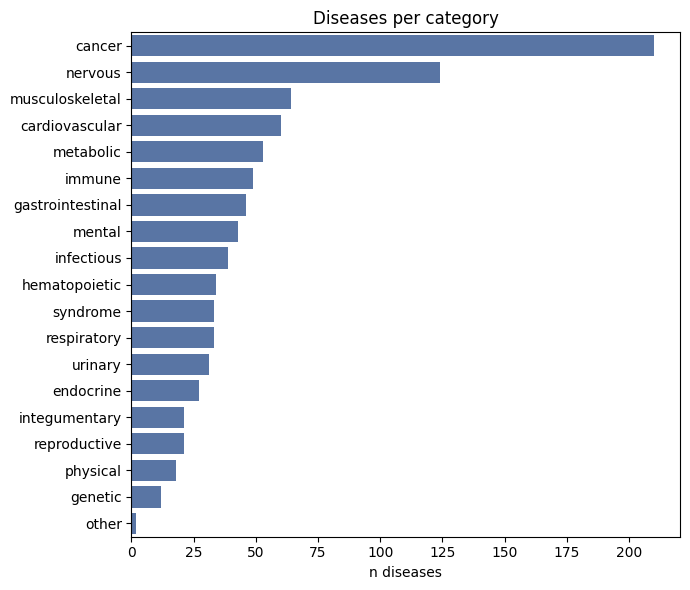

category
cancer              210
nervous             124
musculoskeletal      64
cardiovascular       60
metabolic            53
immune               49
gastrointestinal     46
mental               43
infectious           39
hematopoietic        34
syndrome             33
respiratory          33
urinary              31
endocrine            27
integumentary        21
reproductive         21
physical             18
genetic              12
other                 2


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

order = categories["category"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 6))
sns.countplot(data=categories, y="category", order=order, color="#4C72B0", ax=ax)
ax.set(xlabel="n diseases", ylabel="", title="Diseases per category")
plt.tight_layout(); plt.show()

print(categories["category"].value_counts().to_string())

#### Context graph size by category

Does disease category track with the size of the context the model gets to read?

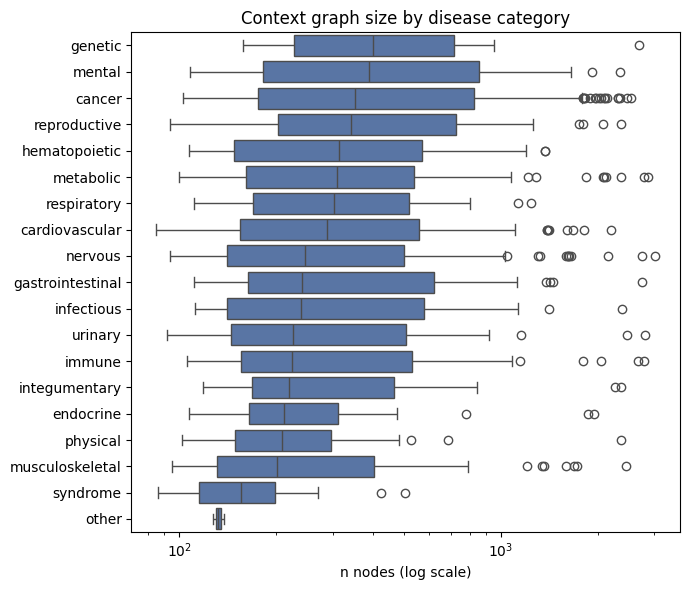

category
genetic             401.0
mental              390.0
cancer              353.0
reproductive        342.0
hematopoietic       315.0
metabolic           309.0
respiratory         304.0
cardiovascular      289.0
nervous             247.0
gastrointestinal    241.5
infectious          240.0
urinary             226.0
immune              224.0
integumentary       220.0
endocrine           212.0
physical            209.5
musculoskeletal     201.5
syndrome            156.0
other               132.5


In [35]:
graph_sizes = pd.DataFrame([
    {"doid": doid,
     "n_nodes": G.number_of_nodes(),
     "n_edges": G.number_of_edges(),
     "n_seed": int(sum(m for _, m in G.nodes(data="m")))}
    for doid, G in context_graphs.items()
]).merge(categories, on="doid")

order = graph_sizes.groupby("category")["n_nodes"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=graph_sizes, y="category", x="n_nodes", order=order, color="#4C72B0", ax=ax)
ax.set(xscale="log", xlabel="n nodes (log scale)", ylabel="", title="Context graph size by disease category")
plt.tight_layout(); plt.show()

print(graph_sizes.groupby("category")["n_nodes"].median().sort_values(ascending=False).to_string())

Every box spans well over an order of magnitude, so category alone is a weak predictor of how much interactome a disease brings with it. Consistent with what we already saw in the DISEASES section: size is driven mostly by how much has been published about a disease, not by which organ system or disease class it belongs to. The 1-hop expansion does not change that — it scales roughly with the gene set it is grown from.

#### Association confidence by category

Do some categories carry stronger evidence than others?

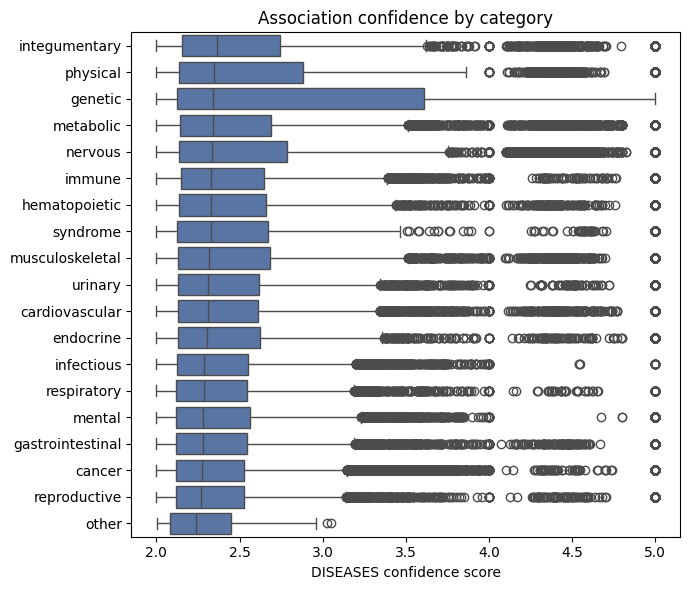

category
integumentary       2.363
physical            2.346
genetic             2.340
metabolic           2.339
nervous             2.337
immune              2.331
hematopoietic       2.329
syndrome            2.328
musculoskeletal     2.319
urinary             2.311
cardiovascular      2.310
endocrine           2.303
infectious          2.288
respiratory         2.285
mental              2.282
gastrointestinal    2.282
cancer              2.275
reproductive        2.270
other               2.238


In [36]:
conf_by_cat = diseases[["doid", "conf"]].merge(categories[["doid", "category"]], on="doid")

order = conf_by_cat.groupby("category")["conf"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=conf_by_cat, y="category", x="conf", order=order, color="#4C72B0", ax=ax)
ax.set(xlabel="DISEASES confidence score", ylabel="", title="Association confidence by category")
plt.tight_layout(); plt.show()

print(conf_by_cat.groupby("category")["conf"].median().sort_values(ascending=False).to_string())

Median confidence barely moves across categories (roughly 2.2-2.4 out of the 0-5 scale) — evidence
quality is fairly uniform once the 2.0 floor has already been applied, so unlike network size,
confidence is not a useful category signal on its own.

#### The largest context graph in each category

A concrete anchor for what "large" means per category — the single biggest context graph in each of the 19.

In [37]:
biggest_per_category = graph_sizes.loc[graph_sizes.groupby("category")["n_nodes"].idxmax()]
biggest_per_category = biggest_per_category.sort_values("n_nodes", ascending=False)
print(biggest_per_category[["category", "doid_name", "n_nodes", "n_edges", "n_seed"]].to_string(index=False))

        category                          doid_name  n_nodes  n_edges  n_seed
         nervous             Sensory system disease     3015    41280    1747
       metabolic         Glucose metabolism disease     2860    45013    1836
         urinary             Urinary system disease     2799    45057    1773
          immune   Primary immunodeficiency disease     2786    43333    1846
gastrointestinal                      Liver disease     2747    46656    1768
         genetic        Autosomal recessive disease     2683    36196    1573
          cancer          Respiratory system cancer     2544    44279    1582
 musculoskeletal                       Bone disease     2448    38619    1546
      infectious           Viral infectious disease     2384    38184    1493
        physical                  Physical disorder     2371    28678    1350
   integumentary       Integumentary system disease     2364    36795    1448
    reproductive Female reproductive system disease     2355    

## FiLM-conditioned GNN on the masked interactome

### Training

Three objectives, and no disease category among them:

- **$\mathcal{L}_\text{edge}$** — hold out 15% of each context graph's interactions and predict them back from the node states, against an equal number of sampled non-edges (binary cross-entropy).
- **$\mathcal{L}_\text{context}$** — a disease-context contrastive loss: disease genes should end up looking different from the *local background* around them.
- **$\mathcal{L}_\text{anti-collapse}$** — the variance/covariance pair from the disease-graph demo, penalising output dimensions that collapse to a constant or duplicate each other.

The mask is the thing $\mathcal{L}_\text{context}$ has to be built around, because the mask is an *input*: $m_i$ reaches every layer through FiLM, so "predict $m_i$ from $h_i$" is free and teaches the model nothing at all. The fix is the one already used for edges — hide it, then ask for it back. At every step a random `HIDE_FRAC` of nodes have their $(m_i, c_i)$ zeroed *before* the encoder sees them, which makes a hidden disease gene indistinguishable, in its own features, from a background protein. The contrastive loss is computed on exactly those nodes, so the only thing left to separate them is the network context around them.

That also gives the objective a meaning outside training: a protein the model has never been told anything about gets scored by where it sits in the interactome relative to the disease, which is the question the whole "mask the interactome" framing is asking. Disease categories are still loaded below, but only to build a train/val split — never as a training signal.

#### Setup

In [38]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv, global_add_pool
from torch_geometric.utils import scatter

from gea.gea import set_seed

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(OUT_DIR / "context_graphs.pkl", "rb") as f:
    context_graphs = pickle.load(f)
categories = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t")
category_by_doid = categories.set_index("doid")["category"]

print(f"device: {device}")
print(f"{len(context_graphs):,} context graphs loaded")

device: cuda
920 context graphs loaded


### From networkx to PyTorch Geometric

Each graph's node feature stays `[m, c, esm_embedding]`, with one change: the raw ESM-2 embeddings are **whitened** first. Real ESM-2 vectors for this protein set are extremely anisotropic — almost every pair has cosine similarity ≈ 0.98 — so a model reading them directly is barely told apart one protein from another. `compress_embeddings_pca` rescales the space so directions that actually differ between proteins count as much as the ones that don't, down to the specified dimensions.

Edges become bidirectional (`GCNConv` expects a directed edge list, so an undirected interaction needs both directions) with `edge_attr = combined_score / 1000`, matching the 0-1 confidence convention used throughout. The two conditioning channels are kept as columns 0 and 1 of `x`, which is all the model needs to split identity from disease state.

In [39]:
from gea.utils import compress_embeddings_pca

esm_reduced_dim = 512

protein_to_esm_raw = {}
for G in context_graphs.values():
    for p in G.nodes:
        if p not in protein_to_esm_raw:
            protein_to_esm_raw[p] = G.nodes[p]["x"][2:]

proteins_ordered = list(protein_to_esm_raw.keys())
esm_raw = torch.stack([protein_to_esm_raw[p] for p in proteins_ordered]).float()
esm_whitened = compress_embeddings_pca(esm_raw, n_components=esm_reduced_dim, whiten=True)
protein_to_esm_white = dict(zip(proteins_ordered, esm_whitened))


def to_pyg(doid, G):
    nodes = sorted(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    cond = torch.stack([G.nodes[n]["x"][:2] for n in nodes]).float()  # [mask, confidence / 5]
    esm = torch.stack([protein_to_esm_white[n] for n in nodes]).float()
    x = torch.cat([cond, esm], dim=1)

    edges = list(G.edges(data="combined_score"))
    src = [idx[u] for u, v, _ in edges] + [idx[v] for u, v, _ in edges]
    dst = [idx[v] for u, v, _ in edges] + [idx[u] for u, v, _ in edges]
    weight = [s / 1000.0 for _, _, s in edges] * 2

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(weight, dtype=torch.float).view(-1, 1)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, doid=doid)


pyg_graphs = {doid: to_pyg(doid, G) for doid, G in context_graphs.items()}
example = next(iter(pyg_graphs.values()))
masked_frac = np.mean([float(d.x[:, 0].mean()) for d in pyg_graphs.values()])
print(f"{len(pyg_graphs):,} PyG graphs built | node feature dim {example.x.shape[1]} "
      f"(mask + confidence + {esm_reduced_dim} whitened ESM)")
print(f"mean masked fraction per graph: {masked_frac:.2f}")

PCA: 1280→512 dims, 95.7% variance retained.
920 PyG graphs built | node feature dim 514 (mask + confidence + 512 whitened ESM)
mean masked fraction per graph: 0.49


#### Held-out diseases, not just held-out edges

We split at the disease level first (90/10, stratified by category so both splits look similar) so
validation measures generalisation to diseases the encoder has never seen at all — a much harder and
more honest test than only hiding a few edges inside diseases it already trained on.

In [40]:
all_doids = list(pyg_graphs.keys())
train_doids, val_doids = train_test_split(
    all_doids, test_size=0.2, random_state=SEED,
    stratify=[category_by_doid[d] for d in all_doids],
)
print(f"{len(train_doids):,} train diseases | {len(val_doids):,} val diseases")

736 train diseases | 184 val diseases


#### Held-out edges within each graph

Within every context graph, `RandomLinkSplit` hides 15% of its interactions from message passing and pairs them with an equal number of sampled non-edges. The encoder only ever sees the remaining 85% (`edge_index`); the held-out set (`edge_label_index` / `edge_label`) is what actually tests whether it recovers structure it wasn't shown, rather than memorising the edges it was trained on. Held-out edges are drawn from the whole context graph, background included — the model is predicting the interactome, not just the disease's own corner of it.

In [41]:
MIN_EDGES = 20  # RandomLinkSplit needs enough edges left to make a sensible held-out set

link_splitter = T.RandomLinkSplit(
    num_val=0.0, num_test=0.15, is_undirected=True,
    add_negative_train_samples=True, neg_sampling_ratio=1.0,
)


def split_edges(doids):
    message, held_out, dropped = [], [], 0
    for doid in doids:
        data = pyg_graphs[doid]
        if data.num_edges < MIN_EDGES:
            dropped += 1
            continue
        train_data, _, test_data = link_splitter(data)
        message.append(train_data)
        held_out.append(test_data)
    return message, held_out, dropped


train_msg, train_eval, n_dropped_train = split_edges(train_doids)
val_msg, val_eval, n_dropped_val = split_edges(val_doids)

print(f"train: {len(train_msg):,} graphs ({n_dropped_train} dropped, < {MIN_EDGES} edges)")
print(f"val:   {len(val_msg):,} graphs ({n_dropped_val} dropped, < {MIN_EDGES} edges)")

train: 736 graphs (0 dropped, < 20 edges)
val:   184 graphs (0 dropped, < 20 edges)


### The model

Encoder: a 3-layer GCN with residual connections — a few rounds of neighbourhood averaging erode a node's own identity, so each layer adds its update on top of the previous representation instead of replacing it — and **FiLM conditioning** after every layer. A small network $f_\theta$ maps each node's disease state to a per-dimension scale and shift,

$$\gamma_i^{(l)}, \beta_i^{(l)} = f_\theta(m_i^{(d)}, c_i^{(d)}), \qquad h_i^{(l)} \leftarrow \gamma_i^{(l)} \odot h_i^{(l)} + \beta_i^{(l)}$$

so the same protein in the same interactome is modulated differently depending on which disease it is being read for, at every depth rather than only at the input. $f_\theta$'s output layer is zero-initialised, so training starts from $\gamma = 1, \beta = 0$ — a plain residual GCN — and the conditioning is something the model has to earn.

Two heads:

- **edge decoder** — an MLP over $[h_i \odot h_j, |h_i - h_j|]$, replacing the plain dot product: it can score a pair on agreement *and* on distance rather than agreement alone.
- **context head** — a linear projection into a smaller space where the contrastive loss lives. Each graph gets a prototype $p_d$, the mean projection of its still-*visible* disease genes, and a node's context score is its cosine similarity to that prototype.

In [42]:
h_dim = esm_reduced_dim  # hidden dim for GCN layers
z_dim = 128
proj_dim = 64            # context head


class FiLM(nn.Module):
    """Per-node feature-wise modulation conditioned on the disease state (m, c)."""

    def __init__(self, hidden_dim, cond_dim=2, film_hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, film_hidden),
            nn.ReLU(),
            nn.Linear(film_hidden, 2 * hidden_dim),
        )
        nn.init.zeros_(self.net[-1].weight)  # start at gamma = 1, beta = 0 (plain residual GCN)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, h, cond):
        gamma, beta = self.net(cond).chunk(2, dim=-1)
        return (1.0 + gamma) * h + beta


class MaskedInteractomeGNN(nn.Module):
    def __init__(self, esm_dim, hidden_dim=h_dim, out_dim=z_dim, n_layers=3, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(esm_dim + 2, hidden_dim)
        self.convs = nn.ModuleList([GCNConv(hidden_dim, hidden_dim) for _ in range(n_layers)])
        self.films = nn.ModuleList([FiLM(hidden_dim) for _ in range(n_layers)])
        self.out_proj = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * out_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, 1)
        )
        self.context_head = nn.Linear(out_dim, proj_dim)

    def encode(self, x, edge_index, edge_weight, hide=None):
        """`hide` zeroes (m, c) for the given nodes, everywhere they would otherwise be read."""
        cond = x[:, :2]
        if hide is not None:
            cond = cond.masked_fill(hide.unsqueeze(-1), 0.0)

        h = self.proj(torch.cat([cond, x[:, 2:]], dim=1))
        for conv, film in zip(self.convs, self.films):
            h = h + F.relu(conv(h, edge_index, edge_weight))
            h = film(h, cond)
            h = F.dropout(h, p=self.dropout, training=self.training)
        return self.out_proj(h)

    def decode_edges(self, h, edge_label_index):
        src, dst = edge_label_index
        pair = torch.cat([h[src] * h[dst], (h[src] - h[dst]).abs()], dim=-1)
        return self.edge_mlp(pair).squeeze(-1)

    def context_scores(self, h, mask, hide, batch, num_graphs):
        """Cosine similarity of every node to its own graph's visible-disease-gene prototype."""
        z = F.normalize(self.context_head(h), dim=-1)
        visible = ((mask > 0.5) & ~hide).float().unsqueeze(-1)
        total = global_add_pool(z * visible, batch, size=num_graphs)
        count = global_add_pool(visible, batch, size=num_graphs).clamp(min=1.0)
        prototype = F.normalize(total / count, dim=-1)
        return (z * prototype[batch]).sum(dim=-1)


esm_dim = example.x.shape[1] - 2  # x = [mask, confidence, esm_embedding]
model = MaskedInteractomeGNN(esm_dim).to(device)
print(model)
print(f"\n{sum(p.numel() for p in model.parameters()):,} parameters")

MaskedInteractomeGNN(
  (proj): Linear(in_features=514, out_features=512, bias=True)
  (convs): ModuleList(
    (0-2): 3 x GCNConv(512, 512)
  )
  (films): ModuleList(
    (0-2): 3 x FiLM(
      (net): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=1024, bias=True)
      )
    )
  )
  (out_proj): Linear(in_features=512, out_features=128, bias=True)
  (edge_mlp): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (context_head): Linear(in_features=128, out_features=64, bias=True)
)

1,260,257 parameters


#### Training

$\mathcal{L} = \mathcal{L}_\text{edge} + \mathcal{L}_\text{context} + \lambda_\text{var}\mathcal{L}_\text{var} + \lambda_\text{cov}\mathcal{L}_\text{cov}$.

$\mathcal{L}_\text{context}$ is InfoNCE with the disease prototype as the query: within each graph the hidden disease genes are the positives and the hidden background proteins are the negatives, so a positive only scores well if it lands closer to the disease prototype than the background proteins around it do. Both classes are hidden, and a hidden disease gene looks exactly like a background protein from its own features, so the separation has to come from the neighbourhood.

Neither main objective actually requires the encoder to spread information across all 128 output dimensions on its own — the **variance** term penalises any dimension whose spread across the batch collapses towards zero, and the **covariance** term penalises dimensions that duplicate each other.

In [43]:
EPOCHS = 100
BATCH_SIZE = 16
HIDE_FRAC = 0.15        # fraction of nodes whose (m, c) is hidden from the encoder
CONTEXT_TAU = 0.1       # InfoNCE temperature
CONTEXT_WEIGHT = 1.0
VAR_WEIGHT = 1.0
COV_WEIGHT = 0.05


def variance_covariance_loss(z, eps=1e-4):
    """Penalise collapsed (near-zero variance) or duplicated (correlated) output dimensions."""
    z = z - z.mean(dim=0, keepdim=True)
    std = torch.sqrt(z.var(dim=0, unbiased=False) + eps)
    var_loss = torch.relu(1.0 - std).mean()

    n, d = z.shape
    cov = (z.T @ z) / (n - 1)
    off_diag = cov.flatten()[1:].view(d - 1, d + 1)[:, :-1].flatten()
    cov_loss = off_diag.pow(2).sum() / d
    return var_loss, cov_loss


def context_loss(scores, mask, hide, batch, num_graphs, tau=CONTEXT_TAU):
    """InfoNCE per graph: hidden disease genes as positives, hidden background as negatives."""
    s = scores / tau
    pos = hide & (mask > 0.5)
    neg = hide & (mask <= 0.5)
    if not pos.any() or not neg.any():
        return scores.new_zeros(())

    b_neg, s_neg = batch[neg], s[neg]
    max_neg = scatter(s_neg, b_neg, dim=0, dim_size=num_graphs, reduce="max")
    lse_neg = max_neg + torch.log(
        scatter(torch.exp(s_neg - max_neg[b_neg]), b_neg, dim=0, dim_size=num_graphs, reduce="sum") + 1e-12
    )
    has_neg = scatter(torch.ones_like(s_neg), b_neg, dim=0, dim_size=num_graphs, reduce="sum") > 0

    b_pos, s_pos = batch[pos], s[pos]
    keep = has_neg[b_pos]
    if not keep.any():
        return scores.new_zeros(())
    b_pos, s_pos = b_pos[keep], s_pos[keep]

    # -log( exp(s_i) / (exp(s_i) + sum_j exp(s_j)) ), averaged within a graph then across graphs
    per_node = -(s_pos - torch.logaddexp(s_pos, lse_neg[b_pos]))
    per_graph = scatter(per_node, b_pos, dim=0, dim_size=num_graphs, reduce="mean")
    scored = scatter(torch.ones_like(per_node), b_pos, dim=0, dim_size=num_graphs, reduce="sum") > 0
    return per_graph[scored].mean()


# the validation hide-sets are drawn once, so every evaluation asks the same question
hide_generator = torch.Generator().manual_seed(SEED)
val_hide = [torch.rand(data.num_nodes, generator=hide_generator) < HIDE_FRAC for data in val_msg]


@torch.no_grad()
def evaluate(model, msg_list, eval_list, hide_list):
    model.eval()
    context_aucs, edge_aucs = [], []
    for msg, held_out, hide in zip(msg_list, eval_list, hide_list):
        x = msg.x.to(device)
        edge_index = msg.edge_index.to(device)
        edge_weight = msg.edge_attr.squeeze(-1).to(device)

        # edges are scored with the full disease state — the way the model is meant to be used
        h = model.encode(x, edge_index, edge_weight)
        logits = model.decode_edges(h, held_out.edge_label_index.to(device))
        y_edge = held_out.edge_label.numpy()
        if len(set(y_edge)) > 1:
            edge_aucs.append(roc_auc_score(y_edge, logits.sigmoid().cpu().numpy()))

        # context is scored with the hidden nodes' own (m, c) zeroed, exactly as in training
        hidden = hide.to(device)
        h_hidden = model.encode(x, edge_index, edge_weight, hide=hidden)
        single = torch.zeros(msg.num_nodes, dtype=torch.long, device=device)
        scores = model.context_scores(h_hidden, x[:, 0], hidden, single, 1)
        y_context = (msg.x[:, 0] > 0.5)[hide].numpy()
        if len(set(y_context)) > 1:
            context_aucs.append(roc_auc_score(y_context, scores[hidden].cpu().numpy()))

    return float(np.mean(context_aucs)), float(np.mean(edge_aucs))


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loader = DataLoader(train_msg, batch_size=BATCH_SIZE, shuffle=True)

history = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = total_edge = total_context = total_var = total_cov = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        hide = torch.rand(batch.num_nodes, device=device) < HIDE_FRAC
        h = model.encode(batch.x, batch.edge_index, batch.edge_attr.squeeze(-1), hide=hide)

        edge_logits = model.decode_edges(h, batch.edge_label_index)
        edge_loss = F.binary_cross_entropy_with_logits(edge_logits, batch.edge_label)

        scores = model.context_scores(h, batch.x[:, 0], hide, batch.batch, batch.num_graphs)
        ctx_loss = context_loss(scores, batch.x[:, 0], hide, batch.batch, batch.num_graphs)

        var_loss, cov_loss = variance_covariance_loss(h)

        loss = (edge_loss + CONTEXT_WEIGHT * ctx_loss
                + VAR_WEIGHT * var_loss + COV_WEIGHT * cov_loss)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        total_edge += edge_loss.item() * batch.num_graphs
        total_context += ctx_loss.item() * batch.num_graphs
        total_var += var_loss.item() * batch.num_graphs
        total_cov += cov_loss.item() * batch.num_graphs

    train_loss = total_loss / len(train_msg)
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        val_context_auc, val_edge_auc = evaluate(model, val_msg, val_eval, val_hide)
        history.append({
            "epoch": epoch, "train_loss": train_loss,
            "edge_loss": total_edge / len(train_msg), "context_loss": total_context / len(train_msg),
            "var_loss": total_var / len(train_msg), "cov_loss": total_cov / len(train_msg),
            "val_context_auc": val_context_auc, "val_edge_auc": val_edge_auc,
        })
        print(f"epoch {epoch:3d} | train loss {train_loss:.4f} | "
              f"val context AUC {val_context_auc:.4f} | val edge AUC {val_edge_auc:.4f}")

/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch   0 | train loss 4.0333 | val context AUC 0.8287 | val edge AUC 0.7478


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  10 | train loss 2.7454 | val context AUC 0.8770 | val edge AUC 0.8698


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

epoch  80 | train loss 1.4758 | val context AUC 0.9240 | val edge AUC 0.9303


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  90 | train loss 1.4470 | val context AUC 0.9256 | val edge AUC 0.9293


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  99 | train loss 1.3857 | val context AUC 0.9308 | val edge AUC 0.9333


#### Is the model learning anything beyond the obvious?

One baseline per objective, both of them free of any learned embedding at all.

**Edges** — the **degree product**: score a candidate pair by how many message-passing edges each endpoint has. Hub proteins interact with everything, so a model that has only learned "hubs interact" would already score well here, and the "network matters" story would rest on nothing more than that.

**Context** — the **visible-seed neighbour vote**: score a hidden node by the fraction of its STRING partners that are still-visible disease genes. This is the whole of guilt-by-association in a single number, and it is exactly the shortcut a message-passing model can settle for. Clearing it means the encoder is using more of the context than a one-hop vote.

In [44]:
final_context_auc, final_edge_auc = evaluate(model, val_msg, val_eval, val_hide)

# degree-product baseline for edge prediction — no learned embedding, just message-passing degree
degree_aucs = []
for msg, held_out in zip(val_msg, val_eval):
    degree = np.bincount(msg.edge_index[0].numpy(), minlength=msg.num_nodes)
    src, dst = held_out.edge_label_index.numpy()
    scores = degree[src] * degree[dst]
    y = held_out.edge_label.numpy()
    if len(set(y)) > 1:
        degree_aucs.append(roc_auc_score(y, scores))
degree_auc = float(np.mean(degree_aucs))

# neighbour-vote baseline for the context objective — the fraction of a hidden node's partners
# that are still-visible disease genes, read straight off the adjacency
neighbour_aucs = []
for msg, hide in zip(val_msg, val_hide):
    visible_seed = ((msg.x[:, 0] > 0.5) & ~hide).float()
    src, dst = msg.edge_index
    vote = scatter(visible_seed[src], dst, dim=0, dim_size=msg.num_nodes, reduce="mean")
    y = (msg.x[:, 0] > 0.5)[hide].numpy()
    if len(set(y)) > 1:
        neighbour_aucs.append(roc_auc_score(y, vote[hide].numpy()))
neighbour_auc = float(np.mean(neighbour_aucs))

print(f"{'':26s}{'context AUC':>14s}{'edge AUC':>12s}")
print(f"{'neighbour vote / degree':26s}{neighbour_auc:14.4f}{degree_auc:12.4f}")
print(f"{'trained model':26s}{final_context_auc:14.4f}{final_edge_auc:12.4f}")

                             context AUC    edge AUC
neighbour vote / degree           0.5426      0.8043
trained model                     0.9308      0.9333


Both numbers are held out twice over: the diseases are ones the encoder never trained on, and within them the edges were hidden from message passing and the nodes' disease state hidden from the encoder.

What to read into them. The **context AUC** is the one worth the most scrutiny, because it is the objective whose honesty had to be engineered: a node's own mask is zeroed before the encoder sees it, so the score can only come from the neighbourhood, and the neighbour-vote baseline says how much of that neighbourhood a single one-hop tally already explains. A margin over it is the encoder using the wider context — who the neighbours *are*, not just how many of them are flagged. No margin would mean the FiLM conditioning is buying nothing that guilt-by-association did not already provide. The **edge AUC** is the more conventional of the two, and mostly guards against the representation collapsing: the sanity check in the Evaluation section below confirms the embedding space is actually being used before trusting any picture drawn from it.

#### Saving trained model

In [45]:
CHECKPOINT_FILE = OUT_DIR / "mask_gnn.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "val_context_auc": final_context_auc,
    "val_edge_auc": final_edge_auc,
    "val_neighbour_auc": neighbour_auc,
    "val_degree_auc": degree_auc,
    "train_doids": train_doids,
    "val_doids": val_doids,
    "hide_frac": HIDE_FRAC,
}, CHECKPOINT_FILE)

print(f"Saved checkpoint to {CHECKPOINT_FILE}")

Saved checkpoint to data/mask-the-interactome/mask_gnn.pt


### Evaluation

#### Training curves

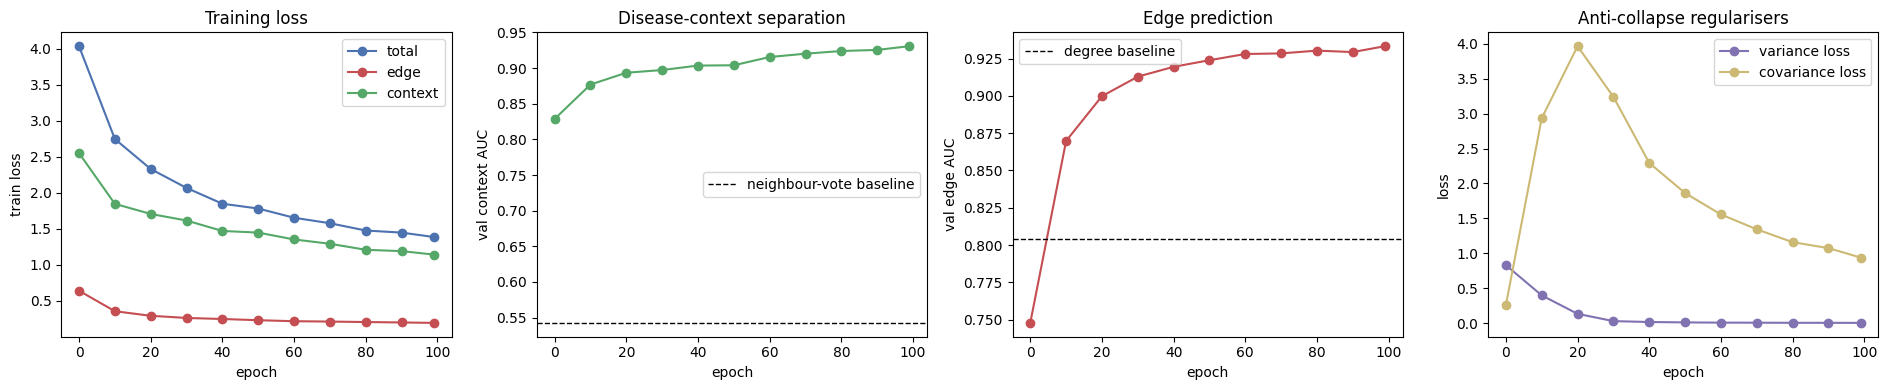

In [46]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="#4C72B0", label="total")
axes[0].plot(history_df["epoch"], history_df["edge_loss"], marker="o", color="#C44E52", label="edge")
axes[0].plot(history_df["epoch"], history_df["context_loss"], marker="o", color="#55A868", label="context")
axes[0].set(xlabel="epoch", ylabel="train loss", title="Training loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_context_auc"], marker="o", color="#55A868")
axes[1].axhline(neighbour_auc, color="k", ls="--", lw=1, label="neighbour-vote baseline")
axes[1].set(xlabel="epoch", ylabel="val context AUC", title="Disease-context separation")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["val_edge_auc"], marker="o", color="#C44E52")
axes[2].axhline(degree_auc, color="k", ls="--", lw=1, label="degree baseline")
axes[2].set(xlabel="epoch", ylabel="val edge AUC", title="Edge prediction")
axes[2].legend()

axes[3].plot(history_df["epoch"], history_df["var_loss"], marker="o", color="#8172B2", label="variance loss")
axes[3].plot(history_df["epoch"], history_df["cov_loss"], marker="o", color="#CCB974", label="covariance loss")
axes[3].set(xlabel="epoch", ylabel="loss", title="Anti-collapse regularisers")
axes[3].legend()

plt.tight_layout(); plt.show()

#### Held-out edge prediction: model vs. degree baseline

The AUC numbers reported earlier are averaged one-graph-at-a-time. Pooling every held-out edge and non-edge across all validation diseases into a single ROC curve shows the same comparison directly.

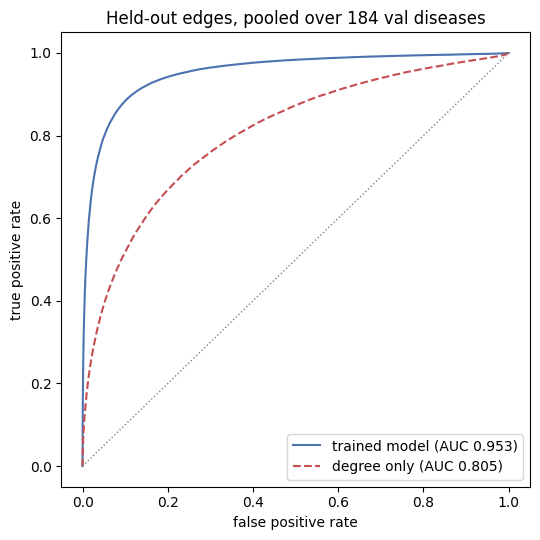

In [47]:
from sklearn.metrics import roc_curve

model.eval()
all_y, all_model_scores, all_degree_scores = [], [], []
with torch.no_grad():
    for msg, held_out in zip(val_msg, val_eval):
        h = model.encode(msg.x.to(device), msg.edge_index.to(device), msg.edge_attr.squeeze(-1).to(device))
        logits = model.decode_edges(h, held_out.edge_label_index.to(device)).sigmoid().cpu().numpy()

        degree = np.bincount(msg.edge_index[0].numpy(), minlength=msg.num_nodes)
        src, dst = held_out.edge_label_index.numpy()

        all_y.append(held_out.edge_label.numpy())
        all_model_scores.append(logits)
        all_degree_scores.append(degree[src] * degree[dst])

y_all = np.concatenate(all_y)
model_scores = np.concatenate(all_model_scores)
degree_scores = np.concatenate(all_degree_scores)

pooled_model_auc = roc_auc_score(y_all, model_scores)
pooled_degree_auc = roc_auc_score(y_all, degree_scores)

fpr_m, tpr_m, _ = roc_curve(y_all, model_scores)
fpr_d, tpr_d, _ = roc_curve(y_all, degree_scores)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr_m, tpr_m, color="#4C72B0", label=f"trained model (AUC {pooled_model_auc:.3f})")
ax.plot(fpr_d, tpr_d, color="#C44E52", ls="--", label=f"degree only (AUC {pooled_degree_auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1, ls=":")
ax.set(xlabel="false positive rate", ylabel="true positive rate",
       title=f"Held-out edges, pooled over {len(val_msg)} val diseases")
ax.legend()
plt.tight_layout(); plt.show()

#### Does performance vary by disease size?

A single mean AUC can hide a lot: maybe the model is great on large, well-connected contexts and close to chance on small ones. Breaking both objectives down per validation disease, and against context graph size, checks that directly.

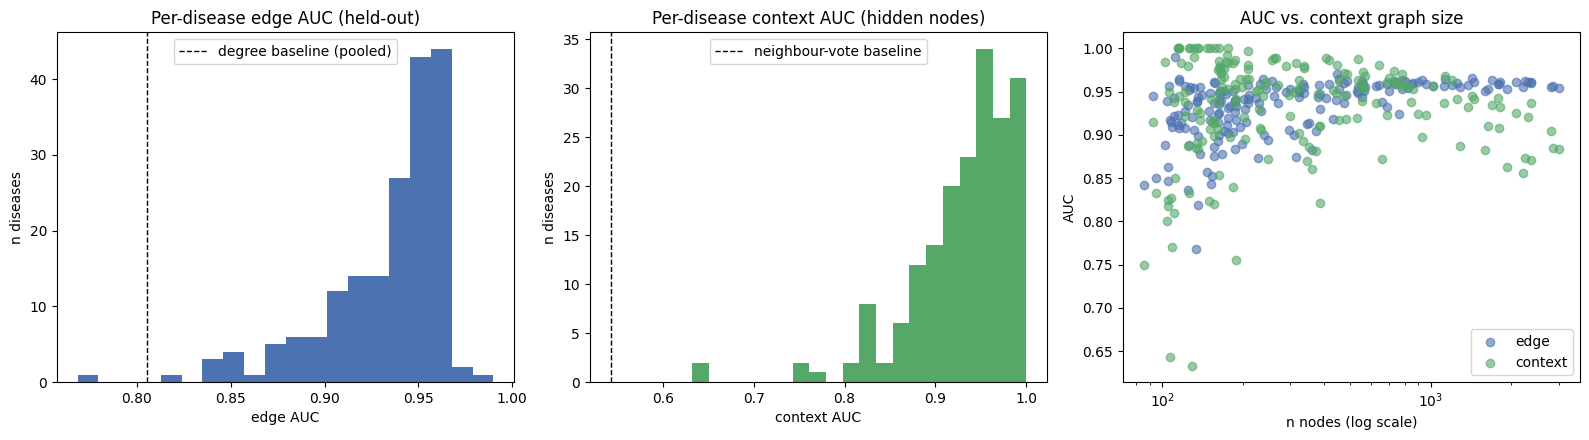

corr(n_nodes, edge AUC)    = 0.392
corr(n_nodes, context AUC) = -0.076
         edge_auc  context_auc
count  184.000000   184.000000
mean     0.933284     0.930817
std      0.033467     0.060245
min      0.768430     0.632653
25%      0.916720     0.906250
50%      0.944432     0.945369
75%      0.957060     0.971909
max      0.990001     1.000000


In [48]:
per_disease = []
model.eval()
with torch.no_grad():
    for msg, held_out, hide in zip(val_msg, val_eval, val_hide):
        x = msg.x.to(device)
        edge_index = msg.edge_index.to(device)
        edge_weight = msg.edge_attr.squeeze(-1).to(device)

        h = model.encode(x, edge_index, edge_weight)
        logits = model.decode_edges(h, held_out.edge_label_index.to(device)).sigmoid().cpu().numpy()
        y = held_out.edge_label.numpy()

        hidden = hide.to(device)
        h_hidden = model.encode(x, edge_index, edge_weight, hide=hidden)
        single = torch.zeros(msg.num_nodes, dtype=torch.long, device=device)
        scores = model.context_scores(h_hidden, x[:, 0], hidden, single, 1)[hidden].cpu().numpy()
        y_context = (msg.x[:, 0] > 0.5)[hide].numpy()

        if len(set(y)) > 1 and len(set(y_context)) > 1:
            per_disease.append({
                "doid": msg.doid, "n_nodes": msg.num_nodes,
                "edge_auc": roc_auc_score(y, logits),
                "context_auc": roc_auc_score(y_context, scores),
            })

per_disease = pd.DataFrame(per_disease)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(per_disease["edge_auc"], bins=20, color="#4C72B0")
axes[0].axvline(pooled_degree_auc, color="k", ls="--", lw=1, label="degree baseline (pooled)")
axes[0].set(xlabel="edge AUC", ylabel="n diseases", title="Per-disease edge AUC (held-out)")
axes[0].legend()

axes[1].hist(per_disease["context_auc"], bins=20, color="#55A868")
axes[1].axvline(neighbour_auc, color="k", ls="--", lw=1, label="neighbour-vote baseline")
axes[1].set(xlabel="context AUC", ylabel="n diseases", title="Per-disease context AUC (hidden nodes)")
axes[1].legend()

axes[2].scatter(per_disease["n_nodes"], per_disease["edge_auc"], alpha=0.6, color="#4C72B0", label="edge")
axes[2].scatter(per_disease["n_nodes"], per_disease["context_auc"], alpha=0.6, color="#55A868", label="context")
axes[2].set(xscale="log", xlabel="n nodes (log scale)", ylabel="AUC", title="AUC vs. context graph size")
axes[2].legend()

plt.tight_layout(); plt.show()

print(f"corr(n_nodes, edge AUC)    = {per_disease['n_nodes'].corr(per_disease['edge_auc']):.3f}")
print(f"corr(n_nodes, context AUC) = {per_disease['n_nodes'].corr(per_disease['context_auc']):.3f}")
print(per_disease[["edge_auc", "context_auc"]].describe())

#### Extracting node, edge and graph embeddings

For everything below we re-encode every disease using its **full** context graph — all edges, nothing hidden, the complete disease state — since these embeddings are meant for downstream analysis rather than for testing held-out generalisation. One forward pass per disease gives the node states $h_i^{(d)}$, and the three levels are read off them:

- **node** — $h_i^{(d)}$ itself, one row per (disease, protein), local background included.
- **edge** — $e_{ij}^{(d)} = \dfrac{h_i^{(d)} \odot h_j^{(d)}}{\lVert h_i^{(d)} - h_j^{(d)} \rVert_2}$: how much the two endpoints agree, divided by how far apart they are. L2 rather than L1 in the denominator, because after PCA-whitening the coordinate axes carry no meaning of their own and an L1 norm would make the embedding depend on that arbitrary basis. Keeping it a ratio instead of the concatenation $[h_i \odot h_j, |h_i - h_j|]$ the edge decoder scores with also keeps every level at the same 128 dimensions, so the three SAEs below are directly comparable. A ratio does need a guard, though: two endpoints landing on top of each other would send a row off to infinity and let it dominate everything trained on top of it, so the denominator is clamped at a low quantile of the distances the model actually produces rather than at an arbitrary constant.
- **graph** — $g_d = g_d^+ - g_d^-$, the confidence-weighted mean over the masked proteins minus the plain mean over the local background:

$$g_d^+ = \frac{\sum_i m_i^{(d)} c_i^{(d)} h_i^{(d)}}{\sum_i m_i^{(d)} c_i^{(d)}}, \qquad g_d^- = \frac{\sum_i (1 - m_i^{(d)}) h_i^{(d)}}{\sum_i (1 - m_i^{(d)})}$$

  A disease is then described by what makes its genes *different* from the interactome immediately around them, rather than by the composition of its gene set alone — which is the failure mode a plain mean-pooled readout falls into, since a mean over node states is a composition statistic by construction.

Only one direction is kept per edge pair, matching the convention `gea.gea.extract_embeddings` already uses for LIONESS graphs.

In [49]:
from gea.gea import ENTITY_SEP, GENE_PAIR_SEP, save_embeddings

def edge_distance_floor(quantile=0.01, n_sample=50):
    """A floor for the edge denominator, read off the distances the model actually produces.

    Dividing by ||h_i - h_j|| is unbounded: two endpoints that land on top of each other would
    produce a row thousands of times longer than a typical one, which then dominates the SAE (and
    overflows float16 on the way to disk). Clamping the denominator at a low quantile of the real
    distance distribution bounds the ratio without picking an arbitrary constant.
    """
    rng = np.random.default_rng(SEED)
    sample = rng.choice(list(pyg_graphs), size=min(n_sample, len(pyg_graphs)), replace=False)

    distances = []
    model.eval()
    with torch.no_grad():
        for doid in sample:
            data = pyg_graphs[doid]
            h = model.encode(
                data.x.to(device), data.edge_index.to(device), data.edge_attr.squeeze(-1).to(device)
            ).cpu()
            src, dst = data.edge_index
            keep = src < dst
            distances.append((h[src[keep]] - h[dst[keep]]).norm(dim=-1).numpy())

    distances = np.concatenate(distances)
    floor = float(np.quantile(distances, quantile))
    print(f"endpoint distance over {len(sample)} graphs: median {np.median(distances):.2f} | "
          f"min {distances.min():.3f} | q{quantile:.0%} {floor:.2f} → denominator floor")
    return floor


EDGE_DIST_FLOOR = edge_distance_floor()


def extract_all_levels():
    graph_emb, graph_entities, graph_doid, graph_category = [], [], [], []
    node_emb, node_entities, node_doid, node_category, node_protein, node_mask = [], [], [], [], [], []
    edge_emb, edge_entities, edge_doid, edge_category, edge_a, edge_b, edge_n_seed = [], [], [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for doid, data in pyg_graphs.items():
            h = model.encode(
                data.x.to(device), data.edge_index.to(device), data.edge_attr.squeeze(-1).to(device)
            ).cpu()
            nodes = sorted(context_graphs[doid].nodes())  # same order used by to_pyg
            category = category_by_doid.get(doid, "other")
            m, c = data.x[:, 0], data.x[:, 1]

            # graph level: masked-minus-background contrast
            w_pos = (m * c).unsqueeze(-1)
            w_neg = (1.0 - m).unsqueeze(-1)
            g_pos = (w_pos * h).sum(0) / w_pos.sum().clamp(min=1e-8)
            g_neg = (w_neg * h).sum(0) / w_neg.sum().clamp(min=1e-8)
            graph_emb.append((g_pos - g_neg).unsqueeze(0).numpy())
            graph_entities.append(doid)
            graph_doid.append(doid)
            graph_category.append(category)

            # node level
            node_emb.append(h.numpy())
            node_entities.extend(f"{doid}{ENTITY_SEP}{p}" for p in nodes)
            node_doid.extend([doid] * len(nodes))
            node_category.extend([category] * len(nodes))
            node_protein.extend(nodes)
            node_mask.append(m.numpy().astype(np.uint8))

            # edge level
            src, dst = data.edge_index[0].numpy(), data.edge_index[1].numpy()
            keep = src < dst  # both directions are stored; keep one copy per pair
            src, dst = src[keep], dst[keep]
            distance = (h[src] - h[dst]).norm(dim=-1, keepdim=True).clamp(min=EDGE_DIST_FLOOR)
            edge_emb.append(((h[src] * h[dst]) / distance).numpy())
            edge_entities.extend(f"{doid}{ENTITY_SEP}{nodes[s]}{GENE_PAIR_SEP}{nodes[d]}" for s, d in zip(src, dst))
            edge_doid.extend([doid] * len(src))
            edge_category.extend([category] * len(src))
            edge_a.extend(nodes[s] for s in src)
            edge_b.extend(nodes[d] for d in dst)
            edge_n_seed.append((m[src] + m[dst]).numpy().astype(np.uint8))

    graph_export = {
        "embeddings": np.concatenate(graph_emb, axis=0).astype(np.float32),
        "entities": np.array(graph_entities, dtype=object),
        "doid": np.array(graph_doid, dtype=object),
        "category": np.array(graph_category, dtype=object),
        "level": np.array("graph"),
    }
    node_export = {
        "embeddings": np.concatenate(node_emb, axis=0).astype(np.float32),
        "entities": np.array(node_entities, dtype=object),
        "doid": np.array(node_doid, dtype=object),
        "category": np.array(node_category, dtype=object),
        "protein": np.array(node_protein, dtype=object),
        "mask": np.concatenate(node_mask),
        "level": np.array("node"),
    }
    edge_export = {
        "embeddings": np.concatenate(edge_emb, axis=0).astype(np.float16),
        "entities": np.array(edge_entities, dtype=object),
        "doid": np.array(edge_doid, dtype=object),
        "category": np.array(edge_category, dtype=object),
        "protein_a": np.array(edge_a, dtype=object),
        "protein_b": np.array(edge_b, dtype=object),
        "n_seed_endpoints": np.concatenate(edge_n_seed),
        "level": np.array("edge"),
    }
    return graph_export, node_export, edge_export


graph_export, node_export, edge_export = extract_all_levels()
print(f"graph: {graph_export['embeddings'].shape}")
print(f"node:  {node_export['embeddings'].shape}  ({node_export['mask'].mean():.1%} masked)")
print(f"edge:  {edge_export['embeddings'].shape}")

# the edge embedding divides by a distance, so it is worth seeing how long its rows actually get
edge_norms = np.linalg.norm(edge_export["embeddings"].astype(np.float32), axis=1)
print("edge row norm: " + " | ".join(
    f"q{int(q * 100)} {np.quantile(edge_norms, q):.2f}" for q in (0.5, 0.9, 0.99, 1.0)))

endpoint distance over 50 graphs: median 11.02 | min 0.025 | q1% 4.01 → denominator floor
graph: (920, 128)
node:  (455120, 128)  (53.6% masked)
edge:  (5796601, 128)
edge row norm: q50 1.05 | q90 1.83 | q99 3.59 | q100 40.58


#### Graph-level embeddings, visualised by category

The encoder never saw disease category — it only ever optimised the node and edge objectives. Colouring
its graph embeddings by category here is a purely post-hoc diagnostic: any clustering by category
would be an emergent property of gene identity + topology, not something trained for directly.

/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


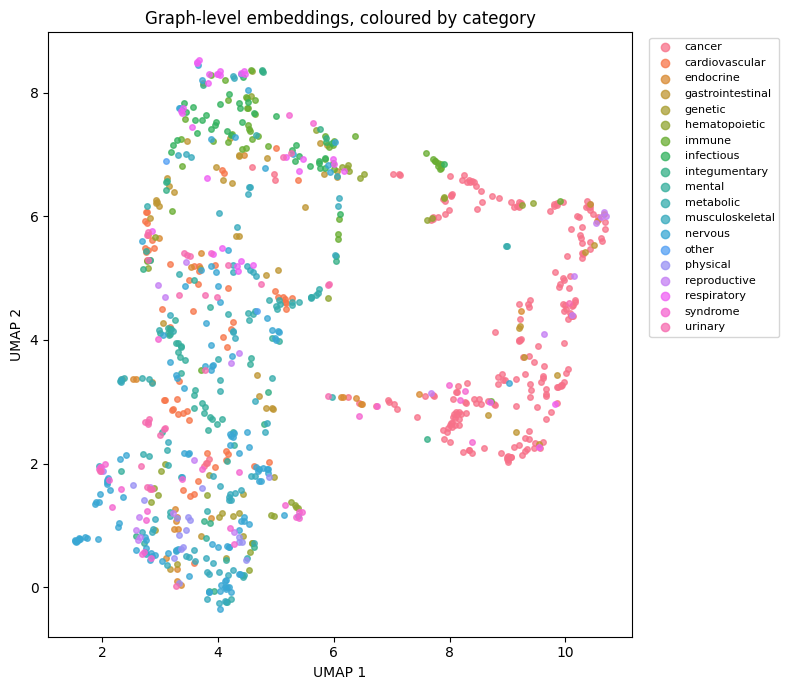

In [50]:
import umap

reducer = umap.UMAP(random_state=SEED)
graph_umap = reducer.fit_transform(graph_export["embeddings"])
graph_categories = graph_export["category"]

cats = sorted(set(graph_categories))
palette = dict(zip(cats, sns.color_palette("husl", len(cats))))

fig, ax = plt.subplots(figsize=(8, 7))
for cat in cats:
    mask = graph_categories == cat
    ax.scatter(graph_umap[mask, 0], graph_umap[mask, 1], s=16, alpha=0.75, color=palette[cat], label=cat)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2", title="Graph-level embeddings, coloured by category")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=1.5)
plt.tight_layout(); plt.show()

#### Graph-level embeddings, one panel per category

The single scatter above can only give a handful of categories a distinct colour before it turns into a legend soup. Splitting into one small panel per category — same UMAP layout underneath, just the categories with the most diseases shown first — makes it possible to see whether a Disease Ontology branch actually occupies its own region of the map, or is sprayed across all of it.

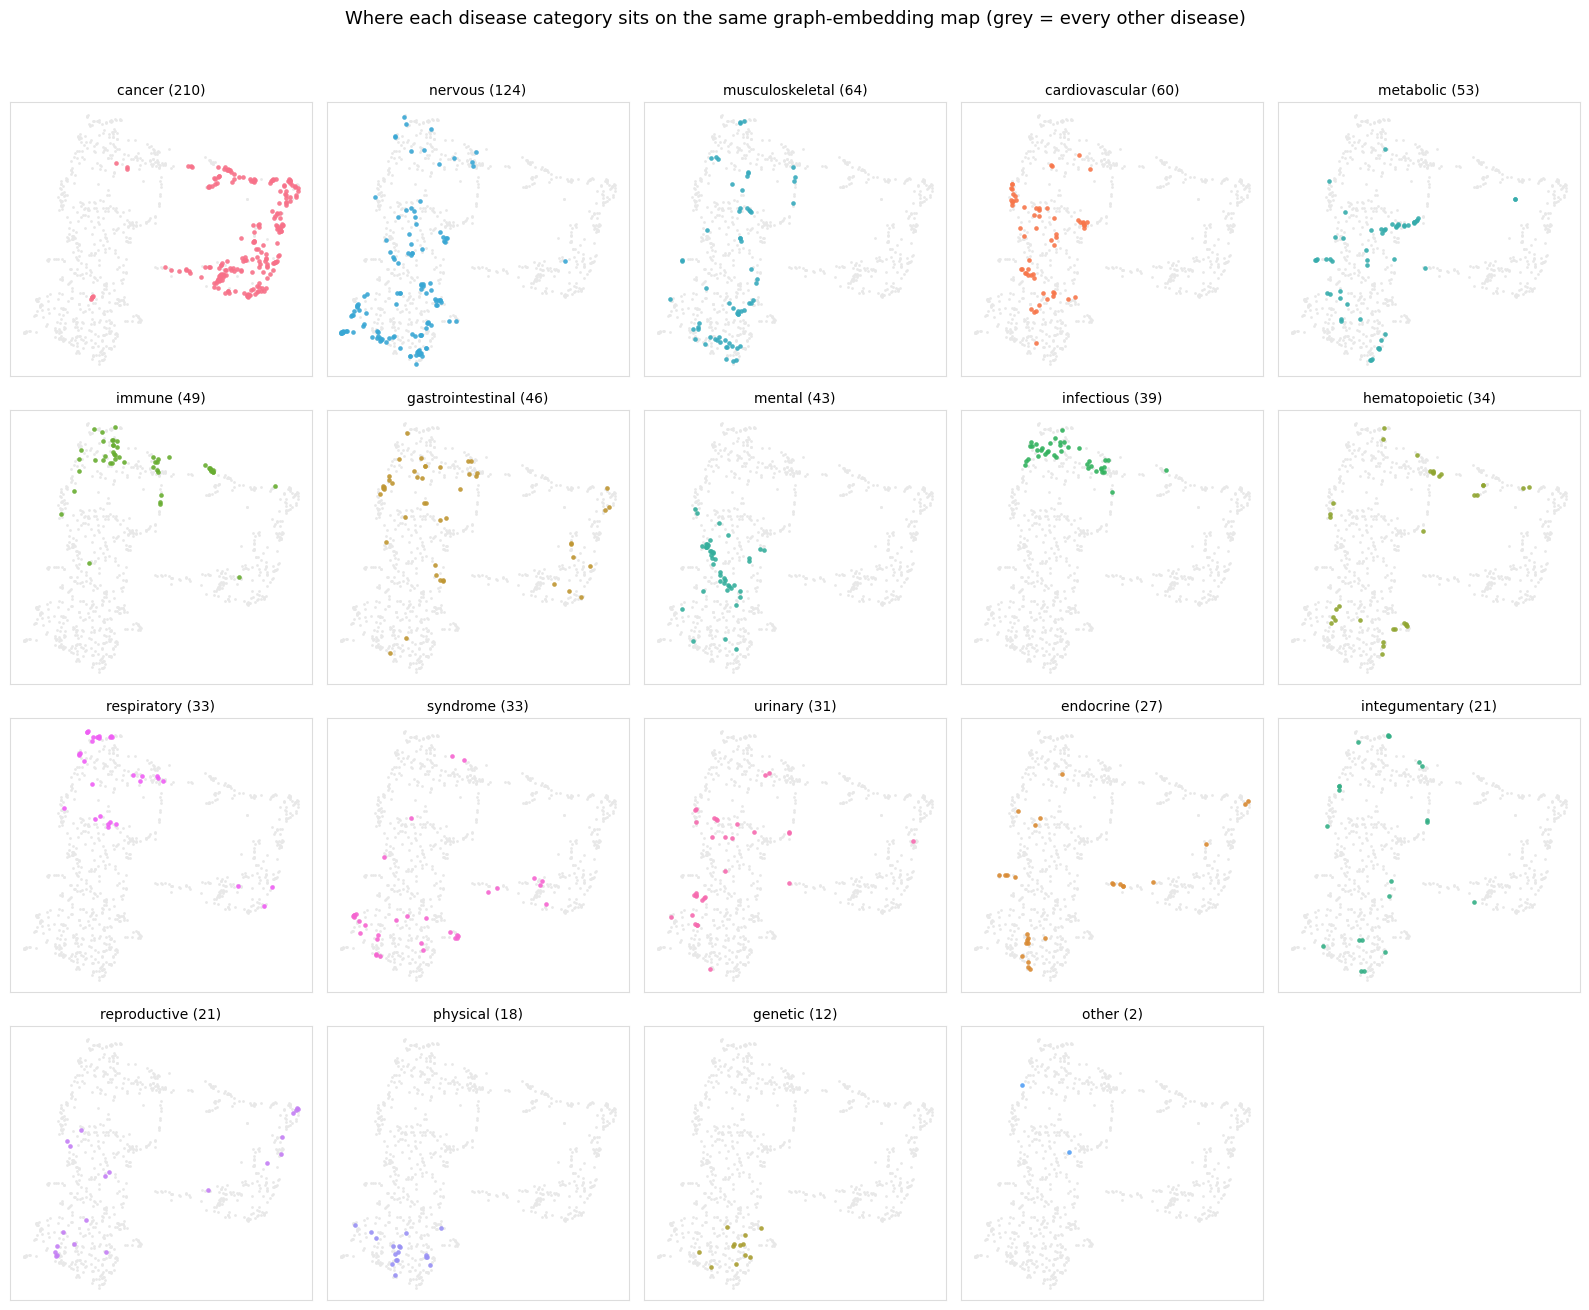

In [51]:
panel_order = sorted(cats, key=lambda c: -(graph_categories == c).sum())
ncol = 5
nrow = int(np.ceil(len(panel_order) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.2 * nrow), sharex=True, sharey=True)
for ax, cat in zip(axes.ravel(), panel_order):
    mask = graph_categories == cat
    ax.scatter(graph_umap[~mask, 0], graph_umap[~mask, 1], s=4, color="#e8e8e8", linewidths=0, zorder=1)
    ax.scatter(graph_umap[mask, 0], graph_umap[mask, 1], s=11, color=palette[cat], alpha=0.9, linewidths=0, zorder=2)
    ax.set_title(f"{cat} ({int(mask.sum())})", fontsize=10)
    ax.set(xticks=[], yticks=[])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("#dddddd")
for ax in axes.ravel()[len(panel_order):]:
    ax.axis("off")
fig.suptitle("Where each disease category sits on the same graph-embedding map "
             "(grey = every other disease)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

#### Node-level embeddings, visualised by category

There are far too many node instances (the same protein re-embedded differently in every disease context it appears in, masked or background) to plot directly, so we UMAP a random sample and colour each point by the category of the disease context it came from.

/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


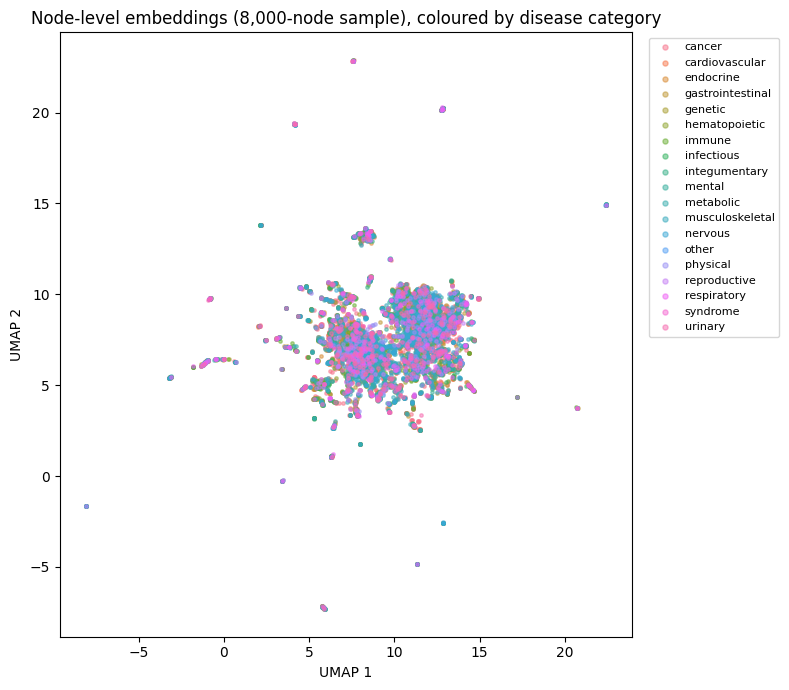

In [52]:
N_NODE_SAMPLE = 8000

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(node_export["embeddings"]), size=N_NODE_SAMPLE, replace=False)
node_sample_emb = node_export["embeddings"][sample_idx]
node_sample_cat = node_export["category"][sample_idx]

node_umap = umap.UMAP(random_state=SEED).fit_transform(node_sample_emb)

fig, ax = plt.subplots(figsize=(8, 7))
for cat in cats:
    mask = node_sample_cat == cat
    ax.scatter(node_umap[mask, 0], node_umap[mask, 1], s=6, alpha=0.5, color=palette[cat], label=cat)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2",
       title=f"Node-level embeddings ({N_NODE_SAMPLE:,}-node sample), coloured by disease category")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=1.5)
plt.tight_layout(); plt.show()

#### Sanity check: is the embedding space actually being used?

A UMAP plot always finds *some* 2D layout, whether or not the underlying space has real structure — worth checking directly rather than trusting the picture. PCA on the graph- and node-level embeddings shows how much of the variance sits in just the first couple of components; if that number were close to 100%, the whole 128-dim space would have collapsed onto a line or a plane and the UMAP picture above would be showing noise, not structure.

In [53]:
from sklearn.decomposition import PCA

for name, emb in [("graph", graph_export["embeddings"]), ("node", node_sample_emb)]:
    pca = PCA(n_components=5).fit(emb)
    cum = np.cumsum(pca.explained_variance_ratio_)
    print(f"{name:>5}-level: PC1 alone {pca.explained_variance_ratio_[0]:.1%} | "
          f"first 5 PCs {cum[-1]:.1%} of variance")

graph-level: PC1 alone 24.4% | first 5 PCs 61.5% of variance
 node-level: PC1 alone 7.3% | first 5 PCs 20.9% of variance


#### Saving the three levels

Node, edge and graph embeddings, saved separately so they can be used to train the three GEA SAEs (node-, edge- and graph-level) afterwards. All three are 128-dimensional, which is the point of writing the edge level as a ratio rather than a concatenation. Entity ids follow `gea.gea`'s own naming convention (`ENTITY_SEP`, `GENE_PAIR_SEP`) so they read the same way as the LIONESS exports do. Edge-level is by far the largest (one row per interaction per disease), so it's stored as `float16`.

In [54]:
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "graph": save_embeddings(EMBEDDINGS_DIR / "mask_gnn_graph.npz", graph_export),
    "node": save_embeddings(EMBEDDINGS_DIR / "mask_gnn_node.npz", node_export),
    "edge": save_embeddings(EMBEDDINGS_DIR / "mask_gnn_edge.npz", edge_export),
}
for level, path in paths.items():
    size_mb = Path(path).stat().st_size / 1e6
    print(f"{level:>5}: {path}  ({size_mb:.0f} MB)")

graph: data/mask-the-interactome/embeddings/mask_gnn_graph.npz  (0 MB)
 node: data/mask-the-interactome/embeddings/mask_gnn_node.npz  (252 MB)
 edge: data/mask-the-interactome/embeddings/mask_gnn_edge.npz  (1848 MB)


## Sparse Autoencoders

### Setup

Each SAE trains directly on the embeddings already saved to disk — this section doesn't depend on anything from the GNN training kernel state, only the three `.npz` files.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

import gea.gea as gea_module
from gea.gea import ShallowSAE, train_sae, set_seed

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Same train/val disease split the GNN used, saved inside its own checkpoint — node- and edge-level
# training below restricts itself to train_doids so val_doids stays genuinely unseen by everything,
# including the concept-annotation test later in this notebook.
gnn_ckpt = torch.load(OUT_DIR / "mask_gnn.pt", map_location="cpu", weights_only=False)
train_doids, val_doids = gnn_ckpt["train_doids"], gnn_ckpt["val_doids"]

print(f"device: {device}")
print(f"{len(train_doids):,} GNN-train diseases | {len(val_doids):,} GNN-held-out diseases")

device: cuda
736 GNN-train diseases | 184 GNN-held-out diseases


### A minimal dataset for `train_sae`

`gea.gea.train_sae` only ever reads `batch['embedding']`, but `gea.dataloader.EmbeddingDataset` also requires `prediction`/`target` fields from the LIONESS/GNNModel pipeline that our unsupervised export never produced. A dataset that wraps just the embeddings is all that's actually needed here.

In [2]:
class EmbeddingOnlyDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = torch.tensor(np.asarray(embeddings).astype(np.float32))

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return {"embedding": self.embeddings[idx]}

### Training one SAE per level

`ShallowSAE` is a plain dictionary-learning autoencoder (linear encoder, ReLU, linear decoder, L1
sparsity penalty, decoder weights renormalised every step so features can't collapse to zero).
Graph-level trains on all 920 diseases — it's never used in the held-out concept-annotation test
below, so there is nothing to protect it from. Node- and edge-level train **only on `train_doids`**,
the same diseases the GNN itself trained on: that way `val_doids` stays genuinely unseen by the SAE
too, and the held-out test later in this notebook doesn't need a second, separately-trained SAE just
to get that guarantee — training the same dictionary twice would be pure waste. The progress bar is
muted (`train_sae`'s own `tqdm` swapped out during the call) so it doesn't flood the notebook with
thousands of progress lines.

In [3]:
class _NoOpProgressBar:
    """Drop-in tqdm replacement: same interface, does nothing — keeps train_sae's
    per-step progress bar out of the saved notebook (it would otherwise dump
    thousands of lines of text into the cell output)."""
    def __init__(self, iterable, **kwargs):
        self._iterable = iterable

    def __iter__(self):
        return iter(self._iterable)

    def set_postfix(self, **kwargs):
        pass

    def update(self, *args, **kwargs):
        pass

    def close(self):
        pass


def train_disease_sae(level, latent_dim, epochs, batch_size=256, val_frac=0.1, doid_subset=None):
    data = np.load(EMBEDDINGS_DIR / f"mask_gnn_{level}.npz", allow_pickle=True)
    embeddings = data["embeddings"]
    if doid_subset is not None:
        embeddings = embeddings[np.isin(data["doid"], doid_subset)]
    dataset = EmbeddingOnlyDataset(embeddings)

    n_val = max(1, int(val_frac * len(dataset)))
    train_ds, val_ds = random_split(
        dataset, [len(dataset) - n_val, n_val],
        generator=torch.Generator().manual_seed(SEED),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    sae = ShallowSAE(in_dim=dataset.embeddings.shape[1], latent_dim=latent_dim)
    model_path = EMBEDDINGS_DIR / f"sae_{level}.pt"
    loss_path = EMBEDDINGS_DIR / f"sae_{level}_loss.csv"

    scope = (f"{len(dataset):,} rows from {len(doid_subset):,} diseases" if doid_subset is not None
             else f"{len(dataset):,} rows")
    print(f"=== {level}-level SAE: {scope}, {dataset.embeddings.shape[1]} -> {latent_dim} dims ===")

    _tqdm, gea_module.tqdm = gea_module.tqdm, _NoOpProgressBar
    try:
        train_sae(sae, train_loader, val_loader, device, epochs=epochs,
                  model_path=str(model_path), loss_path=str(loss_path))
    finally:
        gea_module.tqdm = _tqdm

    sae.load_state_dict(torch.load(model_path))  # keep the best-val checkpoint, not the last epoch
    return sae

#### Graph-level SAE

In [58]:
graph_sae = train_disease_sae("graph", latent_dim=1024, epochs=200, batch_size=128)

=== graph-level SAE: 920 rows, 128 -> 1024 dims ===

Training losses saved to: data/mask-the-interactome/embeddings/sae_graph_loss.csv
Best validation loss: 0.0247 at epoch 132


#### Node-level SAE

Trained only on `train_doids` rows (see above).

In [59]:
node_sae = train_disease_sae("node", latent_dim=1024, epochs=30, batch_size=256, doid_subset=train_doids)

=== node-level SAE: 362,063 rows from 736 diseases, 128 -> 1024 dims ===

Training losses saved to: data/mask-the-interactome/embeddings/sae_node_loss.csv
Best validation loss: 0.0472 at epoch 29


#### Edge-level SAE

Trained only on `train_doids` rows (see above).

In [60]:
edge_sae = train_disease_sae("edge", latent_dim=1024, epochs=20, batch_size=1024, doid_subset=train_doids)

=== edge-level SAE: 4,584,044 rows from 736 diseases, 128 -> 1024 dims ===

Training losses saved to: data/mask-the-interactome/embeddings/sae_edge_loss.csv
Best validation loss: 0.0034 at epoch 19


#### Training curves, all three levels

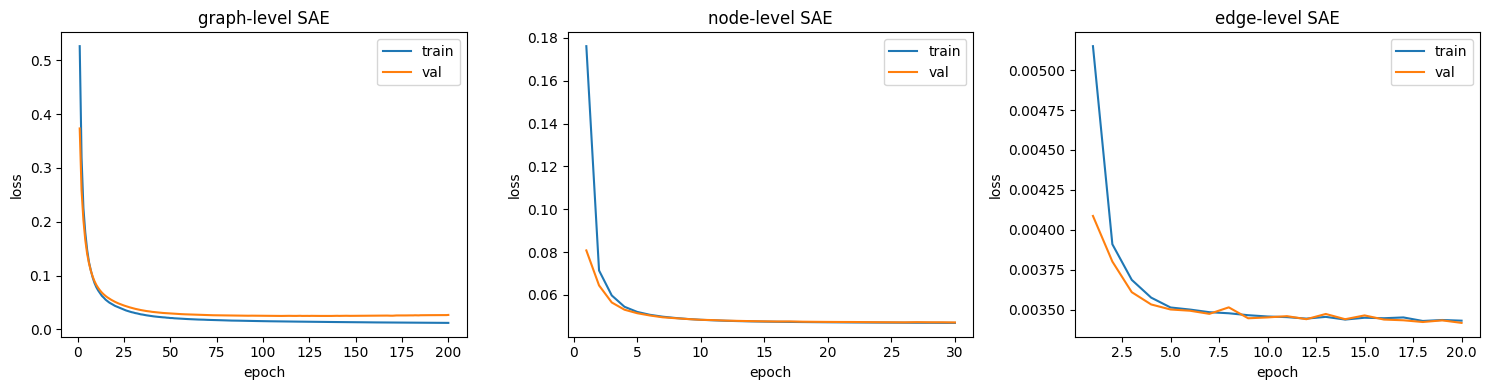

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, level in zip(axes, ["graph", "node", "edge"]):
    loss_df = pd.read_csv(EMBEDDINGS_DIR / f"sae_{level}_loss.csv")
    ax.plot(loss_df["epoch"], loss_df["train_loss"], label="train")
    ax.plot(loss_df["epoch"], loss_df["val_loss"], label="val")
    ax.set(xlabel="epoch", ylabel="loss", title=f"{level}-level SAE")
    ax.legend()
plt.tight_layout(); plt.show()

#### Saving the SAE weights

`train_sae` already checkpoints the best-validation state to disk during training (`sae_{level}.pt`, one per level) — this just confirms what's there.

In [62]:
sae_paths = {level: EMBEDDINGS_DIR / f"sae_{level}.pt" for level in ["graph", "node", "edge"]}
for level, path in sae_paths.items():
    size_kb = path.stat().st_size / 1e3
    print(f"{level:>5}: {path}  ({size_kb:.0f} KB)")

graph: data/mask-the-interactome/embeddings/sae_graph.pt  (1056 KB)
 node: data/mask-the-interactome/embeddings/sae_node.pt  (1056 KB)
 edge: data/mask-the-interactome/embeddings/sae_edge.pt  (1056 KB)


## Evaluation of SAEs

### Are the three dictionaries healthy?

Every section below reads meaning out of *which* SAE features fire, so the first question is
whether the dictionaries are in a state where that reading means anything. Four numbers per
level, none of which the training curves show:

- **dead features** — entries that never fire on any row. A dead feature is not a concept the
  model declined to find, it is dictionary capacity that was never used.
- **L0** — how many features a single row actually lights up. This decides how much work the
  phrase "feature *f* fires here" is doing: a code that lights up 4% of itself per row is making
  a selection, one that lights up 15% barely is.
- **reconstruction R²** — how much of the embedding variance the sparse code puts back. If the
  code cannot reproduce the embedding, whatever it describes is not the representation the GNN
  produced.
- **feature splitting** — the cosine between a feature's decoder direction and the nearest other
  one. Near 1 means two entries point the same way and have split one concept in two; a term
  assigned to one of them is equally an annotation of the other, and counting them separately
  double-counts the finding.

The edge level is sampled: distributional statistics over 400,000 of its 5.8M rows are the same
statistics, at a fraction of the memory.

         rows  dead  alive   L0  L0_pct  median_rate  max_rate  recon_r2  twin_cos  twin_frac_0.9
level                                                                                            
graph     920 0.102    516 45.7  0.0446       0.0304      0.81     0.941     0.297              0
node   400000 0.085    885  159   0.155        0.161     0.432     0.986     0.385              0
edge   400000 0.219    765 36.8  0.0359       0.0425     0.325     0.852     0.357              0


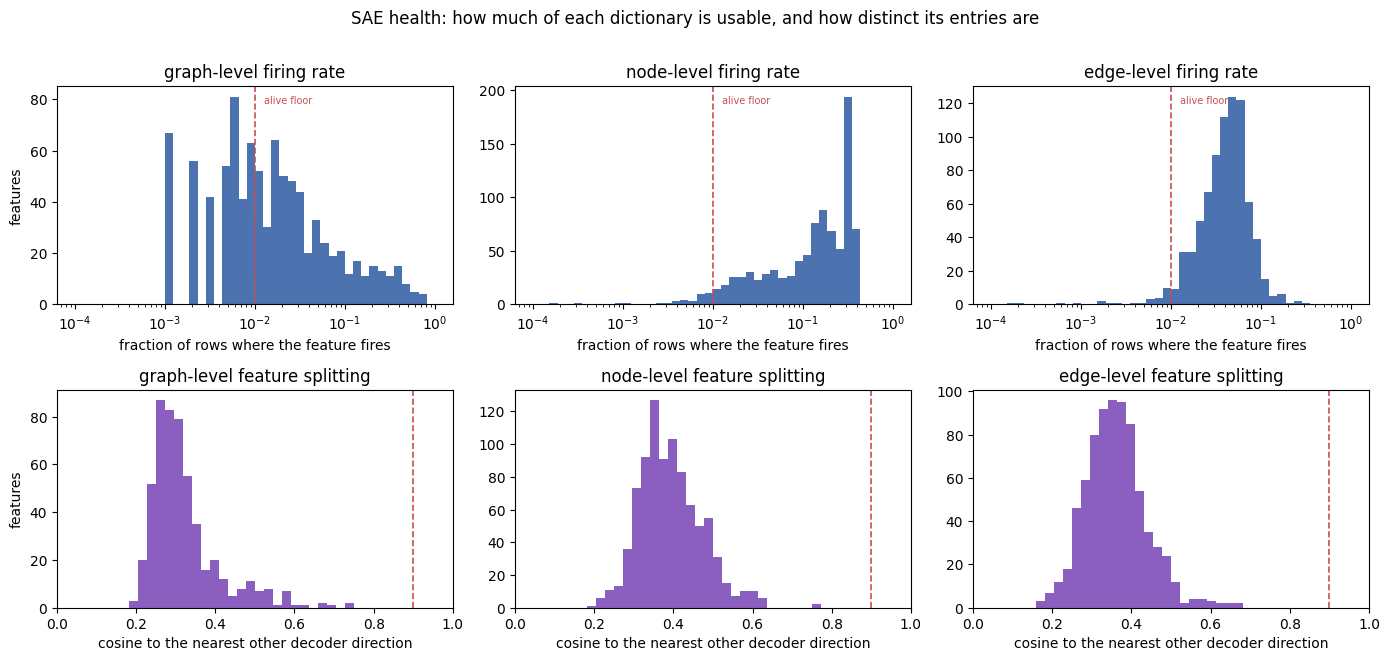

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from gea.gea import ShallowSAE, set_seed

OUT_DIR = Path("data/mask-the-interactome")
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DIAG_MAX_ROWS = 400_000   # edge level has 5.8M rows; these are distributional statistics
ALIVE_FREQ = 0.01         # the same floor the concept annotator uses to call a feature alive


def sae_health(level, max_rows=DIAG_MAX_ROWS):
    """Dead features, code density, reconstruction fidelity and feature splitting, for one level."""
    export = np.load(EMBEDDINGS_DIR / f"mask_gnn_{level}.npz", allow_pickle=True)
    X = export["embeddings"]
    if len(X) > max_rows:
        idx = np.sort(np.random.default_rng(SEED).choice(len(X), max_rows, replace=False))
        X = X[idx]
    X = X.astype(np.float32)

    sae = ShallowSAE(in_dim=X.shape[1], latent_dim=1024)
    sae.load_state_dict(torch.load(EMBEDDINGS_DIR / f"sae_{level}.pt", map_location="cpu"))
    sae.to(device).eval()

    mu = torch.tensor(X.mean(axis=0), device=device)
    n_fire = torch.zeros(sae.latent_dim, device=device)
    sse = sst = l0 = 0.0
    with torch.no_grad():
        for start in range(0, len(X), 65_536):
            xb = torch.tensor(X[start:start + 65_536]).to(device)
            z, x_hat = sae(xb)
            n_fire += (z > 0).sum(0)
            l0 += (z > 0).sum(1).float().sum().item()
            sse += ((xb - x_hat) ** 2).sum().item()
            sst += ((xb - mu) ** 2).sum().item()

    freq = (n_fire / len(X)).cpu().numpy()

    # feature splitting: cosine between decoder directions, restricted to features that fire at all
    with torch.no_grad():
        W = torch.nn.functional.normalize(sae.W_dec.detach(), dim=1)
        cos = (W @ W.T).fill_diagonal_(-1.0)
        alive = torch.as_tensor(freq >= ALIVE_FREQ, device=device)
        nearest = cos[alive][:, alive].max(dim=1).values.cpu().numpy()

    summary = {
        "level": level, "rows": len(X),
        "dead": float((freq == 0).mean()),
        "alive": int((freq >= ALIVE_FREQ).sum()),
        "L0": l0 / len(X),
        "L0_pct": l0 / len(X) / sae.latent_dim,
        "median_rate": float(np.median(freq[freq >= ALIVE_FREQ])),
        "max_rate": float(freq.max()),
        "recon_r2": 1 - sse / sst,
        "twin_cos": float(np.median(nearest)),
        "twin_frac_0.9": float((nearest > 0.9).mean()),
    }
    return summary, freq, nearest


health, freqs, twins = {}, {}, {}
rows = []
for level in ["graph", "node", "edge"]:
    summary, freq, nearest = sae_health(level)
    rows.append(summary); freqs[level] = freq; twins[level] = nearest

health_table = pd.DataFrame(rows).set_index("level")
print(health_table.to_string(float_format=lambda v: f"{v:.3g}"))

fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
for col, level in enumerate(["graph", "node", "edge"]):
    ax = axes[0, col]
    f = freqs[level]
    ax.hist(np.clip(f, 1e-4, None), bins=np.logspace(-4, 0, 45), color="#4C72B0")
    ax.axvline(ALIVE_FREQ, color="#c44e52", lw=1.2, ls="--")
    ax.set(xscale="log", xlabel="fraction of rows where the feature fires",
           ylabel="features" if col == 0 else "", title=f"{level}-level firing rate")
    ax.text(ALIVE_FREQ * 1.25, ax.get_ylim()[1] * 0.92, "alive floor", fontsize=7, color="#c44e52")

    ax = axes[1, col]
    ax.hist(twins[level], bins=np.linspace(0, 1, 45), color="#8b5fbf")
    ax.axvline(0.9, color="#c44e52", lw=1.2, ls="--")
    ax.set(xlim=(0, 1), xlabel="cosine to the nearest other decoder direction",
           ylabel="features" if col == 0 else "", title=f"{level}-level feature splitting")
for ax in axes.ravel():
    ax.grid(False)
fig.suptitle("SAE health: how much of each dictionary is usable, and how distinct its entries are", y=1.01)
plt.tight_layout(); plt.show()

The node dictionary reconstructs almost perfectly (R² 0.99) and wastes few entries, but it fires
159 of its 1,024 features on a typical node — 15% of the dictionary, against 4.5% at the graph
level and 3.6% at the edge level. That is the least comfortable number in the table. A feature
that fires on 16% of all node instances has a wide, largely indiscriminate footprint, and "this
feature fires on these proteins" is then a weak constraint. It is also the direct reason the
concept scores further down need a null: a wide feature gets many chances to line up with *some*
term out of several thousand.

Feature splitting is not a problem anywhere. The median nearest-neighbour decoder cosine is
0.30–0.39 and no feature at any level exceeds 0.9, so the entries are genuinely distinct
directions rather than one concept smeared across several.

The edge dictionary is the weakest of the three — 22% dead, R² 0.85 — which is roughly what a
ratio embedding costs. Its rows vary over orders of magnitude in norm (the clamp in the
extraction bounds that, it does not remove it), and a fixed dictionary spends capacity on the
scale as well as on the direction.

### Graph-level SAE features

#### Feature activations across every disease

The graph-level SAE turns each disease's 128-dim representation $g_d$ into a sparse vector over a
1024-feature dictionary. Running it over all 920 diseases at once gives a graphs x features
activation matrix — the raw material for everything below.

A dictionary this size over 920 rows is mostly empty by design: the sparsity penalty leaves each
disease firing a few dozen features, and most of the dictionary never fires at all — at least not
across the whole atlas at once, which is the question the next section complicates.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from gea.gea import ShallowSAE, set_seed
from gea.analysis import plot_sae_feature_clustermap

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

graph_export = np.load(EMBEDDINGS_DIR / "mask_gnn_graph.npz", allow_pickle=True)
disease_names = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t").set_index("doid")["doid_name"]

graph_sae = ShallowSAE(in_dim=graph_export["embeddings"].shape[1], latent_dim=1024)
graph_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_graph.pt", map_location="cpu"))
graph_sae.to(device).eval()

with torch.no_grad():
    z, _ = graph_sae(torch.tensor(graph_export["embeddings"].astype(np.float32)).to(device))
z = z.cpu().numpy()

# `feature_*` column names are what gea.analysis's activation helpers expect
graph_acts = pd.DataFrame(z, columns=[f"feature_{i}" for i in range(z.shape[1])])
graph_acts["doid"] = graph_export["doid"]
graph_acts["doid_name"] = graph_acts["doid"].map(disease_names)
graph_acts["category"] = graph_export["category"]

firing = z > 0
category_labels = graph_acts["category"].to_numpy()
category_sizes = pd.Series(category_labels).value_counts()
categories_present = sorted(set(category_labels))

n_active = firing.sum(axis=1)
print(f"{z.shape[0]:,} disease graphs x {z.shape[1]:,} SAE features across {len(categories_present)} categories")
print(f"median {np.median(n_active):.0f} features active per disease "
      f"({np.median(n_active) / z.shape[1]:.1%} of the dictionary)")

920 disease graphs x 1,024 SAE features across 19 categories
median 43 features active per disease (4.2% of the dictionary)


#### Alive features, by category

So far "alive" would mean firing in at least some fraction of all 920 diseases pooled together.
That is the wrong denominator for anything category-specific. Cancer has 210 diseases, so a 5%
floor is 11 of them; genetic disease has 12, so 5% is under one — a single disease firing is
enough to look "alive" unless a *count* floor is added alongside the rate. And a feature that is a
clean signature of a 30-disease category can sit under a pooled 5% floor forever: 5% of 920 is 46
diseases, and most categories cannot reach that alone no matter how strongly a feature encodes
them.

The fix used for the rest of this section: compute aliveness **inside each category** — rate >=
`ALIVE_MIN_RATE` *and* count >= `ALIVE_MIN_DISEASES`, so one lucky disease in a small category
doesn't count — then take the union across categories. A feature only needs to matter to *one*
category to survive here.

187/1024 features clear the 5% floor pooled across all 920 diseases
538 clear it inside at least one category — 351 of those are invisible in the pooled view

                  n_diseases  n_alive  pct_alive
category                                        
cancer                   210      152   0.148438
nervous                  124      194   0.189453
musculoskeletal           64      204   0.199219
cardiovascular            60      212   0.207031
metabolic                 53      244   0.238281
immune                    49      164   0.160156
gastrointestinal          46      166   0.162109
mental                    43      162   0.158203
infectious                39      141   0.137695
hematopoietic             34      155   0.151367
syndrome                  33      270   0.263672
respiratory               33      134   0.130859
urinary                   31      129   0.125977
endocrine                 27      132   0.128906
integumentary             21      118   0.115234
reproduc

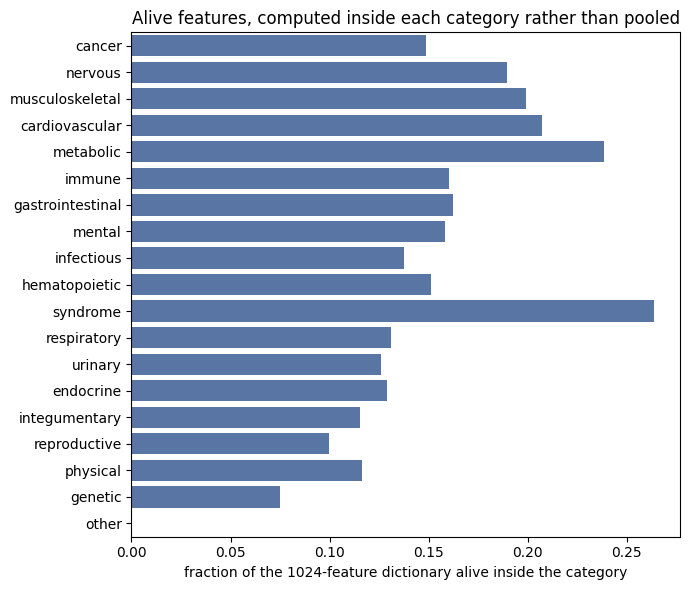

In [3]:
ALIVE_MIN_RATE = 0.05      # fires in at least this fraction of a category's diseases...
ALIVE_MIN_DISEASES = 3    # ...and in at least this many of them

alive_by_category = {
    c: set(np.flatnonzero(
        (firing[category_labels == c].mean(axis=0) >= ALIVE_MIN_RATE)
        & (firing[category_labels == c].sum(axis=0) >= ALIVE_MIN_DISEASES)
    ))
    for c in categories_present
}
alive_atlas = set(np.flatnonzero(firing.mean(axis=0) >= ALIVE_MIN_RATE))
alive_union = set().union(*alive_by_category.values())
hidden_atlas_wide = alive_union - alive_atlas

alive_summary = pd.DataFrame({
    "n_diseases": category_sizes,
    "n_alive": pd.Series({c: len(v) for c, v in alive_by_category.items()}),
}).sort_values("n_diseases", ascending=False)
alive_summary["pct_alive"] = alive_summary["n_alive"] / z.shape[1]
alive_summary.index.name = "category"

print(f"{len(alive_atlas)}/{z.shape[1]} features clear the {ALIVE_MIN_RATE:.0%} floor pooled across "
      f"all {len(graph_acts)} diseases")
print(f"{len(alive_union)} clear it inside at least one category — "
      f"{len(hidden_atlas_wide)} of those are invisible in the pooled view\n")
print(alive_summary.to_string())

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=alive_summary.reset_index(), y="category", x="pct_alive",
            order=alive_summary.index, color="#4C72B0", ax=ax)
ax.set(xlabel="fraction of the 1024-feature dictionary alive inside the category", ylabel="",
       title="Alive features, computed inside each category rather than pooled")
plt.tight_layout(); plt.show()

#### The clustered heatmap

`gea.analysis.plot_sae_feature_clustermap` draws features on the x-axis, diseases on the y-axis,
both hierarchically clustered, with a categorical strip down the left. The columns shown are the
per-category-alive union from above — not a flat pooled cut, for the reason just laid out — and
three of the function's own settings matter here too.

**Scaling.** Each surviving feature column is min-max scaled before clustering (`scale="feature"`).
SAE activation magnitudes differ by an order of magnitude between features, so on a raw scale two
loud features would saturate the ramp and everything else would read as empty. The question here
is *which diseases* fire a feature, not how loudly.

**Linkage.** `method="ward"` rather than the function's default average linkage. On sparse
activation vectors average linkage chains badly — cutting that tree into 19 groups gives one
cluster of 898 diseases and 18 singletons, which is not a clustering of anything. Ward minimises
within-cluster variance at each merge and gives groups that are actually comparable in size.

Nineteen categories is more than any colour strip can carry on hue alone, so the contiguous blocks
of clustered rows are labelled in text on the right edge as well (`label_blocks`), and the strip is
a plain reading aid rather than the evidence.

Alive: 538/538 features (0 dead or constant, dropped)


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


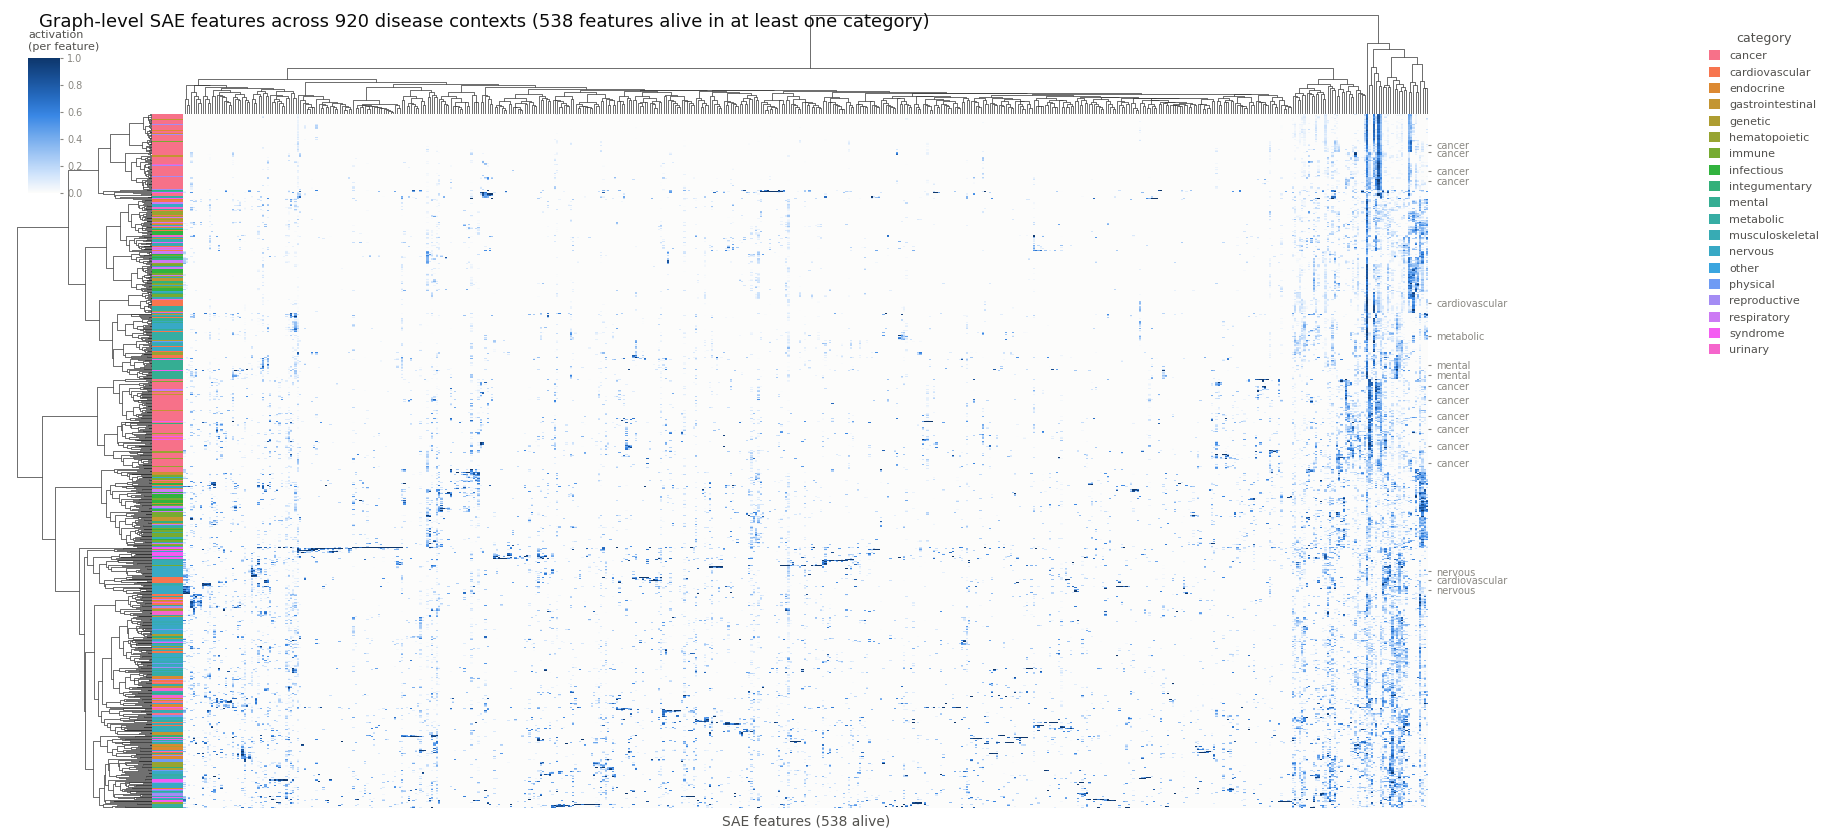

In [4]:
CATEGORY_ORDER = sorted(graph_acts["category"].unique())

# husl wraps around the hue circle, so ask for one colour more than needed and drop it — otherwise
# the first and last category (cancer and urinary here) land on nearly the same pink
category_palette = {
    "category": dict(zip(
        CATEGORY_ORDER,
        sns.color_palette("husl", len(CATEGORY_ORDER) + 1).as_hex()[:len(CATEGORY_ORDER)],
    ))
}

heatmap_cols = [f"feature_{i}" for i in sorted(alive_union)]
heatmap_df = graph_acts[heatmap_cols + ["doid", "doid_name", "category"]]

clustergrid, _ = plot_sae_feature_clustermap(
    heatmap_df,
    annotate=("category",),
    min_activation_frac=0.0,  # aliveness was already decided per category above
    scale="feature",
    method="ward",
    palettes=category_palette,
    label_blocks="category",
    min_block=8,
    title=f"Graph-level SAE features across {len(graph_acts):,} disease contexts "
          f"({len(heatmap_cols)} features alive in at least one category)",
)
plt.show()

#### Do the clusters agree with disease category?

A heatmap with a coloured strip next to it will look meaningful whether or not it is, so the
agreement is worth measuring rather than eyeballing. The row dendrogram drawn above is cut into
`N_CLUSTERS` groups — the same linkage, so this is the picture and not a second clustering — and
scored two ways:

- **Adjusted Rand index** between the cut and the disease categories, against a null built by
  shuffling the category labels. ARI is a strict, global measure: with 19 unbalanced categories it
  stays low even when real structure is present, so read it against its own null rather than
  against 1.
- **Per-cluster enrichment**: the most common category in each cluster, and a hypergeometric test
  asking whether that category is over-represented relative to its share of all 920 diseases
  (BH-corrected across clusters). This is the more informative of the two, because it says *which*
  categories the features organise around instead of collapsing everything into one number.

Nothing in the training touched disease category — not the GNN's objectives, not the SAE's — so any
agreement here is emergent from gene identity plus interactome topology, not something either model
was asked for.

In [5]:
from scipy.cluster.hierarchy import fcluster
from scipy.stats import hypergeom
from sklearn.metrics import adjusted_rand_score
from statsmodels.stats.multitest import multipletests

N_CLUSTERS = 12
N_PERMUTATIONS = 1000


def cluster_label_agreement(acts_df, row_linkage, label_col, n_clusters,
                            n_permutations=N_PERMUTATIONS, seed=SEED):
    """Cut a drawn row dendrogram and ask how far its clusters agree with a known labelling."""
    cluster = fcluster(row_linkage, n_clusters, criterion="maxclust")
    labels = acts_df[label_col].to_numpy()

    ari = adjusted_rand_score(labels, cluster)
    rng = np.random.default_rng(seed)
    null = np.array([adjusted_rand_score(rng.permutation(labels), cluster)
                     for _ in range(n_permutations)])
    p_value = (np.sum(null >= ari) + 1) / (n_permutations + 1)
    print(f"ARI(clusters, {label_col}) = {ari:.3f} | shuffled-label null "
          f"{null.mean():+.4f} +/- {null.std():.4f} | p = {p_value:.4f}")

    rows = []
    for c in np.unique(cluster):
        members = cluster == c
        counts = pd.Series(labels[members]).value_counts()
        top_label, n_top = counts.index[0], int(counts.iloc[0])
        rows.append({
            "cluster": int(c),
            "n_graphs": int(members.sum()),
            f"top_{label_col}": top_label,
            "n_top": n_top,
            "purity": n_top / members.sum(),
            # over-represented versus that label's share of the whole subset?
            "p": hypergeom.sf(n_top - 1, len(labels), int((labels == top_label).sum()),
                              int(members.sum())),
        })

    table = pd.DataFrame(rows)
    table["fdr"] = multipletests(table["p"], method="fdr_bh")[1]
    table = table.sort_values("fdr").reset_index(drop=True)

    print(f"\n{(table['fdr'] < 0.05).sum()}/{len(table)} clusters are enriched for a "
          f"{label_col} at FDR < 0.05\n")
    print(table.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    return cluster, table


# clustergrid.dendrogram_row.linkage is the tree drawn above, not a new one
cluster, cluster_table = cluster_label_agreement(
    graph_acts, clustergrid.dendrogram_row.linkage, "category", N_CLUSTERS,
)

ARI(clusters, category) = 0.205 | shuffled-label null -0.0001 +/- 0.0027 | p = 0.0010

12/12 clusters are enriched for a category at FDR < 0.05

 cluster  n_graphs top_category  n_top  purity        p      fdr
       4       119       cancer    103   0.866 4.99e-59 5.99e-58
       1       113       cancer     87    0.77 3.34e-40    2e-39
       3       115       mental     31    0.27  9.4e-21 3.76e-20
       5       104       immune     30   0.288 2.31e-18 6.93e-18
       2       123  respiratory     21   0.171 8.16e-12 1.96e-11
      10        31    endocrine     11   0.355 8.43e-11 1.69e-10
       8        46      nervous     24   0.522 1.03e-10 1.76e-10
       7         9     syndrome      6   0.667 1.04e-07 1.56e-07
       6         6     syndrome      4   0.667 1.97e-05 2.62e-05
       9       187      nervous     40   0.214 0.000509 0.000611
      12         1     syndrome      1       1   0.0359   0.0391
      11        66      nervous     14   0.212   0.0481   0.0481


#### Category-specific features, category vs category

One-vs-rest pools every other category into a single background, and that background is dominated
by whichever categories happen to be biggest. A feature that fires in a third of the 49 immune
diseases barely nudges a background built from the other 871 diseases, so it can look
"cancer-specific" by pure dilution even though immune disease is the real story. The question
"specific to cancer" should be answered against *each* other category on its own footing, not
against their average.

So for every feature we read its firing rate **inside every category directly** — a
(feature x category) rate table, no pooling anywhere — and keep two numbers per feature: its
**best** category (highest rate) and its **runner-up**, the single other category (restricted to
categories with at least `RUNNER_MIN_DISEASES` diseases, otherwise a rate over a handful of them is
too noisy to be a fair competitor) where it fires next hardest. `margin` is the ratio of the two.

A feature counts as **specific** to its best category when that rate clears an absolute floor
(`SPECIFIC_MIN_DISEASES` diseases, `SPECIFIC_MIN_RATE` of them — a rate built from two diseases in a
12-disease category means nothing) and beats the runner-up by `SPECIFIC_MIN_MARGIN`x. Those floors
do most of the selecting, the same way they did for aliveness above; a one-sided Fisher exact test
against that same runner-up (not the pooled rest, this time) is reported alongside as a calibration
check, BH-corrected over every candidate that clears the floor — useful for judging *which*
specific features are well-powered rather than as a second gate, since at a few dozen diseases per
category most margins that look real do not also clear a corrected p-value.

The other interesting group is features that **don't** pick a side: best and runner-up rates close
together (`margin` below `SHARED_MARGIN_MAX`), both past the floor. These fire on two categories
about equally often — worth naming, not discarding as noise in either direction.

In [6]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

SPECIFIC_MIN_DISEASES = 5      # fires in at least this many diseases of its best category
SPECIFIC_MIN_RATE = 0.05       # ... and in at least this fraction of them
SPECIFIC_MIN_MARGIN = 1.5      # ... at least this many times its rate in the runner-up category
RUNNER_MIN_DISEASES = 10       # a category smaller than this is too noisy to count as a runner-up
SHARED_MARGIN_MAX = 1.3        # margin below this: no clear winner, call it shared instead
SPECIFIC_FDR = 0.05

comparable = [c for c in categories_present if category_sizes[c] >= RUNNER_MIN_DISEASES]
cat_index = {c: i for i, c in enumerate(categories_present)}
comparable_idx = np.array([cat_index[c] for c in comparable])

rate_by_cat = np.stack([firing[category_labels == c].mean(axis=0) for c in categories_present], axis=1)
count_by_cat = np.stack([firing[category_labels == c].sum(axis=0) for c in categories_present], axis=1)
n_features = z.shape[1]
rows = np.arange(n_features)

best_idx = rate_by_cat.argmax(axis=1)
best_cat = np.array(categories_present)[best_idx]
best_rate, best_count = rate_by_cat[rows, best_idx], count_by_cat[rows, best_idx]

# runner-up: best rate among *comparable* categories other than the winner itself
comparable_mask = np.zeros(len(categories_present), dtype=bool)
comparable_mask[comparable_idx] = True
runner_pool = np.where(comparable_mask[None, :], rate_by_cat, -1.0)
runner_pool[rows, best_idx] = -1.0
runner_idx = runner_pool.argmax(axis=1)
no_runner = runner_pool[rows, runner_idx] < 0  # no other comparable category exists at all
runner_cat = np.array(categories_present)[runner_idx]
runner_rate = np.clip(runner_pool[rows, runner_idx], 0, None)
runner_count = count_by_cat[rows, runner_idx]
margin = np.where(no_runner, np.inf, best_rate / np.maximum(runner_rate, 1e-9))

clears_floor = (best_count >= SPECIFIC_MIN_DISEASES) & (best_rate >= SPECIFIC_MIN_RATE)
candidates = np.flatnonzero(clears_floor)

pvals = np.ones(n_features)
for j in candidates:
    if no_runner[j]:
        pvals[j] = 0.0
        continue
    n_best, n_run = int(category_sizes[best_cat[j]]), int(category_sizes[runner_cat[j]])
    k_best, k_run = int(best_count[j]), int(runner_count[j])
    _, pvals[j] = fisher_exact([[k_best, n_best - k_best], [k_run, n_run - k_run]], alternative="greater")

fdr = np.ones(n_features)
fdr[candidates] = multipletests(pvals[candidates], method="fdr_bh")[1]

specificity = pd.DataFrame({
    "feature": rows, "category": best_cat, "n_diseases": best_count.astype(int), "rate_in": best_rate,
    "runner_up": runner_cat, "runner_rate": runner_rate, "margin": margin, "p": pvals, "fdr": fdr,
}).loc[candidates].reset_index(drop=True)
specificity["specific"] = specificity["margin"] >= SPECIFIC_MIN_MARGIN

runner_clears_floor = (runner_count >= SPECIFIC_MIN_DISEASES) & (runner_rate >= SPECIFIC_MIN_RATE)
shared_mask = clears_floor & runner_clears_floor & ~no_runner & (margin < SHARED_MARGIN_MAX)
shared = pd.DataFrame({
    "feature": rows[shared_mask], "category_a": best_cat[shared_mask], "rate_a": best_rate[shared_mask],
    "category_b": runner_cat[shared_mask], "rate_b": runner_rate[shared_mask],
}).sort_values("rate_a", ascending=False).reset_index(drop=True)

print(f"{len(candidates)}/{n_features} features clear the per-category floor\n")
print(f"{specificity['specific'].sum()} are specific to a single category (margin >= "
      f"{SPECIFIC_MIN_MARGIN}x); {(specificity['specific'] & (specificity['fdr'] < SPECIFIC_FDR)).sum()} "
      f"of those also survive FDR < {SPECIFIC_FDR} against their runner-up\n")
print(specificity[specificity["specific"]]["category"].value_counts().to_string())
print(f"\n{len(shared)} features fire comparably (margin < {SHARED_MARGIN_MAX}x) in two categories at once")

255/1024 features clear the per-category floor

95 are specific to a single category (margin >= 1.5x); 1 of those also survive FDR < 0.05 against their runner-up

category
syndrome            14
integumentary       10
musculoskeletal      8
endocrine            8
cancer               6
physical             6
mental               6
immune               6
hematopoietic        5
metabolic            5
genetic              4
urinary              4
nervous              3
cardiovascular       3
infectious           3
respiratory          2
gastrointestinal     1
reproductive         1

77 features fire comparably (margin < 1.3x) in two categories at once


#### Cancer under the stricter bar

Cancer is the largest category (210 of 920 diseases) and the one that carved out its own block in
the heatmap above, so it is the natural place to see what the honest pairwise comparison changes
relative to one-vs-rest. Pooled one-vs-rest would call a feature cancer-specific once it clears a
fixed enrichment ratio against the *average* of the other 710 diseases — a bar that gets easier to
clear the bigger cancer already is, since cancer's own rate dominates less and less of what's left
in that average. Checked instead against cancer's actual best competitor, feature by feature, most
of that list does not hold up.

In [7]:
cancer_candidates = specificity[specificity["category"] == "cancer"]
cancer_specific = (cancer_candidates[cancer_candidates["specific"]]
                   .sort_values("rate_in", ascending=False).reset_index(drop=True))

print(f"{len(cancer_candidates)} features clear the floor inside cancer | "
      f"{len(cancer_specific)} of those beat their runner-up by {SPECIFIC_MIN_MARGIN}x or more\n")
print(cancer_specific[["feature", "n_diseases", "rate_in", "runner_up", "runner_rate", "margin", "fdr"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3g}"))

19 features clear the floor inside cancer | 6 of those beat their runner-up by 1.5x or more

 feature  n_diseases  rate_in        runner_up  runner_rate  margin   fdr
     291         116    0.552           immune        0.347    1.59 0.164
     667          66    0.314          urinary        0.161    1.95 0.431
     403          47    0.224         syndrome       0.0909    2.46 0.431
    1002          35    0.167          urinary       0.0968    1.72  0.64
     281          24    0.114 gastrointestinal       0.0435    2.63 0.516
      17          19   0.0905 gastrointestinal       0.0217    4.16 0.487


#### How specific is specific?

`margin` is a ratio, which flatters a feature firing in 9% of cancers and 2% of its nearest
competitor the same way it flatters one firing in 55% and 35%. Drawing the two rates that actually
decide the question on one axis — the cancers, and the single other category that fires the
feature most — says how much of each a feature really covers, and makes the honest reading of a
large margin visible: usually a feature that fires on a *subset* of cancers rather than on cancer
as such.

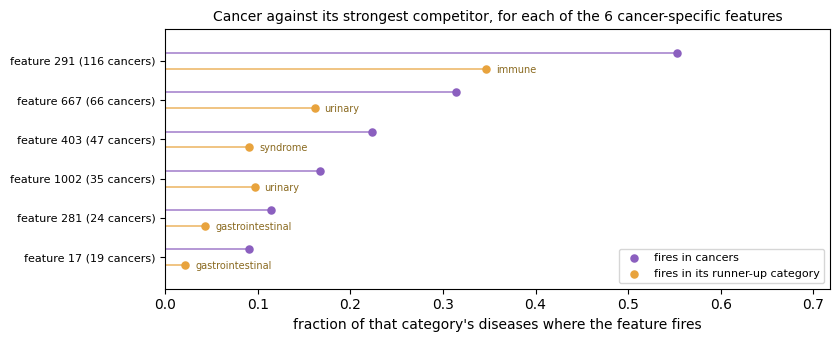

median coverage of the cancers: 19.5% | median margin over the runner-up: 2.21x


In [8]:
tbl = cancer_specific.sort_values("rate_in").reset_index(drop=True)
y = np.arange(len(tbl), dtype=float)
offset = 0.2

fig, ax = plt.subplots(figsize=(8.5, 0.32 * len(tbl) + 1.6))
ax.hlines(y + offset, 0, tbl["rate_in"], color="#8b5fbf", lw=1.2, alpha=0.75, zorder=1)
ax.hlines(y - offset, 0, tbl["runner_rate"], color="#e8a33d", lw=1.2, alpha=0.75, zorder=1)
ax.scatter(tbl["rate_in"], y + offset, s=26, color="#8b5fbf", zorder=3, label="fires in cancers")
ax.scatter(tbl["runner_rate"], y - offset, s=26, color="#e8a33d", zorder=3,
           label="fires in its runner-up category")

for yi, (runner, rate) in enumerate(zip(tbl["runner_up"], tbl["runner_rate"])):
    ax.annotate(runner, (rate, yi - offset), textcoords="offset points", xytext=(7, -3),
                fontsize=7, color="#8a6a20")

ax.set_yticks(y)
ax.set_yticklabels([f"feature {f} ({n} cancers)" for f, n in zip(tbl["feature"], tbl["n_diseases"])],
                   fontsize=8)
ax.set_ylim(-0.8, len(tbl) - 0.2)
ax.set_xlabel("fraction of that category's diseases where the feature fires")
ax.set_xlim(0, max(tbl["rate_in"].max(), tbl["runner_rate"].max()) * 1.3)
ax.legend(loc="lower right", fontsize=8, frameon=True)
ax.grid(False)
ax.set_title(f"Cancer against its strongest competitor, for each of the {len(tbl)} cancer-specific features",
             fontsize=10)
plt.tight_layout(); plt.show()

print(f"median coverage of the cancers: {tbl['rate_in'].median():.1%} | "
      f"median margin over the runner-up: {(tbl['rate_in'] / tbl['runner_rate']).median():.2f}x")

#### Features shared between two categories

Not every feature picks a side. `feature 291` above is the closest thing to that boundary among
the cancer-specific ones: it fires in 55% of cancers and, on its own, in 35% of immune diseases —
enough of a gap to count as cancer-specific by the margin rule, but not by a wide one. The table
below is the features that don't even clear that gap: `margin` under `SHARED_MARGIN_MAX`, both
categories past the floor. `feature 246` is the clearest example, split almost evenly between
immune and cancer — worth checking what it is actually responding to, which the next section does
directly.

In [9]:
print(f"{len(shared)} features fire comparably in two categories at once (margin < {SHARED_MARGIN_MAX}x)\n")
print(shared.head(12).to_string(index=False, float_format=lambda v: f"{v:.3g}"))

77 features fire comparably in two categories at once (margin < 1.3x)

 feature      category_a  rate_a  category_b  rate_b
     157         genetic       1    physical   0.944
     758      infectious       1 respiratory    0.97
     955         genetic       1      mental    0.93
     428         genetic       1    physical   0.889
     411         genetic       1    physical   0.944
     443          cancer   0.971    physical   0.889
     327      infectious   0.897 respiratory   0.818
     136 musculoskeletal   0.891 respiratory   0.788
      67          cancer   0.843  infectious   0.667
     949  cardiovascular   0.833  infectious   0.795
     377       endocrine   0.815      mental   0.744
     584   hematopoietic   0.794      immune   0.714


#### Which diseases drive a feature?

A rate says how often a feature fires inside a category; it does not say what the feature is
actually responding to. The direct answer is to rank that category's diseases by how hard the
feature fires and read off the top of the list — and, since the Disease Ontology is a hierarchy
and not just the 19 broad category labels used so far, to check whether those top diseases share a
**finer** ancestor term than the category itself.

The idea is the same as the node- and edge-level concept-scoring later in this notebook: a feature
"belongs" to a term when its activation predicts membership, scored by F1 at a few relative
thresholds. Here the "genes" are diseases and the "gene sets" are Disease Ontology ancestor terms —
and there is no per-graph loop to write, since a graph-level feature already has exactly one
activation per disease. Terms are kept if they cover between `TERM_MIN_DISEASES` and
`TERM_MAX_DISEASES` of the 920 diseases: rarer ones are trivially matched by almost any feature that
happens to fire on that handful, broader ones say nothing finer than the category root already
known.

In [10]:
class DiseaseOntology:
    """The is_a hierarchy of the Human Disease Ontology, read from the .obo release.

    Same parser as docs/scripts/build_disease_categories.py's, kept local so this section
    only needs the .obo file already downloaded to build the category labels.
    """
    def __init__(self, path):
        self.parents, self.names = {}, {}
        self._ancestors = {}
        term = None
        for line in Path(path).read_text().splitlines():
            if line.startswith("["):
                if term and term["id"]:
                    self.parents[term["id"]] = term["is_a"]
                    self.names[term["id"]] = term["name"]
                term = {"id": None, "name": None, "is_a": []} if line == "[Term]" else None
            elif term is not None and line:
                if line.startswith("id: "):
                    term["id"] = line[4:].strip()
                elif line.startswith("name: "):
                    term["name"] = line[6:].strip()
                elif line.startswith("is_a: "):
                    term["is_a"].append(line[6:].split("!")[0].strip())
        if term and term["id"]:
            self.parents[term["id"]] = term["is_a"]
            self.names[term["id"]] = term["name"]

    def ancestors(self, doid):
        if doid not in self._ancestors:
            seen, stack = set(), list(self.parents.get(doid, ()))
            while stack:  # DO is a DAG, so this is not a walk up a single chain
                parent = stack.pop()
                if parent not in seen:
                    seen.add(parent)
                    stack.extend(self.parents.get(parent, ()))
            self._ancestors[doid] = seen
        return self._ancestors[doid]


TERM_MIN_DISEASES, TERM_MAX_DISEASES = 5, 200

do = DiseaseOntology(DATA_DIR / "HumanDO.obo")
doids = graph_acts["doid"].tolist()

term_membership = {}
for doid in doids:
    for t in do.ancestors(doid) | {doid}:
        term_membership.setdefault(t, set()).add(doid)

kept_terms = {t: members for t, members in term_membership.items()
              if TERM_MIN_DISEASES <= len(members) <= TERM_MAX_DISEASES}
term_names = [do.names.get(t, t) for t in sorted(kept_terms)]
term_table = pd.DataFrame(0.0, index=doids, columns=term_names)
for term_id, name in zip(sorted(kept_terms), term_names):
    term_table.loc[list(kept_terms[term_id]), name] = 1.0

print(f"{len(kept_terms):,}/{len(term_membership):,} DO terms kept "
      f"(cover {TERM_MIN_DISEASES}-{TERM_MAX_DISEASES} of the {len(doids)} diseases)")

145/974 DO terms kept (cover 5-200 of the 920 diseases)


#### Ranked diseases and their Disease Ontology concept

Applied to the top of the cancer-specific list, then to `feature 246` from the shared table above.

In [11]:
def rank_diseases_for_feature(feature, mask, top_n=8):
    sub = graph_acts.loc[mask, ["doid", "doid_name"]].copy()
    sub["activation"] = z[mask, feature]
    return sub.sort_values("activation", ascending=False).head(top_n)


def annotate_graph_feature(feature, mask, thresholds=(0.15, 0.3, 0.5), min_active=3, top_k=3):
    """Best-matching Disease Ontology term(s) for one feature, scored over the diseases in `mask`."""
    col = z[mask, feature]
    peak = col.max()
    if peak <= 0:
        return []
    relative = col / peak
    terms = term_table.loc[graph_acts.loc[mask, "doid"]].to_numpy()
    best_f1 = None
    for t in thresholds:
        acts = (relative > t).astype(np.float32)
        if acts.sum() < min_active:
            continue
        tp = acts @ terms
        f1 = 2 * tp / (acts.sum() + terms.sum(axis=0) + 1e-8)
        best_f1 = f1 if best_f1 is None else np.maximum(best_f1, f1)
    if best_f1 is None:
        return []
    top = np.argsort(best_f1)[::-1][:top_k]
    return [(term_table.columns[i], float(best_f1[i])) for i in top if best_f1[i] > 0]


for _, row in cancer_specific.head(5).iterrows():
    feature, mask = int(row["feature"]), category_labels == "cancer"
    print(f"\nfeature {feature} -- {row['rate_in']:.0%} of cancers, "
          f"runner-up {row['runner_up']} at {row['runner_rate']:.0%}")
    print(rank_diseases_for_feature(feature, mask).to_string(index=False))
    print("Disease Ontology concept:", annotate_graph_feature(feature, mask))


feature 291 -- 55% of cancers, runner-up immune at 35%
     doid                   doid_name  activation
DOID:1107        Esophageal carcinoma    1.736157
DOID:4007           Bladder carcinoma    1.475472
DOID:3121          Gallbladder cancer    1.455580
DOID:2893            Cervix carcinoma    1.390089
DOID:2671 Transitional cell carcinoma    1.321490
DOID:8649               Tongue cancer    1.177805
 DOID:234        Colon adenocarcinoma    1.102690
DOID:3717      Gastric adenocarcinoma    1.098965
Disease Ontology concept: [('organ system cancer', 0.5333333333111111), ('cancer', 0.5287356321636499), ('gastrointestinal system cancer', 0.39473684205332416)]

feature 667 -- 31% of cancers, runner-up urinary at 16%
        doid                            doid_name  activation
DOID:0060121 Integumentary system benign neoplasm    0.340091
   DOID:2513                 Basal cell carcinoma    0.330217
   DOID:3451                       Skin carcinoma    0.303916
DOID:0050861            Colo

In [12]:
feature, mask = 246, np.isin(category_labels, ["immune", "cancer"])
print(f"feature {feature} -- shared between immune and cancer\n")
print(rank_diseases_for_feature(feature, mask).to_string(index=False))
print("\nDisease Ontology concept:", annotate_graph_feature(feature, mask))

feature 246 -- shared between immune and cancer

        doid                        doid_name  activation
  DOID:12177 Common variable immunodeficiency    1.540697
   DOID:2583               Agammaglobulinemia    1.356753
DOID:0050685             Small cell carcinoma    1.150686
DOID:0050744   Anaplastic large cell lymphoma    1.092238
   DOID:2115                B cell deficiency    1.039464
DOID:0050748           Marginal zone lymphoma    1.003979
DOID:0050746             Mantle cell lymphoma    0.939706
   DOID:2959     Hyperimmunoglobulin syndrome    0.920217

Disease Ontology concept: [('hematologic cancer', 0.4301075268354723), ('B-cell lymphoma', 0.3888888887808642), ('non-Hodgkin lymphoma', 0.37209302316928067)]


#### Held-out diseases, and a null for the term search

The concepts above were picked on all 920 diseases and reported as they came, which asks for the
two things the node- and edge-level sections already do.

First a **split**: pick each feature's Disease Ontology term on the 736 training diseases only,
then re-score that same term on the 184 the GNN never saw. Second a **null**: 145 candidate terms
is a small search, but a feature firing on a dozen diseases still has many ways of landing on a
term of roughly that size by luck, so every feature is also scored against 200 shuffles of the
disease-to-term membership. The honest effect size is the gap between the two, not the raw F1.

One caveat this cannot fix. The graph-level SAE trained on all 920 diseases, where the node- and
edge-level ones were restricted to `train_doids`, so the *dictionary* has seen the held-out
diseases even though the *term selection* has not. Passing `doid_subset=train_doids` when
training the graph SAE closes that gap as well; it also renumbers every feature this section
names by hand, which is why it is left as a switch rather than the default.

In [13]:
from statsmodels.stats.multitest import multipletests

GRAPH_N_PERMUTATIONS = 200

gnn_ckpt = torch.load(OUT_DIR / "mask_gnn.pt", map_location="cpu", weights_only=False)
train_doids, val_doids = gnn_ckpt["train_doids"], gnn_ckpt["val_doids"]
is_train = np.isin(graph_acts["doid"].to_numpy(), train_doids)

alive_features = np.array(sorted(alive_union))
term_arr = term_table.to_numpy().astype(np.float32)
term_cols = np.asarray(term_table.columns)


def graph_f1_matrix(mask, terms, thresholds=(0.15, 0.3, 0.5), min_active=3):
    """[alive features x DO terms] best-F1 table over the diseases in `mask`.

    Same scoring rule as `annotate_graph_feature`, just written for every feature and every term
    at once so it can be repeated a few hundred times under permuted term memberships.
    """
    acts_raw = z[np.ix_(mask, alive_features)]
    peak = acts_raw.max(axis=0, keepdims=True)
    relative = np.divide(acts_raw, peak, out=np.zeros_like(acts_raw), where=peak > 0)
    sub = terms[mask]
    n_term = sub.sum(axis=0)
    best = np.zeros((len(alive_features), terms.shape[1]), dtype=np.float32)
    for t in thresholds:
        fired = (relative > t).astype(np.float32)
        n_active = fired.sum(axis=0)
        f1 = 2 * (fired.T @ sub) / (n_active[:, None] + n_term[None, :] + 1e-8)
        f1[n_active < min_active] = 0.0
        best = np.maximum(best, f1)
    return best


f1_train = graph_f1_matrix(is_train, term_arr)
f1_test = graph_f1_matrix(~is_train, term_arr)
pick = f1_train.argmax(axis=1)
rows = np.arange(len(alive_features))

rng = np.random.default_rng(SEED)
null_peak = np.stack([graph_f1_matrix(is_train, term_arr[rng.permutation(len(term_arr))]).max(axis=1)
                      for _ in range(GRAPH_N_PERMUTATIONS)], axis=1)

graph_concepts = pd.DataFrame({
    "feature": alive_features,
    "term": term_cols[pick],
    "f1_train": f1_train[rows, pick],
    "f1_test": f1_test[rows, pick],
    "f1_null": np.median(null_peak, axis=1),
    "p": (np.sum(null_peak >= f1_train[rows, pick][:, None], axis=1) + 1) / (GRAPH_N_PERMUTATIONS + 1),
})
graph_concepts = graph_concepts[graph_concepts["f1_train"] > 0].copy()
graph_concepts["fdr"] = multipletests(graph_concepts["p"], method="fdr_bh")[1]
graph_concepts["excess"] = graph_concepts["f1_train"] - graph_concepts["f1_null"]
graph_concepts = graph_concepts.sort_values("excess", ascending=False).reset_index(drop=True)

survived = graph_concepts["f1_test"] > 0
print(f"{len(graph_concepts)} alive graph features carry a Disease Ontology concept, picked on the "
      f"{is_train.sum()} training diseases only")
print(f"  {survived.sum()} of them still score above zero for the same term on the "
      f"{(~is_train).sum()} held-out diseases")
print(f"  median F1 {graph_concepts['f1_train'].median():.3f} | shuffled-membership null "
      f"{graph_concepts['f1_null'].median():.3f} | median excess {graph_concepts['excess'].median():+.3f}")
print(f"  {(graph_concepts['fdr'] < 0.05).sum()} beat their own null at FDR < 0.05\n")
print(graph_concepts.head(12).to_string(index=False, float_format=lambda v: f"{v:.3g}"))

524 alive graph features carry a Disease Ontology concept, picked on the 736 training diseases only
  171 of them still score above zero for the same term on the 184 held-out diseases
  median F1 0.286 | shuffled-membership null 0.222 | median excess +0.082
  164 beat their own null at FDR < 0.05

 feature                     term  f1_train  f1_test  f1_null       p    fdr  excess
     967          aplastic anemia     0.909        0    0.222 0.00498 0.0223   0.687
     366               dysostosis     0.833        0    0.222 0.00498 0.0223   0.611
     425 electroclinical syndrome     0.769    0.667    0.176 0.00498 0.0223   0.593
     117  pituitary gland disease      0.75        0     0.25 0.00498 0.0223     0.5
     151  pituitary gland disease      0.75        0     0.25 0.00498 0.0223     0.5
     550         male infertility     0.667        0    0.182 0.00498 0.0223   0.485
     337 electroclinical syndrome     0.667        0    0.182 0.00498 0.0223   0.485
     896             

A shuffled Disease Ontology already reaches a median F1 of 0.22 for a typical feature, against
0.29 for the real one — so most of the raw score is the search, not the biology, and only 164 of
524 features clear their own null at FDR < 5%. The features at the top of the table clear it by
0.4–0.7 and are the ones worth reading.

Survival to the held-out diseases is weaker: 171 of 524 still score above zero there. Much of
that is the size of the held-out set rather than a failure of the features — a term covering five
diseases atlas-wide will often have none at all among the 184 held out, leaving the feature
nothing to recover. `feature 67` and `feature 443` are the informative case: both keep
essentially their full training F1 (0.72 and 0.71 against 0.69 and 0.72) on diseases they were
never chosen from, and both land on *cancer*, the one category this section has already shown
carves out its own block of the heatmap.

### Assigning concepts to node- and edge-level SAE features

A feature is only interesting once we know what it responds to. This reuses the trained node- and edge-level SAEs plus the GNN's own train/val disease split (saved inside `mask_gnn.pt`) — the diseases the GNN never trained on double as the diseases held out from concept selection here, so a feature's assigned concept has to survive on genuinely unseen diseases, not just the ones it was picked from.

#### Setup

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from gea.gea import ShallowSAE, set_seed
from gea_gene_nets.annotation_funcs import fetch_gene_sets, geneSetAnnotation, gene_set_matrix, feature_maxima

DATA_DIR = Path("data/diseases")
STRING_DIR = DATA_DIR / "string"
OUT_DIR = Path("data/mask-the-interactome")
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
node_export = np.load(EMBEDDINGS_DIR / "mask_gnn_node.npz", allow_pickle=True)
edge_export = np.load(EMBEDDINGS_DIR / "mask_gnn_edge.npz", allow_pickle=True)

gnn_ckpt = torch.load(OUT_DIR / "mask_gnn.pt", map_location="cpu", weights_only=False)
train_doids, val_doids = gnn_ckpt["train_doids"], gnn_ckpt["val_doids"]

node_sae = ShallowSAE(in_dim=128, latent_dim=1024)
node_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_node.pt", map_location="cpu"))
node_sae.to(device).eval()

edge_sae = ShallowSAE(in_dim=128, latent_dim=1024)
edge_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_edge.pt", map_location="cpu"))
edge_sae.to(device).eval()

print(f"device: {device}")
print(f"{len(train_doids):,} train diseases | {len(val_doids):,} held-out diseases")

device: cuda
736 train diseases | 184 held-out diseases


#### The concept dictionary

A concept here is a **gene set** — a KEGG pathway, a Reactome pathway, or a GO Biological Process term — downloaded from Enrichr. Bridging our STRING/Ensembl protein ids to the gene symbols Enrichr indexes by now needs STRING's own alias file rather than `diseases_filtered.tsv`: the node universe includes the local background proteins, and the DISEASES table only ever knew about disease genes. Terms are kept between 8 and 300 genes: smaller ones are trivially matched by almost any narrow feature, larger ones are too broad to name a specific mechanism.

In [15]:
import urllib.request

GENE_SET_LIBRARIES = ["KEGG_2021_Human", "Reactome_2022", "GO_Biological_Process_2023"]
TERM_MIN_GENES, TERM_MAX_GENES = 8, 300

ALIAS_URL = "https://stringdb-downloads.org/download/protein.aliases.v12.0/9606.protein.aliases.v12.0.txt.gz"
alias_file = STRING_DIR / "9606.protein.aliases.v12.0.txt.gz"
if not alias_file.exists():
    print(f"downloading {ALIAS_URL}")
    urllib.request.urlretrieve(ALIAS_URL, alias_file)

aliases = pd.read_csv(alias_file, sep="\t", compression="gzip", header=0,
                      names=["protein", "alias", "source"])
symbols = aliases[aliases["source"] == "Ensembl_HGNC_symbol"].copy()
symbols["protein"] = symbols["protein"].str.removeprefix("9606.")
protein_to_symbol = symbols.drop_duplicates("protein").set_index("protein")["alias"].to_dict()

gene_universe = sorted(set(node_export["protein"]))
mapped = sum(p in protein_to_symbol for p in gene_universe)
print(f"{mapped:,}/{len(gene_universe):,} proteins mapped to a gene symbol\n")

gene_sets = fetch_gene_sets(libraries=GENE_SET_LIBRARIES, organism="Human")
term_masks = geneSetAnnotation(gene_universe, gene_sets, ensembl_to_symbol=protein_to_symbol,
                               min_genes=TERM_MIN_GENES, max_genes=TERM_MAX_GENES)
term_table = gene_set_matrix(term_masks, gene_universe)

print(f"\nconcept dictionary: {term_table.shape[1]:,} terms over {term_table.shape[0]:,} proteins")

10,422/10,488 proteins mapped to a gene symbol



KEGG_2021_Human: 320 terms


Reactome_2022: 1816 terms


GO_Biological_Process_2023: 5406 terms
Total: 7542 terms


5457/7542 terms with 8–300 of the 10488 genes (median 21 genes/term)



concept dictionary: 5,457 terms over 10,488 proteins


#### Scoring a feature against a concept

A feature is scored against a term **one disease at a time**: its activation is binarised at a few relative thresholds, and "fires above threshold" is treated as a binary classifier of "belongs to this term" — the same F1 used throughout this notebook. Working per disease rather than over the whole atlas at once is the point, not an optimisation: a term a feature encodes in nearly every disease is a general concept, one it only encodes in a couple of diseases is closer to a coincidence. Edges reuse the identical rule, with "belongs to the term" meaning *both* endpoints do.

In [16]:
def annotate_node_features_by_graph(sae, node_export, term_table, device,
                                    thresholds=(0.15, 0.3, 0.5), top_k=3,
                                    min_activation_frac=0.01, min_active_nodes=3, min_f1=0.05,
                                    doid_subset=None):
    embeddings = torch.tensor(node_export["embeddings"].astype(np.float32))
    proteins = np.asarray(node_export["protein"])
    doids = np.asarray(node_export["doid"])

    maxima, freq = feature_maxima(sae, embeddings, device=device)
    alive = torch.nonzero(freq >= min_activation_frac).reshape(-1).cpu()
    alive_maxima = maxima[alive].cpu()
    feature_ids = alive.numpy()

    gene_pos = {g: i for i, g in enumerate(term_table.index)}
    term_arr = torch.as_tensor(term_table.to_numpy(), dtype=torch.float32)
    term_names = np.asarray(term_table.columns)

    df = pd.DataFrame({"doid": doids, "protein": proteins})
    keep_mask = df["doid"].isin(doid_subset).to_numpy() if doid_subset is not None else np.ones(len(df), bool)

    records = []
    sae.eval()
    with torch.no_grad():
        for doid, idx in df[keep_mask].groupby("doid").groups.items():
            rows = idx.to_numpy()
            z, _ = sae(embeddings[rows].to(device))
            z = z.cpu()
            relative = z[:, alive] / alive_maxima
            gene_idx = [gene_pos[p] for p in proteins[rows]]
            graph_terms = term_arr[gene_idx]

            best_f1 = None
            for t in thresholds:
                acts = (relative > t).float()
                tp = acts.T @ graph_terms
                n_active = acts.sum(0)
                n_term = graph_terms.sum(0)
                f1 = 2 * tp / (n_active[:, None] + n_term[None, :] + 1e-8)
                f1[n_active < min_active_nodes] = 0.0
                best_f1 = f1 if best_f1 is None else torch.maximum(best_f1, f1)

            k = min(top_k, best_f1.shape[1])
            top_f1, top_terms = torch.topk(best_f1, k=k, dim=1)
            keep = (top_f1 >= min_f1).numpy()
            if not keep.any():
                continue
            feat_pos, rank = np.nonzero(keep)
            term_pos = top_terms.numpy()[feat_pos, rank]
            records.append(pd.DataFrame({
                "doid": doid, "feature": feature_ids[feat_pos],
                "term": term_names[term_pos], "f1": top_f1.numpy()[feat_pos, rank],
            }))
    if not records:
        return pd.DataFrame(columns=["doid", "feature", "term", "f1"])
    return pd.concat(records, ignore_index=True)


def annotate_edge_features_by_graph(sae, edge_export, term_table, device,
                                    thresholds=(0.15, 0.3, 0.5), top_k=3,
                                    min_activation_frac=0.01, min_active_edges=5, min_f1=0.05,
                                    doid_subset=None):
    embeddings = torch.tensor(edge_export["embeddings"].astype(np.float32))
    protein_a = np.asarray(edge_export["protein_a"])
    protein_b = np.asarray(edge_export["protein_b"])
    doids = np.asarray(edge_export["doid"])

    maxima, freq = feature_maxima(sae, embeddings, device=device)
    alive = torch.nonzero(freq >= min_activation_frac).reshape(-1).cpu()
    alive_maxima = maxima[alive].cpu()
    feature_ids = alive.numpy()

    gene_pos = {g: i for i, g in enumerate(term_table.index)}
    term_arr = torch.as_tensor(term_table.to_numpy(), dtype=torch.float32)
    term_names = np.asarray(term_table.columns)

    df = pd.DataFrame({"doid": doids, "a": protein_a, "b": protein_b})
    keep_mask = df["doid"].isin(doid_subset).to_numpy() if doid_subset is not None else np.ones(len(df), bool)

    records = []
    sae.eval()
    with torch.no_grad():
        for doid, idx in df[keep_mask].groupby("doid").groups.items():
            rows = idx.to_numpy()
            z, _ = sae(embeddings[rows].to(device))
            z = z.cpu()
            relative = z[:, alive] / alive_maxima
            a_idx = [gene_pos[p] for p in protein_a[rows]]
            b_idx = [gene_pos[p] for p in protein_b[rows]]
            edge_terms = (term_arr[a_idx].bool() & term_arr[b_idx].bool()).float()

            best_f1 = None
            for t in thresholds:
                acts = (relative > t).float()
                tp = acts.T @ edge_terms
                n_active = acts.sum(0)
                n_term = edge_terms.sum(0)
                f1 = 2 * tp / (n_active[:, None] + n_term[None, :] + 1e-8)
                f1[n_active < min_active_edges] = 0.0
                best_f1 = f1 if best_f1 is None else torch.maximum(best_f1, f1)

            k = min(top_k, best_f1.shape[1])
            top_f1, top_terms = torch.topk(best_f1, k=k, dim=1)
            keep = (top_f1 >= min_f1).numpy()
            if not keep.any():
                continue
            feat_pos, rank = np.nonzero(keep)
            term_pos = top_terms.numpy()[feat_pos, rank]
            records.append(pd.DataFrame({
                "doid": doid, "feature": feature_ids[feat_pos],
                "term": term_names[term_pos], "f1": top_f1.numpy()[feat_pos, rank],
            }))
    if not records:
        return pd.DataFrame(columns=["doid", "feature", "term", "f1"])
    return pd.concat(records, ignore_index=True)


def consensus_terms_simple(records, min_support=2):
    """One term per feature: its best mean F1 across at least `min_support` diseases."""
    agg = (records.groupby(["feature", "term"])
                  .agg(mean_f1=("f1", "mean"), support=("doid", "nunique"))
                  .reset_index())
    agg = agg[agg["support"] >= min_support]
    best = agg.loc[agg.groupby("feature")["mean_f1"].idxmax()].reset_index(drop=True)
    return best.sort_values("mean_f1", ascending=False)

#### Node-level: which genes is a feature about?

Terms are selected using only the diseases the GNN trained on — never the held-out ones.

In [17]:
node_val_records = annotate_node_features_by_graph(
    node_sae, node_export, term_table, device, doid_subset=train_doids,
)
node_consensus = consensus_terms_simple(node_val_records, min_support=2)

print(f"{node_val_records['feature'].nunique()} features scored | "
      f"{len(node_consensus)} carry a validation-set annotation")
print("\nBest-annotated node features:")
print(node_consensus.head(12).to_string(index=False))

885 features scored | 885 carry a validation-set annotation

Best-annotated node features:
 feature                                                                                                                          term  mean_f1  support
      23 Reactome_2022 | TP53 Regulates Transcription Of Additional Cell Cycle Genes With Uncertain Roles In P53 Pathway R-HSA-6804115      1.0        2
     836                                                                   Reactome_2022 | Inositol Phosphate Metabolism R-HSA-1483249      1.0        2
     834                         GO_Biological_Process_2023 | Regulation Of Transcription Elongation By RNA Polymerase II (GO:0034243)      1.0        2
     822                                                GO_Biological_Process_2023 | Sulfur Compound Biosynthetic Process (GO:0044272)      1.0        2
     330                                                                                       KEGG_2021_Human | Pyrimidine metabolism      1.0 

#### Edge-level: which interactions is a feature about?

Same rule, on the edge-level SAE — an edge "belongs" to a term when both of its proteins do.

In [18]:
edge_val_records = annotate_edge_features_by_graph(
    edge_sae, edge_export, term_table, device, doid_subset=train_doids,
)
edge_consensus = consensus_terms_simple(edge_val_records, min_support=2)

print(f"{edge_val_records['feature'].nunique()} features scored | "
      f"{len(edge_consensus)} carry a validation-set annotation")
print("\nBest-annotated edge features:")
print(edge_consensus.head(12).to_string(index=False))

739 features scored | 723 carry a validation-set annotation

Best-annotated edge features:
 feature                                                                                        term  mean_f1  support
     499                                                     KEGG_2021_Human | Circadian entrainment      1.0        2
     120 GO_Biological_Process_2023 | tRNA Threonylcarbamoyladenosine Metabolic Process (GO:0070525)      1.0        3
     818                           Reactome_2022 | Budding And Maturation Of HIV Virion R-HSA-162588      1.0        4
     551                                                         KEGG_2021_Human | Purine metabolism      1.0        4
     725                             GO_Biological_Process_2023 | Calcium Ion Transport (GO:0006816)      1.0        2
     713                                       Reactome_2022 | Cholesterol Biosynthesis R-HSA-191273      1.0        2
     214                                                                KEGG

#### Held-out test: does the concept survive on unseen diseases?

The exact (feature, term) pairs chosen above are now re-scored, independently, on the diseases the GNN never trained on at all. A term only counts as a real concept for a feature if that same feature still finds it there — not every validation-set annotation will.

In [19]:
node_test_records = annotate_node_features_by_graph(
    node_sae, node_export, term_table, device, doid_subset=val_doids, min_f1=0.0,
)
node_test_mean = node_test_records.groupby(["feature", "term"])["f1"].mean()
node_table = node_consensus.assign(
    f1_val=node_consensus["mean_f1"],
    f1_test=[node_test_mean.get((f, t), np.nan)
             for f, t in zip(node_consensus["feature"], node_consensus["term"])],
)

edge_test_records = annotate_edge_features_by_graph(
    edge_sae, edge_export, term_table, device, doid_subset=val_doids, min_f1=0.0,
)
edge_test_mean = edge_test_records.groupby(["feature", "term"])["f1"].mean()
edge_table = edge_consensus.assign(
    f1_val=edge_consensus["mean_f1"],
    f1_test=[edge_test_mean.get((f, t), np.nan)
             for f, t in zip(edge_consensus["feature"], edge_consensus["term"])],
)

print(f"node: {node_table['f1_test'].notna().sum()}/{len(node_table)} annotations "
      f"also fire in the held-out diseases")
print(f"edge: {edge_table['f1_test'].notna().sum()}/{len(edge_table)} annotations "
      f"also fire in the held-out diseases")

node: 323/885 annotations also fire in the held-out diseases
edge: 287/723 annotations also fire in the held-out diseases


#### F1 plot: validation vs. test

Two stems per feature — validation F1 (where the term was picked) above, test F1 (the same term, unseen diseases) below. Features are now ranked by **test** F1, not validation F1: the point is to see the concepts that actually held up on diseases never used to pick them, rather than the ones that merely looked best on the diseases they were chosen from.

Both stems are raw F1, which the next section shows is not the effect size: a matched-permutation
null reaches a median F1 around 0.5 at the node level on the same diseases, so a bar of length
0.8 is a gap of about 0.3, not of 0.8. Read this plot for the ordering and the
validation-to-test drop; read step 3 of the next section for what the lengths are worth.

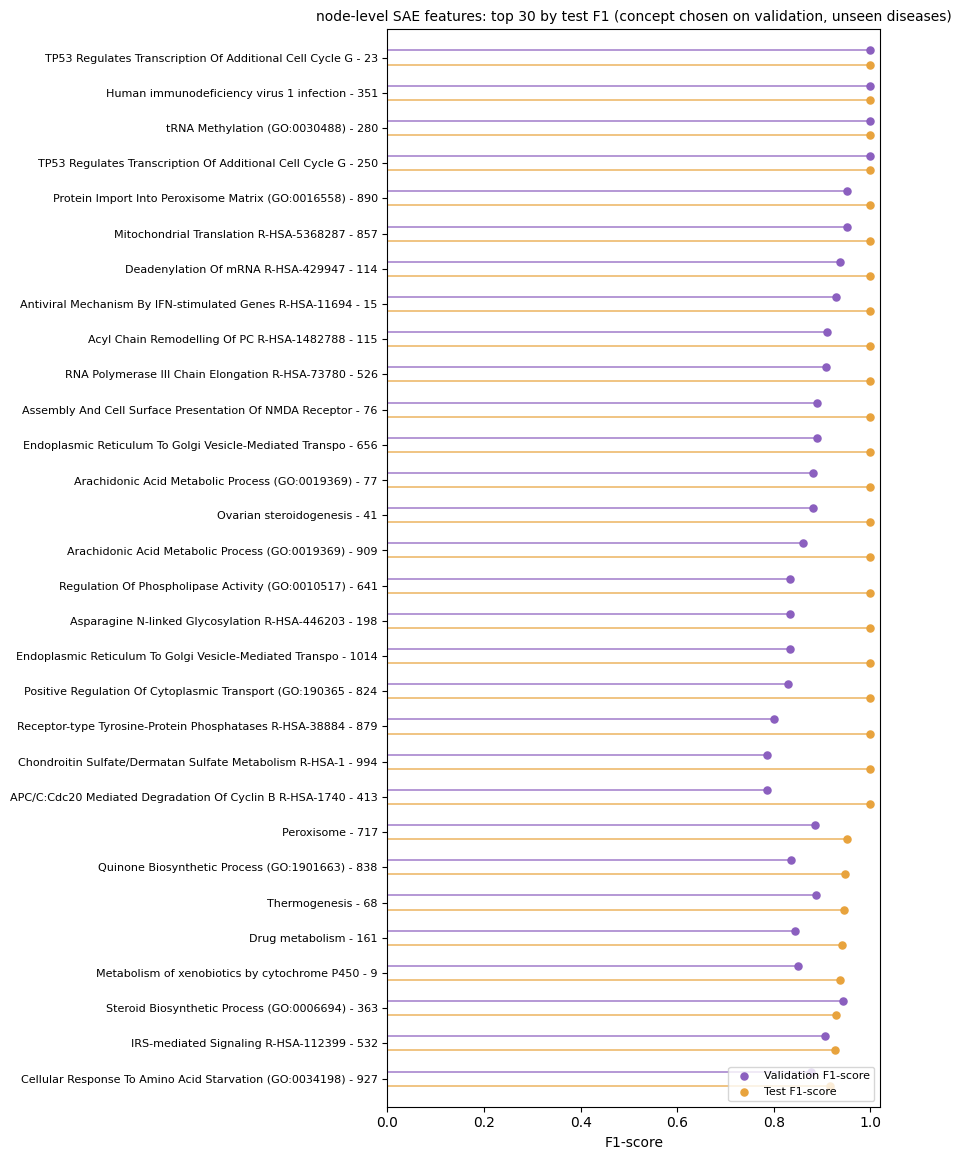

median validation -> test change: +0.091 (0 of 30 features lose more than 0.2)


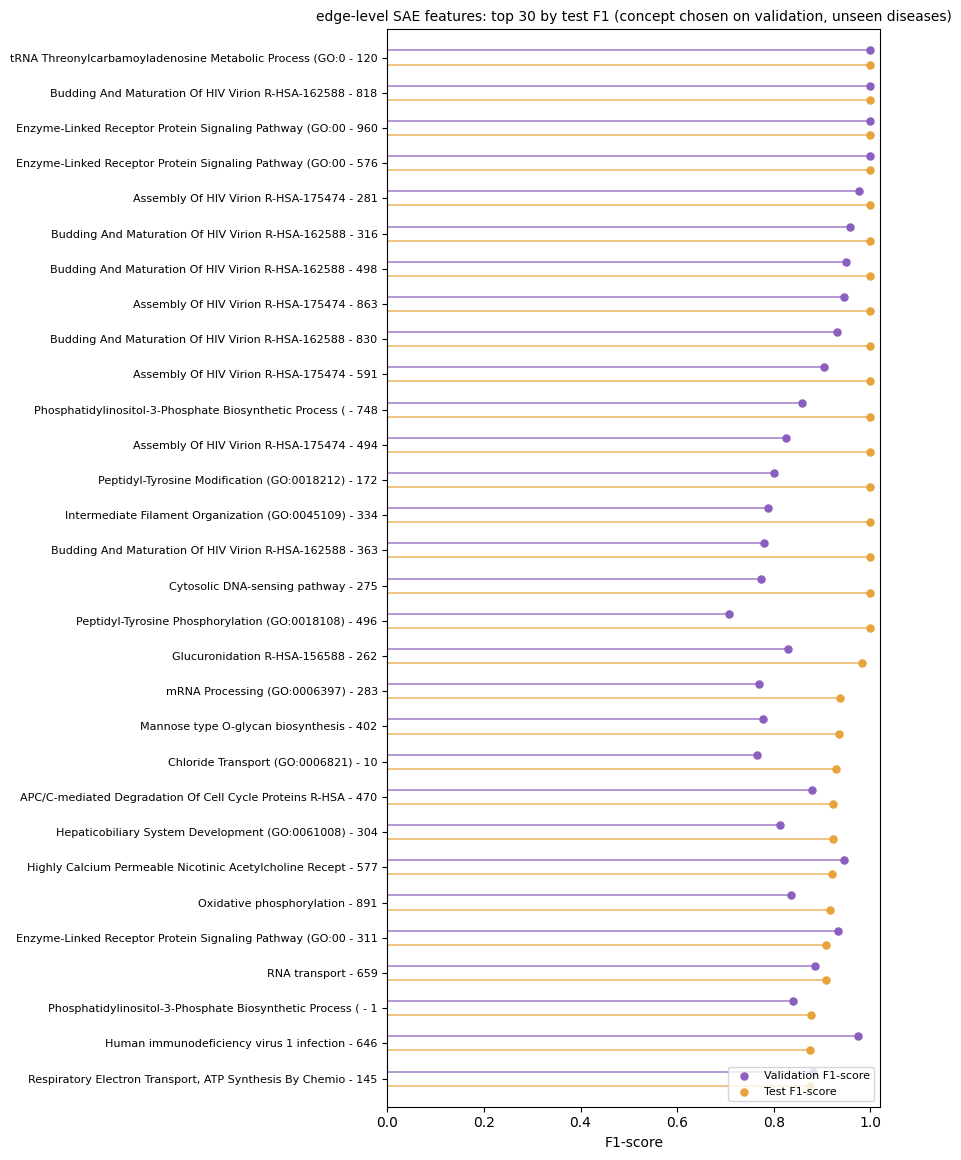

median validation -> test change: +0.062 (0 of 30 features lose more than 0.2)


In [20]:
def plot_val_test_f1(table, level, top_n=30):
    # Ranked by test F1: these are the concepts that actually generalised to held-out diseases,
    # not just the ones that happened to score best on the diseases used to pick them.
    tbl = (
        table.dropna(subset=["f1_test"])
        .sort_values(["f1_test", "f1_val"], ascending=[False, False])
        .head(top_n)
        .iloc[::-1]
    )
    labels = [f"{str(t).split(' | ')[-1][:55]} - {int(f)}" for t, f in zip(tbl["term"], tbl["feature"])]
    y = np.arange(len(tbl), dtype=float)
    val, test = tbl["f1_val"].to_numpy(), tbl["f1_test"].to_numpy()
    scored = ~np.isnan(test)
    offset = 0.2

    fig, ax = plt.subplots(figsize=(9, 0.34 * len(tbl) + 1.5))
    ax.hlines(y + offset, 0, val, color="#8b5fbf", lw=1.2, alpha=0.75, zorder=1)
    ax.hlines(y[scored] - offset, 0, test[scored], color="#e8a33d", lw=1.2, alpha=0.75, zorder=1)
    ax.scatter(val, y + offset, s=26, color="#8b5fbf", zorder=3, label="Validation F1-score")
    ax.scatter(test[scored], y[scored] - offset, s=26, color="#e8a33d", zorder=3, label="Test F1-score")

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_ylim(-0.8, len(tbl) - 0.2)
    ax.set_xlabel("F1-score")
    ax.set_xlim(0, 1.02)
    ax.legend(loc="lower right", fontsize=8, frameon=True)
    ax.grid(False)
    ax.set_title(f"{level}-level SAE features: top {top_n} by test F1 "
                 f"(concept chosen on validation, unseen diseases)", fontsize=10)
    plt.tight_layout(); plt.show()

    delta = (tbl["f1_test"] - tbl["f1_val"]).dropna()
    print(f"median validation -> test change: {delta.median():+.3f} "
          f"({(delta < -0.2).sum()} of {len(delta)} features lose more than 0.2)")


plot_val_test_f1(node_table, "node")
plot_val_test_f1(edge_table, "edge")

### Is a feature a protein, or a mechanism?

There is an unexamined loop running through everything above. The node features handed to the GNN
are ESM-2 embeddings, which are a function of the protein and nothing else. The concept
dictionary is $M_{g,t} = \mathbb{1}[g \in t]$ — again a function of the protein and nothing else.
If the encoder's output were also essentially a function of the protein, then an SAE feature
would be an indicator over a set of proteins, a term would be an indicator over a set of
proteins, and "feature 415 is about enzyme-linked receptor signalling" would be the overlap of
two gene sets: true, checkable, and about the contents of the gene list rather than about the
disease. Every F1 in the previous section is compatible with that reading.

Dropping the ESM-reconstruction objective and giving every disease a local background to sit in
was meant to break that loop. Whether it did is a measurement, not an argument, and it takes four
steps:

1. **How much of the representation is protein identity?** A variance decomposition over the same
   protein appearing in many different diseases.
2. **Where does the annotation come from?** Run the concept assignment separately on the
   protein-average part of the code and on the disease-varying remainder.
3. **What F1 does an annotation reach when there is nothing to find?** A degree-, frequency- and
   annotation-depth-matched permutation of the concept dictionary, repeated 20 times.
4. **Does any of it beat reading the gene list?** Plain over-representation analysis of each
   held-out disease's gene set against the same terms.

The scoring rule never changes across the four — same thresholds, same F1, same per-disease
loop — so every comparison below is against the exact procedure that produced the annotations.

#### 1. How much of the representation is protein identity?

For each protein that appears in at least two disease contexts, split the total variance of its
rows into the part between proteins and the part within a protein:

$$R^2_{\text{identity}} = 1 - \frac{\sum_g \sum_{d} \lVert z_{g,d} - \bar z_g \rVert^2}{\sum_{g,d} \lVert z_{g,d} - \bar z \rVert^2}$$

1.0 is a lookup table — the protein's representation is identical everywhere it appears, and the
disease context changed nothing. 0.0 is a representation that ignores which protein it is
looking at. This is a variance decomposition, not a correlation, so it can be read directly as
"what fraction of what the SAE sees is decided before the disease is known".

Computed on the embeddings $h_i^{(d)}$ and on the sparse code, at both levels that have a
repeating identity: nodes (the protein) and edges (the protein pair).

In [21]:
def identity_r2(matrix, groups, per_column=False, chunk=200_000):
    """Fraction of the variance in `matrix` that is explained by group identity alone.

    A one-way multivariate variance decomposition: 1 - SS_within / SS_total, where "within"
    means within one protein (or one protein pair). 1.0 says every row of a given protein is
    identical wherever it appears, i.e. the representation is a lookup table keyed by protein;
    0.0 says knowing the protein tells you nothing. Streamed in chunks because the edge level
    has millions of rows and 1024 features.
    """
    g = torch.as_tensor(np.asarray(groups, dtype=np.int64))
    n_groups, dim = int(g.max()) + 1, matrix.shape[1]
    total = torch.zeros(dim, device=device, dtype=torch.float64)
    sums = torch.zeros(n_groups, dim, device=device, dtype=torch.float64)
    counts = torch.zeros(n_groups, device=device, dtype=torch.float64)
    for start in range(0, len(matrix), chunk):
        xb = matrix[start:start + chunk].to(device).double()
        gb = g[start:start + chunk].to(device)
        total += xb.sum(0)
        sums.index_add_(0, gb, xb)
        counts.index_add_(0, gb, torch.ones(len(gb), device=device, dtype=torch.float64))
    grand = total / len(matrix)
    group_means = sums / counts.clamp(min=1)[:, None]

    ss_total = torch.zeros(dim, device=device, dtype=torch.float64)
    ss_within = torch.zeros_like(ss_total)
    for start in range(0, len(matrix), chunk):
        xb = matrix[start:start + chunk].to(device).double()
        gb = g[start:start + chunk].to(device)
        ss_total += ((xb - grand) ** 2).sum(0)
        ss_within += ((xb - group_means[gb]) ** 2).sum(0)
    if per_column:
        return (1 - ss_within / ss_total.clamp(min=1e-12)).cpu().numpy()
    return float(1 - ss_within.sum() / ss_total.sum())


def sae_activations(sae, embeddings, batch_size=65_536):
    """Full activation matrix for an embedding array, on the CPU."""
    out = []
    with torch.no_grad():
        for start in range(0, len(embeddings), batch_size):
            xb = torch.tensor(np.asarray(embeddings[start:start + batch_size]).astype(np.float32))
            out.append(sae(xb.to(device))[0].cpu())
    return torch.cat(out)


# --- node level: identity = the protein ---
node_h = node_export["embeddings"]
node_protein = np.asarray(node_export["protein"])
node_mask = node_export["mask"]
node_acts = sae_activations(node_sae, node_h)

_, protein_code = np.unique(node_protein, return_inverse=True)
recurs = np.bincount(protein_code)[protein_code] >= 2   # a protein seen in only one disease says nothing
gene_group = np.unique(protein_code[recurs], return_inverse=True)[1]
gene_mask_group = np.unique(protein_code[recurs] * 2 + node_mask[recurs], return_inverse=True)[1]

node_h_keep = torch.tensor(node_h[recurs])
node_acts_keep = node_acts[recurs]
r2 = {
    ("node", "protein"): (identity_r2(node_h_keep, gene_group), identity_r2(node_acts_keep, gene_group)),
    ("node", "protein x mask"): (identity_r2(node_h_keep, gene_mask_group),
                                 identity_r2(node_acts_keep, gene_mask_group)),
}
node_feature_r2 = identity_r2(node_acts_keep, gene_group, per_column=True)
node_freq = (node_acts > 0).float().mean(0).numpy()

# --- edge level: identity = the protein pair (sampled; 5.8M rows x 1024 features will not fit) ---
EDGE_SAMPLE = 800_000
pair_key = np.char.add(np.char.add(np.asarray(edge_export["protein_a"]).astype(str), "|"),
                       np.asarray(edge_export["protein_b"]).astype(str))
_, pair_code = np.unique(pair_key, return_inverse=True)
edge_recurs = np.flatnonzero(np.bincount(pair_code)[pair_code] >= 2)
edge_idx = np.sort(np.random.default_rng(SEED).choice(edge_recurs, min(EDGE_SAMPLE, len(edge_recurs)),
                                                      replace=False))
pair_group = np.unique(pair_code[edge_idx], return_inverse=True)[1]
edge_h_keep = torch.tensor(edge_export["embeddings"][edge_idx].astype(np.float32))
edge_acts_keep = sae_activations(edge_sae, edge_h_keep.numpy())
r2[("edge", "protein pair")] = (identity_r2(edge_h_keep, pair_group),
                                identity_r2(edge_acts_keep, pair_group))

identity_table = pd.DataFrame(
    [{"level": lv, "identity": key, "R2_embedding": a, "R2_activation": b} for (lv, key), (a, b) in r2.items()]
)
print(f"{recurs.mean():.1%} of node rows are proteins seen in >= 2 diseases; "
      f"{len(np.unique(pair_code)):,} distinct protein pairs over {len(pair_key):,} edge rows\n")
print(identity_table.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

99.8% of node rows are proteins seen in >= 2 diseases; 123,290 distinct protein pairs over 5,796,601 edge rows

level       identity  R2_embedding  R2_activation
 node        protein         0.709          0.642
 node protein x mask         0.810          0.767
 edge   protein pair         0.715          0.665


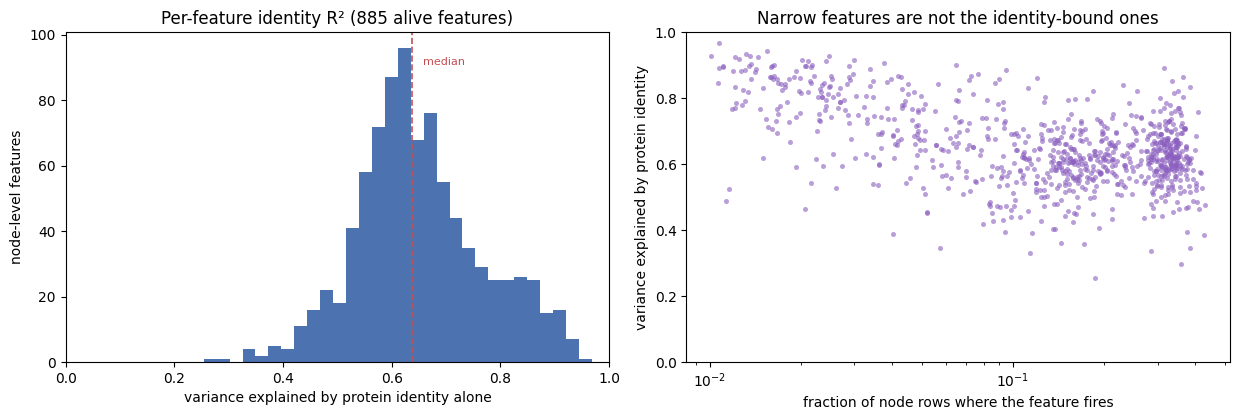

per-feature identity R²: median 0.637 | range 0.254-0.968
Spearman(firing rate, identity R²) = -0.37


In [22]:
alive_node = node_freq >= 0.01

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax = axes[0]
ax.hist(node_feature_r2[alive_node], bins=30, color="#4C72B0")
ax.axvline(np.median(node_feature_r2[alive_node]), color="#c44e52", ls="--", lw=1.2)
ax.set(xlim=(0, 1), xlabel="variance explained by protein identity alone",
       ylabel="node-level features",
       title=f"Per-feature identity R² ({alive_node.sum()} alive features)")
ax.text(np.median(node_feature_r2[alive_node]) + 0.02, ax.get_ylim()[1] * 0.9, "median",
        fontsize=8, color="#c44e52")

ax = axes[1]
ax.scatter(node_freq[alive_node], node_feature_r2[alive_node], s=13, alpha=0.6,
           color="#8b5fbf", linewidths=0)
ax.set(xscale="log", ylim=(0, 1), xlabel="fraction of node rows where the feature fires",
       ylabel="variance explained by protein identity",
       title="Narrow features are not the identity-bound ones")
for ax in axes:
    ax.grid(False)
plt.tight_layout(); plt.show()

print(f"per-feature identity R²: median {np.median(node_feature_r2[alive_node]):.3f} | "
      f"range {node_feature_r2[alive_node].min():.3f}-{node_feature_r2[alive_node].max():.3f}")
print(f"Spearman(firing rate, identity R²) = "
      f"{pd.Series(node_freq[alive_node]).corr(pd.Series(node_feature_r2[alive_node]), method='spearman'):.2f}")

At 0.71 for the node embeddings and 0.64 for the sparse code, protein identity is the single
largest component of the representation and it would be dishonest to describe it as anything
else. But roughly a third of the code varies with the disease context the protein sits in, and
that is the part able to carry anything disease-specific. Grouping by protein **and** mask status
raises it to 0.77, so about half of that context variation is the model responding to "is this
protein one of this disease's genes, or part of its background", and half of it is finer than
that.

The edge level behaves the same way (0.67 for the code against pair identity). Worth noting,
because $e_{ij} = (h_i \odot h_j)/\lVert h_i - h_j \rVert$ is a function of two node states and
could easily have come out *more* identity-bound than either endpoint.

Per feature the spread is wide — 0.25 to 0.97, median 0.64 — so there is no clean subset of
"context features" to restrict the interpretation to, and there are individual entries that
really are close to protein detectors. The correlation with firing rate is the uncomfortable
part: at Spearman −0.37 it runs the wrong way. The **narrower** a feature, the more of it is
protein identity, and narrow features are exactly the ones that produce the crisp, small-term,
high-F1 annotations that look most convincing in the table above.

Overall this is the result the notebook needs, if not the one it would have wanted: not the ≈0.95
that would make every annotation in the previous section a tautology, and not low enough to
describe the representation as being about disease context. It is a representation mostly about
proteins, with a real minority component that is not.

#### 2. Where does the annotation come from?

The decomposition above is also an experiment. Split the node code in two,

$$a_{g,d} = \underbrace{\bar a_g}_{\text{what this protein always looks like}} + \underbrace{\Delta a_{g,d}}_{\text{what this disease did to it}}$$

and run the identical annotation procedure three times: on the real code, on $\bar a_g$ broadcast
back over every row — a pure lookup table, by construction — and on $\mathrm{ReLU}(\Delta a_{g,d})$,
which fires only where a protein is above its own average. If the concepts come from the lookup
table, the middle row will match the first and the third will collapse.

`annotate_from_activations` below is the annotator from the previous section rewritten to take
the activations and the concept matrix as arguments instead of recomputing them. That is what
makes it possible to re-run the whole annotation over a different code, or a different concept
dictionary, dozens of times — which steps 2 and 3 both need.

In [23]:
TERM_MATRIX = torch.as_tensor(term_table.to_numpy().astype(np.float32), device=device)
TERM_NAMES = np.asarray(term_table.columns)
gene_pos = {g: i for i, g in enumerate(term_table.index)}

node_doid = np.asarray(node_export["doid"])
node_gene_idx = torch.as_tensor(np.array([gene_pos[p] for p in node_protein]), device=device)
edge_doid = np.asarray(edge_export["doid"])
edge_a_idx = torch.as_tensor(np.array([gene_pos[p] for p in np.asarray(edge_export["protein_a"])]), device=device)
edge_b_idx = torch.as_tensor(np.array([gene_pos[p] for p in np.asarray(edge_export["protein_b"])]), device=device)


def node_membership(gene_idx):
    """Row -> term membership for nodes: the protein's own terms."""
    def membership(rows, terms=None):
        return (TERM_MATRIX if terms is None else terms)[gene_idx[rows]]
    return membership


def edge_membership(a_idx, b_idx):
    """Row -> term membership for edges: a term the *both* endpoints belong to."""
    def membership(rows, terms=None):
        T = TERM_MATRIX if terms is None else terms
        return (T[a_idx[rows]].bool() & T[b_idx[rows]].bool()).float()
    return membership


def annotate_from_activations(acts, doids, membership, doid_subset, terms=None,
                              thresholds=(0.15, 0.3, 0.5), top_k=3,
                              min_activation_frac=0.01, min_active=3, min_f1=0.05):
    """The annotator above, rewritten to take an activation matrix and a term matrix.

    Same rule, same thresholds, same F1 — the only difference is that the activations and the
    gene-to-term membership are arguments rather than recomputed inside, which is what makes it
    possible to run the whole annotation over a *different* activation matrix (the gene-mean and
    residual decompositions below) or a *different* concept matrix (the permutation nulls), tens
    of times, without re-deriving anything else.
    """
    freq = (acts > 0).float().mean(0)
    maxima = acts.max(0).values.clamp(min=1e-8)
    alive = torch.nonzero(freq >= min_activation_frac).reshape(-1)
    alive_maxima = maxima[alive].to(device)
    feature_ids = alive.numpy()

    rows_all = np.flatnonzero(np.isin(doids, doid_subset))
    rows_all = rows_all[np.argsort(doids[rows_all], kind="stable")]
    ordered = doids[rows_all]
    bounds = np.flatnonzero(np.r_[True, ordered[1:] != ordered[:-1], True])

    records = []
    for b in range(len(bounds) - 1):
        rows = rows_all[bounds[b]:bounds[b + 1]]
        relative = acts[rows][:, alive].to(device) / alive_maxima
        row_terms = membership(torch.as_tensor(rows, device=device), terms)

        best_f1 = None
        for t in thresholds:
            fired = (relative > t).float()
            tp = fired.T @ row_terms
            n_active, n_term = fired.sum(0), row_terms.sum(0)
            f1 = 2 * tp / (n_active[:, None] + n_term[None, :] + 1e-8)
            f1[n_active < min_active] = 0.0
            best_f1 = f1 if best_f1 is None else torch.maximum(best_f1, f1)

        top_f1, top_terms = torch.topk(best_f1, k=min(top_k, best_f1.shape[1]), dim=1)
        top_f1, top_terms = top_f1.cpu().numpy(), top_terms.cpu().numpy()
        keep = top_f1 >= min_f1
        if not keep.any():
            continue
        feat_pos, rank = np.nonzero(keep)
        records.append(pd.DataFrame({
            "doid": ordered[bounds[b]], "feature": feature_ids[feat_pos],
            "term": TERM_NAMES[top_terms[feat_pos, rank]], "f1": top_f1[feat_pos, rank],
        }))
    if not records:
        return pd.DataFrame(columns=["doid", "feature", "term", "f1"])
    return pd.concat(records, ignore_index=True)


def consensus(records, min_support=2):
    """One term per feature: its best mean F1 across at least `min_support` diseases."""
    agg = (records.groupby(["feature", "term"])
                  .agg(mean_f1=("f1", "mean"), support=("doid", "nunique")).reset_index())
    agg = agg[agg["support"] >= min_support]
    return agg.loc[agg.groupby("feature")["mean_f1"].idxmax()].reset_index(drop=True)


def group_means(acts, groups):
    """Replace every row by the mean activation of its protein — a pure lookup-table code."""
    g = torch.as_tensor(np.asarray(groups, dtype=np.int64), device=device)
    n = int(g.max()) + 1
    counts = torch.zeros(n, device=device).index_add_(0, g, torch.ones(len(g), device=device))
    sums = torch.zeros(n, acts.shape[1], device=device)
    for start in range(0, len(acts), 200_000):
        sums.index_add_(0, g[start:start + 200_000], acts[start:start + 200_000].to(device))
    means = sums / counts.clamp(min=1)[:, None]
    return torch.cat([means[g[s:s + 200_000]].cpu() for s in range(0, len(acts), 200_000)])


# node activations split into "what this protein always looks like" + "what this disease did to it"
node_group = torch.as_tensor(protein_code.astype(np.int64))
node_acts_gene = group_means(node_acts, protein_code)
node_acts_resid = torch.relu(node_acts - node_acts_gene)   # fires above its own protein's average

variants = {}
for name, acts in [("as trained", node_acts), ("protein mean only", node_acts_gene),
                   ("disease residual", node_acts_resid)]:
    rec = annotate_from_activations(acts, node_doid, node_membership(node_gene_idx), train_doids)
    variants[name] = consensus(rec)
    print(f"{name:>18}: {len(variants[name]):>4} features annotated | "
          f"median F1 {variants[name]['mean_f1'].median():.3f}")

agreement = variants["as trained"].merge(variants["protein mean only"], on="feature",
                                         suffixes=("", "_gene"))
print(f"\nsame concept chosen from the protein-mean code as from the real one: "
      f"{(agreement['term'] == agreement['term_gene']).mean():.1%} of {len(agreement)} features")

        as trained:  885 features annotated | median F1 0.800


 protein mean only:  913 features annotated | median F1 0.754


  disease residual:  864 features annotated | median F1 0.800

same concept chosen from the protein-mean code as from the real one: 6.8% of 884 features


Median F1 barely moves: 0.80 on the real code, 0.75 from the lookup table alone, 0.80 from what
is left after removing it. Read naively that says the annotation does not depend on the
representation at all.

That is the correct reading, and it is the reason step 3 exists. The three codes also disagree
about *which* term each feature gets — only 7% of features are given the same term by the real
code and by the protein-mean code — so this is not one annotation reproduced three times. It is
three different annotations of comparable quality. When three codes that share almost nothing all
score 0.8, the thing being measured is the scoring rule, not the code.

#### 3. What does an annotation score when there is nothing to find?

Step 2 showed three unrelated codes all reaching F1 ≈ 0.8, which means the number has no
reference point. This supplies one.

The permutation shuffles **which protein carries which set of term memberships**. Every term keeps
exactly the size it had (whole rows move), and a protein can only swap with another of comparable
PPI degree, comparable frequency across disease contexts, and comparable annotation depth — so a
hub annotated forty times swaps with another hub annotated forty times. Everything the annotation
search could be exploiting survives the shuffle: the size of the terms, the density of the
dictionary, the fact that well-studied proteins are in many terms and appear in many diseases,
and the fact that a feature firing on twelve proteins has thousands of candidate terms to be
matched against. The only thing destroyed is the correspondence between a protein's biology and
its labels, which is the one thing an annotation is supposed to be using.

Run over a sample of 150 training diseases at both levels, twenty times, against the real
dictionary scored on exactly the same diseases.

In [24]:
from statsmodels.stats.multitest import multipletests

N_PERMUTATIONS = 20
NULL_N_DISEASES = 150   # a sample, so 20 permutations at two levels stay a couple of minutes

string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")
ppi_degree = pd.concat([string_links["protein1"], string_links["protein2"]]).value_counts()
occurrences = pd.Series(node_protein).value_counts()

universe = list(term_table.index)
matched_on = pd.DataFrame({
    "degree": [ppi_degree.get(p, 0) for p in universe],          # hub proteins sit in many terms
    "occurrence": [occurrences.get(p, 0) for p in universe],     # ... and in many disease contexts
    "n_terms": term_table.to_numpy().sum(axis=1),                # ... and are better annotated
})
N_BINS = 4
bin_id = sum(np.floor(matched_on[c].rank(method="first") / (len(universe) + 1) * N_BINS).astype(int)
             * N_BINS ** i for i, c in enumerate(matched_on.columns))
bin_members = [np.flatnonzero(bin_id == b) for b in np.unique(bin_id)]
print(f"{len(bin_members)} matched bins over {len(universe):,} proteins "
      f"(smallest {min(len(m) for m in bin_members)}, median {int(np.median([len(m) for m in bin_members]))})")


def matched_permutation(rng):
    """Shuffle which protein carries which set of term memberships, within matched bins.

    Term sizes are preserved exactly (whole rows move), and a protein can only swap memberships
    with another of comparable PPI degree, comparable frequency across disease contexts and
    comparable annotation depth. What is destroyed is only the correspondence between a protein's
    biology and its labels — which is exactly the thing an annotation is supposed to be using.
    """
    perm = np.arange(len(universe))
    for members in bin_members:
        perm[members] = rng.permutation(members)
    return TERM_MATRIX[torch.as_tensor(perm, device=device)]


def null_calibrated_annotations(acts, doids, membership, doid_sample, min_active=3):
    """Real annotation F1 per feature, against `N_PERMUTATIONS` matched-permutation nulls."""
    real = consensus(annotate_from_activations(acts, doids, membership, doid_sample,
                                               min_active=min_active))
    rng = np.random.default_rng(SEED)
    null_cols = []
    for _ in range(N_PERMUTATIONS):
        rec = annotate_from_activations(acts, doids, membership, doid_sample,
                                        terms=matched_permutation(rng), min_active=min_active)
        null_cols.append(consensus(rec).set_index("feature")["mean_f1"])
    # a feature missing from a null's consensus never reached min_f1 with support >= 2 there,
    # which is a null F1 of zero for our purposes
    nulls = np.nan_to_num(pd.concat(null_cols, axis=1).reindex(real["feature"]).to_numpy(), nan=0.0)

    real = real.assign(
        f1_null=np.median(nulls, axis=1),
        excess=real["mean_f1"].to_numpy() - np.median(nulls, axis=1),
        beats_all=(nulls < real["mean_f1"].to_numpy()[:, None]).all(axis=1),
        p=(np.sum(nulls >= real["mean_f1"].to_numpy()[:, None], axis=1) + 1) / (nulls.shape[1] + 1),
    )
    real["fdr"] = multipletests(real["p"], method="fdr_bh")[1]
    return real.sort_values("excess", ascending=False).reset_index(drop=True), nulls


rng = np.random.default_rng(SEED)
null_sample = rng.choice(train_doids, min(NULL_N_DISEASES, len(train_doids)), replace=False)

node_null, node_null_matrix = null_calibrated_annotations(
    node_acts, node_doid, node_membership(node_gene_idx), null_sample)

# the edge level is scored on the sampled diseases only -- 5.8M rows x 1024 features would be 24 GB
edge_rows = torch.as_tensor(np.flatnonzero(np.isin(edge_doid, null_sample)), device=device)
edge_acts_sample = sae_activations(edge_sae, edge_export["embeddings"][edge_rows.cpu().numpy()])
edge_null, edge_null_matrix = null_calibrated_annotations(
    edge_acts_sample, edge_doid[edge_rows.cpu().numpy()],
    edge_membership(edge_a_idx[edge_rows], edge_b_idx[edge_rows]), null_sample, min_active=5)

for level, table in [("node", node_null), ("edge", edge_null)]:
    print(f"\n{level}-level, {len(table)} features on {len(null_sample)} sampled train diseases")
    print(f"  median F1 {table['mean_f1'].median():.3f} | matched-null median "
          f"{table['f1_null'].median():.3f} | median excess {table['excess'].median():+.3f}")
    print(f"  {(table['excess'] > 0).sum()}/{len(table)} features score above their own matched null; "
          f"{table['beats_all'].sum()} beat every one of the {N_PERMUTATIONS} permutations")
    print(f"  (with {N_PERMUTATIONS} permutations the smallest reachable p is "
          f"{1 / (N_PERMUTATIONS + 1):.3f}, so BH over {len(table)} features cannot clear 0.05 "
          f"unless nearly all of them do; `excess` is the number to read, not `fdr`)")

64 matched bins over 10,488 proteins (smallest 10, median 132)



node-level, 884 features on 150 sampled train diseases
  median F1 0.703 | matched-null median 0.528 | median excess +0.167
  839/884 features score above their own matched null; 482 beat every one of the 20 permutations
  (with 20 permutations the smallest reachable p is 0.048, so BH over 884 features cannot clear 0.05 unless nearly all of them do; `excess` is the number to read, not `fdr`)

edge-level, 733 features on 150 sampled train diseases
  median F1 0.440 | matched-null median 0.212 | median excess +0.226
  710/733 features score above their own matched null; 549 beat every one of the 20 permutations
  (with 20 permutations the smallest reachable p is 0.048, so BH over 733 features cannot clear 0.05 unless nearly all of them do; `excess` is the number to read, not `fdr`)


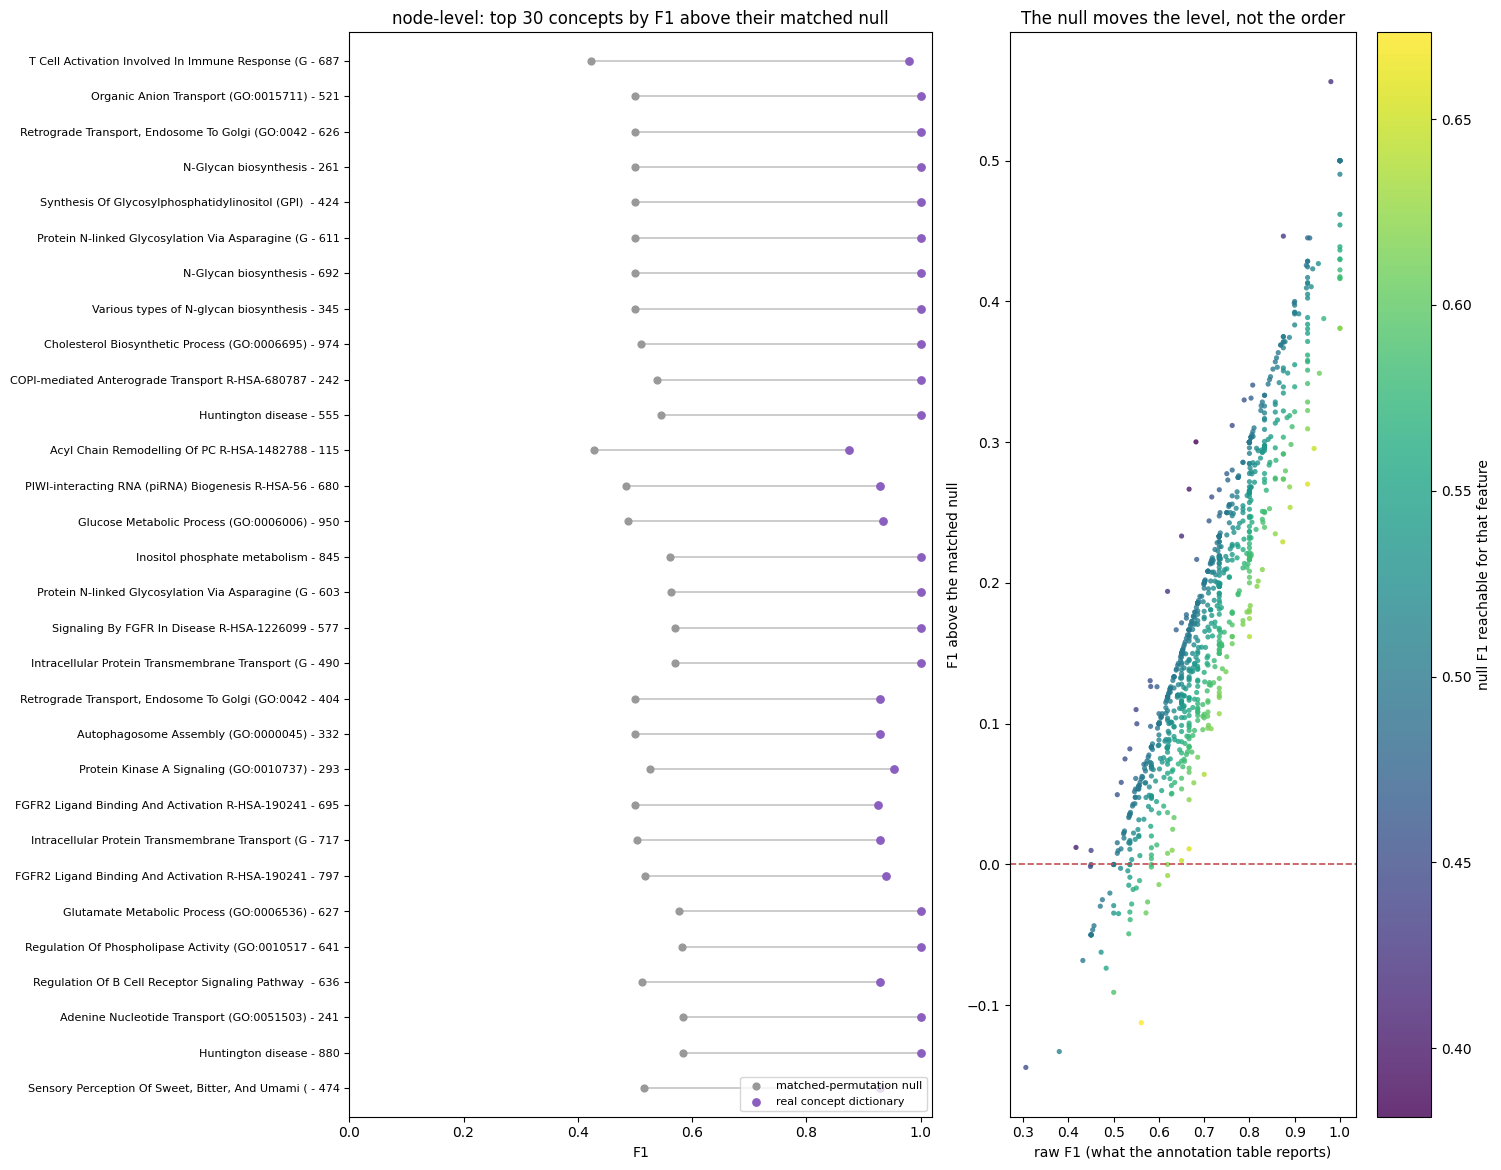

node: Spearman(raw F1, excess) = 0.94


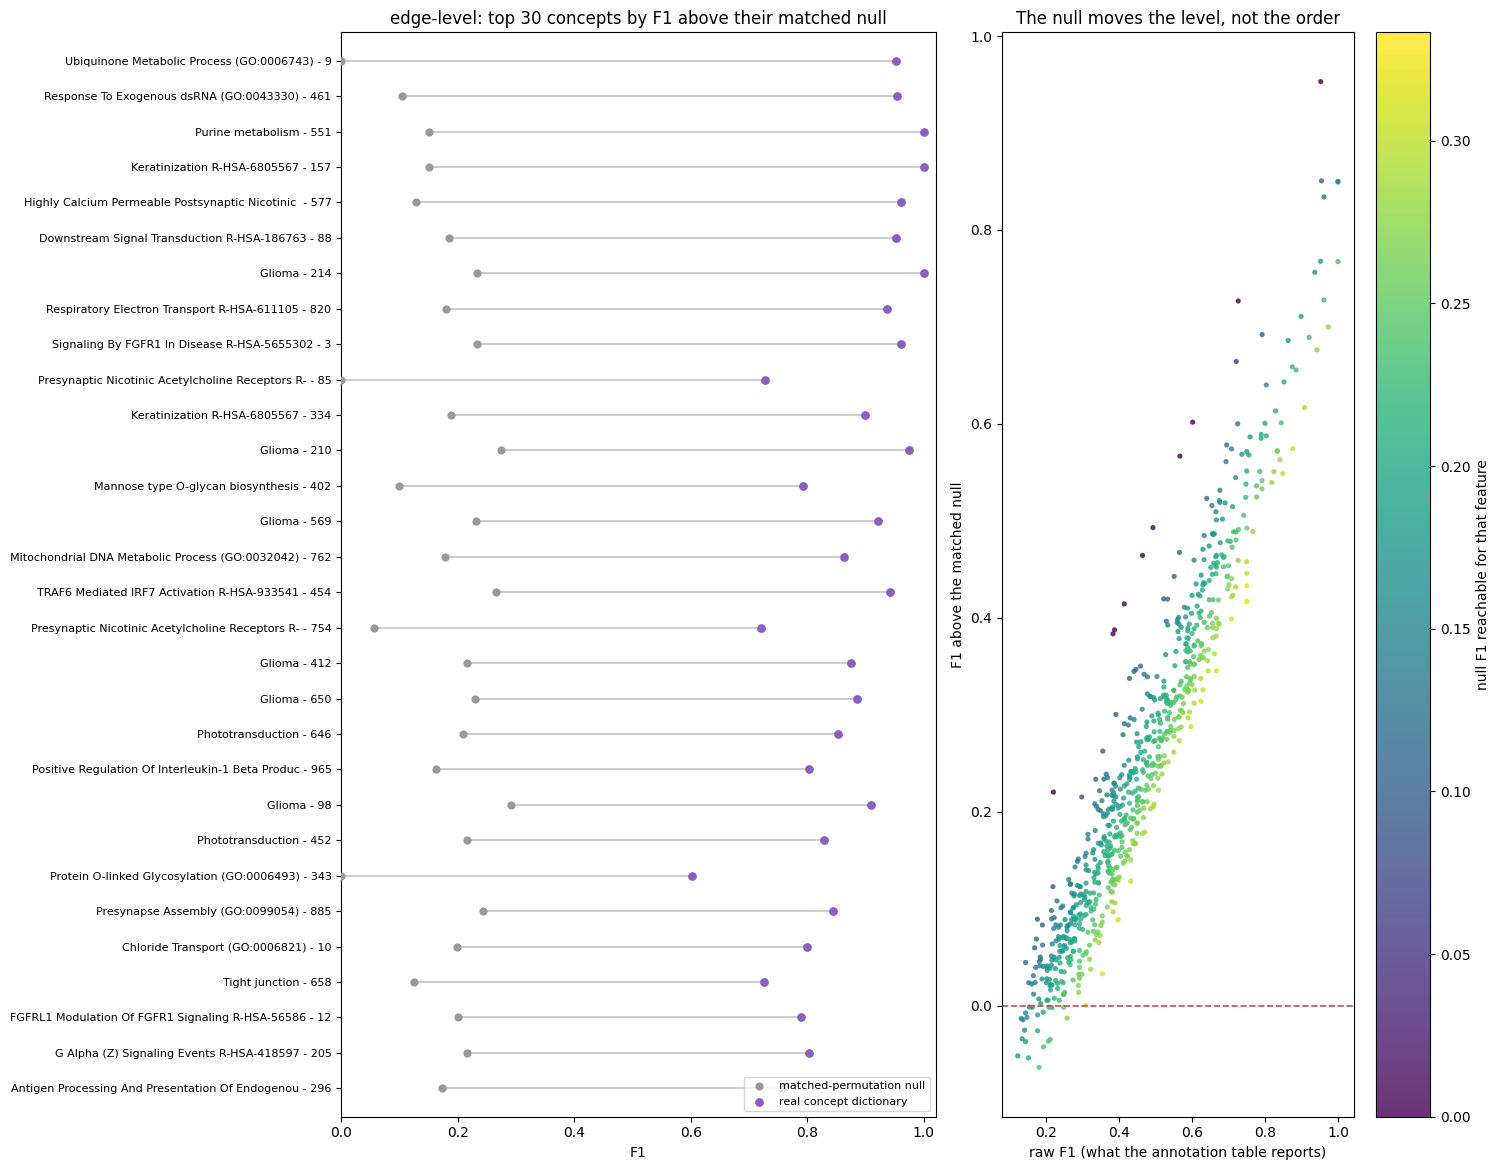

edge: Spearman(raw F1, excess) = 0.96


In [25]:
def plot_null_calibration(table, level, top_n=30):
    """Concepts ranked by how far they beat their own matched null, not by raw F1."""
    tbl = table.head(top_n).iloc[::-1]
    y = np.arange(len(tbl), dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(15, max(0.34 * len(tbl) + 1.6, 4.2)),
                             gridspec_kw={"width_ratios": [1.35, 1]})

    ax = axes[0]
    ax.hlines(y, tbl["f1_null"], tbl["mean_f1"], color="#cccccc", lw=1.4, zorder=1)
    ax.scatter(tbl["f1_null"], y, s=24, color="#999999", zorder=3, label="matched-permutation null")
    ax.scatter(tbl["mean_f1"], y, s=28, color="#8b5fbf", zorder=4, label="real concept dictionary")
    ax.set_yticks(y)
    ax.set_yticklabels([f"{str(t).split(' | ')[-1][:48]} - {int(f)}"
                        for t, f in zip(tbl["term"], tbl["feature"])], fontsize=8)
    ax.set(xlim=(0, 1.02), xlabel="F1", ylim=(-0.8, len(tbl) - 0.2),
           title=f"{level}-level: top {len(tbl)} concepts by F1 above their matched null")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(False)

    ax = axes[1]
    sc = ax.scatter(table["mean_f1"], table["excess"], s=14, c=table["f1_null"],
                    cmap="viridis", alpha=0.8, linewidths=0)
    ax.axhline(0, color="#c44e52", lw=1.2, ls="--")
    ax.set(xlabel="raw F1 (what the annotation table reports)",
           ylabel="F1 above the matched null",
           title="The null moves the level, not the order")
    ax.grid(False)
    fig.colorbar(sc, ax=ax, label="null F1 reachable for that feature")
    plt.tight_layout(); plt.show()

    print(f"{level}: Spearman(raw F1, excess) = "
          f"{table[['mean_f1', 'excess']].corr(method='spearman').iloc[0, 1]:.2f}")


plot_null_calibration(node_null, "node")
plot_null_calibration(edge_null, "edge")

A matched null reaches a median F1 of **0.53** at the node level and **0.21** at the edge level
without using any biology whatsoever. The real dictionaries reach 0.70 and 0.44 on exactly the
same diseases. So the evidence carried by an annotation is the gap — about +0.17 and +0.23 — not
the number the previous section printed, and on the node side roughly three quarters of the raw
score is reachable by a relabelling.

839 of 884 node features and 710 of 733 edge features land above their own null, and 482 and 549
respectively beat every one of the twenty permutations. Twenty permutations put a floor of 0.048
on any single feature's p-value, so a BH correction across ~900 features cannot clear 0.05 no
matter how strong the signal is; `excess` and `beats_all` are the columns to read here, and `fdr`
is kept in the table only so that limitation stays visible instead of silently passing.

The second panel is the reassuring one. Spearman between raw F1 and excess is 0.94 at the node
level and 0.96 at the edge level, so the null moves the *level* of the scores without much
reordering them. The ranking in the F1 plot above was not wrong — it was calibrated against zero
instead of against 0.5. The features worth reading are still the ones at the top; they are worth
about a third less than they appeared to be.

One structural difference between the levels is worth naming: an edge belongs to a term only when
**both** endpoints do, which makes the target far sparser and much harder to hit by accident.
That is why the edge null sits at 0.21 where the node null sits at 0.53. The edge annotations
have the weaker dictionary behind them (22% dead, R² 0.85) and the stronger null.

#### 4. Does any of it beat reading the gene list?

The cheapest explanation of everything above is that the pipeline is an expensive way of
recovering what the disease gene set already says. So run the cheap version: plain
over-representation analysis — hypergeometric test of each held-out disease's seed genes against
the same terms, over the same protein universe — and compare it with what GEA annotates the same
disease's node features with.

The comparison is made at matched depth, the best 50 terms from each method, because the two
return very different numbers of terms and an unmatched overlap would mostly measure that. A
random draw of 50 terms is shown alongside as the floor.

If GEA's terms were a subset of the ORA terms, neither the GNN nor the SAE would be adding
anything to a one-line enrichment call.

184 held-out diseases | median 111 seed genes, 467 terms significant by plain ORA (BH < 0.05)

top-50 terms, GEA vs ORA: median overlap 1 (chance 0)
share of GEA's top-50 terms that ORA calls significant at all: 22.0% (median across diseases)


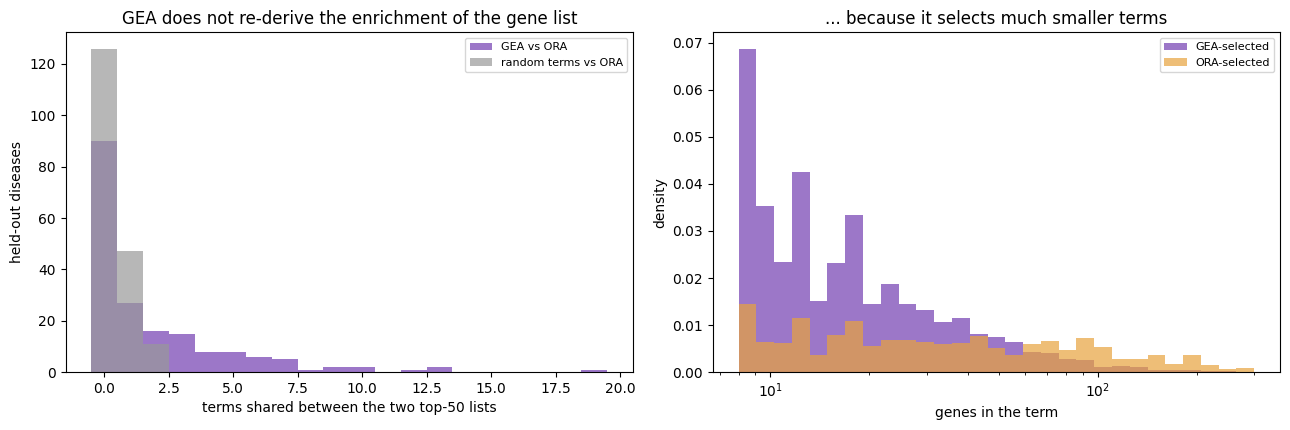


median term size: GEA 27 genes | ORA 91 genes


In [26]:
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

ORA_TOP_N = 50   # compare like with like: the N best terms from each method, per disease

term_matrix = term_table.to_numpy()
term_sizes = term_matrix.sum(axis=0)
term_size_by_name = dict(zip(TERM_NAMES, term_sizes))
n_universe = term_table.shape[0]

seed_genes = {}
for doid, gene, is_seed in zip(node_doid, node_gene_idx.cpu().numpy(), node_mask):
    if is_seed:
        seed_genes.setdefault(doid, set()).add(gene)

gea_heldout = annotate_from_activations(node_acts, node_doid, node_membership(node_gene_idx), val_doids)

rng = np.random.default_rng(SEED)
rows, gea_sizes, ora_sizes = [], [], []
for doid in val_doids:
    seeds = np.fromiter(seed_genes.get(doid, ()), dtype=int)
    if len(seeds) < 5:
        continue
    hits = term_matrix[seeds].sum(axis=0)
    p = hypergeom.sf(hits - 1, n_universe, term_sizes, len(seeds))
    ora_rank = np.argsort(p, kind="stable")[:ORA_TOP_N]
    ora_terms = set(TERM_NAMES[ora_rank])
    ora_all = set(TERM_NAMES[multipletests(p, method="fdr_bh")[1] < 0.05])

    gea = (gea_heldout[gea_heldout["doid"] == doid]
           .sort_values("f1", ascending=False).drop_duplicates("term").head(ORA_TOP_N))
    gea_terms = set(gea["term"])
    chance = set(TERM_NAMES[rng.choice(len(TERM_NAMES), ORA_TOP_N, replace=False)])

    gea_sizes.extend(term_size_by_name[t] for t in gea_terms)
    ora_sizes.extend(term_size_by_name[t] for t in ora_terms)
    rows.append({
        "doid": doid, "n_seed": len(seeds), "n_ora_significant": len(ora_all),
        "overlap": len(gea_terms & ora_terms), "chance_overlap": len(chance & ora_terms),
        "in_ora_at_all": len(gea_terms & ora_all) / max(len(gea_terms), 1),
    })

ora_compare = pd.DataFrame(rows)
print(f"{len(ora_compare)} held-out diseases | median {ora_compare['n_seed'].median():.0f} seed genes, "
      f"{ora_compare['n_ora_significant'].median():.0f} terms significant by plain ORA (BH < 0.05)\n")
print(f"top-{ORA_TOP_N} terms, GEA vs ORA: median overlap {ora_compare['overlap'].median():.0f} "
      f"(chance {ora_compare['chance_overlap'].median():.0f})")
print(f"share of GEA's top-{ORA_TOP_N} terms that ORA calls significant at all: "
      f"{ora_compare['in_ora_at_all'].median():.1%} (median across diseases)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
bins = np.arange(0, ora_compare[["overlap", "chance_overlap"]].to_numpy().max() + 2) - 0.5
ax.hist(ora_compare["overlap"], bins=bins, color="#8b5fbf", alpha=0.85, label="GEA vs ORA")
ax.hist(ora_compare["chance_overlap"], bins=bins, color="#999999", alpha=0.7, label="random terms vs ORA")
ax.set(xlabel=f"terms shared between the two top-{ORA_TOP_N} lists", ylabel="held-out diseases",
       title="GEA does not re-derive the enrichment of the gene list")
ax.legend(fontsize=8); ax.grid(False)

ax = axes[1]
size_bins = np.logspace(np.log10(8), np.log10(300), 30)
ax.hist(gea_sizes, bins=size_bins, color="#8b5fbf", alpha=0.85, density=True, label="GEA-selected")
ax.hist(ora_sizes, bins=size_bins, color="#e8a33d", alpha=0.7, density=True, label="ORA-selected")
ax.set(xscale="log", xlabel="genes in the term", ylabel="density",
       title="... because it selects much smaller terms")
ax.legend(fontsize=8); ax.grid(False)
plt.tight_layout(); plt.show()

print(f"\nmedian term size: GEA {np.median(gea_sizes):.0f} genes | ORA {np.median(ora_sizes):.0f} genes")

The two methods are barely looking at the same thing. Of the 50 best terms each returns for a
held-out disease, a median of **one** is shared — against zero for 50 terms drawn at random, so
the overlap is real but negligible — and only 22% of GEA's top terms are ones ORA calls
significant at all, out of the ~467 it typically does.

The right panel says why. The terms GEA selects have a median of 27 genes; the ones ORA ranks
first have 91. Enrichment of a ~111-gene seed list is answered by broad terms with enough overlap
to move a hypergeometric p-value. A feature firing on a dozen proteins inside one disease's
neighbourhood is answered by narrow ones. These are different questions, and GEA is not a slower
way of asking the first.

That cuts both ways, and this panel has to be read next to step 3 rather than on its own. Small
terms are exactly the ones a null can reach — it is why a matched relabelling gets to F1 0.53 —
so "GEA finds terms ORA does not" only counts for the features that *also* clear their own null
by a margin. Those two filters together, not either alone, are what the concept table earns.

#### What the four steps add up to

Nothing here overturns the annotations in the previous section, and nothing here licenses calling
them disease mechanisms either. Laid out plainly:

| question | answer |
| --- | --- |
| Is the representation a protein lookup table? | No, but it is mostly one: R² 0.64 of the node code, 0.67 of the edge code. |
| Does the disease context change anything? | Yes — about a third of the code, half of which is seed-vs-background rather than anything finer. |
| Do the annotations come from the identity part? | Not specifically. The protein-average code, the residual code and the real code annotate about equally well and disagree about the terms. |
| Is F1 ≈ 0.8 evidence? | Partly. A matched relabelling reaches ≈ 0.5 unaided, so the evidence is the gap, and the gap is about a third of the score. |
| Does GEA re-derive gene-set enrichment? | No. It selects terms a third the size of ORA's and the two lists share ~1 of their top 50. |

The last row decides what this pipeline is for. It is not a better enrichment tool and it is not a
reformulation of one — it answers a different question, about individual proteins and interactions
inside a disease's neighbourhood rather than about the gene list as a whole. What the four steps
do establish is a weaker claim than "GEA finds disease pathways", and it is worth stating in the
form it actually holds:

> A feature responds to a set of proteins that is more coherent, with respect to known biology,
> than a degree-, frequency- and annotation-depth-matched relabelling of the same proteins would
> produce — and it keeps responding to that set in diseases used neither to train the encoder nor
> to choose the concept.

That is a statement about the representation. Turning it into a statement about disease mechanism
needs the one thing this construction still lacks: a contrast between a disease's network and a
matched version of the same network *without* the disease. The mask and the local background get
part of the way — the `protein × mask` row of the identity table is exactly that contrast,
measured — but it is a contrast inside one graph, not between a disease and its own null.

The LIONESS case study in this repository is the cleaner test of the same premise, and the
asymmetry is structural rather than a matter of effort. There the node set is fixed across
patients and only the edge weights move, so protein identity is held constant by construction and
any variance in $z_{g,p}$ between patients is topological. Step 1 of this section would be
meaningless there, which is precisely what makes it the better place to ask whether a GEA feature
tracks a disease state rather than a gene list.